# SignBridge - Dataset Exploration & Preprocessing

In [ ]:
## Step 1: Core Statistics
from pathlib import Path
import pandas as pd

DATA_PATH = Path('..') / 'data' / 'how2sign_realigned_train.csv'

required_cols = [
    'VIDEO_ID',
    'VIDEO_NAME',
    'SENTENCE_ID',
    'SENTENCE_NAME',
    'START_REALIGNED',
    'END_REALIGNED',
    'SENTENCE',
]

df = pd.read_csv(DATA_PATH, sep='\t')
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df['START_REALIGNED'] = pd.to_numeric(df['START_REALIGNED'], errors='coerce')
df['END_REALIGNED'] = pd.to_numeric(df['END_REALIGNED'], errors='coerce')

df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = (
    df['SENTENCE']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.split()
    .str.len()
)
df['char_count'] = df['SENTENCE'].fillna('').astype(str).str.len()

valid_duration = df['duration_sec'].dropna()
valid_words = df['word_count'].dropna()

summary = {
    'num_examples': len(df),
    'unique_videos': df['VIDEO_ID'].nunique(),
    'unique_sentences': df['SENTENCE_ID'].nunique(),
    'duplicate_sentence_ids': int(df.duplicated(subset=['SENTENCE_ID']).sum()),
    'missing_sentences': int(df['SENTENCE'].isna().sum()),
    'non_positive_duration_rows': int((df['duration_sec'] <= 0).sum()),
    'total_duration_hours': float(valid_duration.sum() / 3600.0),
    'avg_duration_sec': float(valid_duration.mean()),
    'median_duration_sec': float(valid_duration.median()),
    'p90_duration_sec': float(valid_duration.quantile(0.90)),
    'avg_word_count': float(valid_words.mean()),
    'median_word_count': float(valid_words.median()),
    'p90_word_count': float(valid_words.quantile(0.90)),
}

print('How2Sign realigned train - core stats')
print('-' * 44)
for k, v in summary.items():
    if isinstance(v, float):
        print(f'{k:28s}: {v:.3f}')
    else:
        print(f'{k:28s}: {v}')

print('\nDuration statistics (sec):')
print(valid_duration.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print('\nWord-count statistics:')
print(valid_words.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print('\nTop 5 longest examples by duration:')
display(
    df.sort_values('duration_sec', ascending=False)[
        ['VIDEO_ID', 'SENTENCE_ID', 'START_REALIGNED', 'END_REALIGNED', 'duration_sec', 'word_count', 'SENTENCE']
    ].head(5)
)


How2Sign realigned train - core stats
--------------------------------------------
num_examples                : 31165
unique_videos               : 2192
unique_sentences            : 30932
duplicate_sentence_ids      : 233
missing_sentences           : 0
non_positive_duration_rows  : 0
total_duration_hours        : 59.331
avg_duration_sec            : 6.854
median_duration_sec         : 5.270
p90_duration_sec            : 13.610
avg_word_count              : 17.659
median_word_count           : 15.000
p90_word_count              : 33.000

Duration statistics (sec):
count    31165.000000
mean         6.853542
std          6.325943
min          0.010000
10%          1.670000
25%          2.990000
50%          5.270000
75%          8.800000
90%         13.610000
95%         17.630000
99%         28.513600
max        143.030000
Name: duration_sec, dtype: float64

Word-count statistics:
count    31165.000000
mean        17.659394
std         12.636150
min          1.000000
10%          5.0

,VIDEO_ID,SENTENCE_ID,START_REALIGNED,END_REALIGNED,duration_sec,word_count,SENTENCE
24247,FIbFH_Tdnb8,FIbFH_Tdnb8_2,14.77,157.80,143.03,19,"So I'm going to show it to you a few times, an..."
3127,05svBr3FJD4,05svBr3FJD4_1,0.75,124.30,123.55,195,This one is called X marks the spot and it's a...
9123,1LEWQlRiIDg,1LEWQlRiIDg_10,0.85,124.00,123.15,24,And women were considered to be better than me...
8857,1IHiA_6XXrI,1IHiA_6XXrI_12,1.97,124.59,122.62,11,They're kind of like big poofy baggy pants for...
605,-916rCqIrfY,-916rCqIrfY_20,107.00,228.56,121.56,17,"But, I think it's a great way to kick, bring i..."


In [ ]:
## Step 2: Clip-to-Annotation Matching

from pathlib import Path
import pandas as pd

CLIPS_DIR = Path(r'D:\How2Sign\train\train_rgb_front_clips')
if 'df' not in globals():
    df = pd.read_csv(Path('..') / 'data' / 'how2sign_realigned_train.csv', sep='\t')

sentence_names = set(df['SENTENCE_NAME'].astype(str).tolist())
clip_files = [p for p in CLIPS_DIR.glob('*.mp4')]
clip_names = set(p.stem for p in clip_files)

matched = sentence_names & clip_names
missing_clips = sentence_names - clip_names
extra_files = clip_names - sentence_names

print('Clip-to-annotation matching')
print('-' * 32)
print(f'Total annotations (sentences): {len(sentence_names)}')
print(f'Total clip files: {len(clip_names)}')
print(f'Matched: {len(matched)}')
print(f'Missing clips: {len(missing_clips)}')
print(f'Unmatched clip files (no annotation): {len(extra_files)}')

if missing_clips:
    print('\nSample missing clips (up to 10):')
    for name in list(sorted(missing_clips))[:10]:
        print(f'  {name}')

if extra_files:
    print('\nSample extra clip files (up to 10):')
    for name in list(sorted(extra_files))[:10]:
        print(f'  {name}')


Clip-to-annotation matching
--------------------------------
Total annotations (sentences): 31165
Total clip files: 31047
Matched: 31047
Missing clips: 118
Unmatched clip files (no annotation): 0

Sample missing clips (up to 10):
  -b44ieHORm4_8-5-rgb_front
  006DXpJ9erw_8-5-rgb_front
  08JotxFsA4Y_11-5-rgb_front
  09KiqMdCSKc_22-8-rgb_front
  0E4mKYwAhOs_8-8-rgb_front
  0Esq_TAc-1Y_19-5-rgb_front
  0Esq_TAc-1Y_20-5-rgb_front
  0Esq_TAc-1Y_21-5-rgb_front
  0Esq_TAc-1Y_22-5-rgb_front
  0Esq_TAc-1Y_23-5-rgb_front


In [ ]:
## Step 3: Drop Annotations with Missing Clips

from pathlib import Path
import pandas as pd

DATA_PATH = Path('..') / 'data' / 'how2sign_realigned_train.csv'
FILTERED_OUT = Path('..') / 'data' / 'how2sign_realigned_train_matched_clips.csv'
MISSING_OUT = Path('..') / 'data' / 'how2sign_missing_clips.csv'

if 'df' not in globals():
    df = pd.read_csv(DATA_PATH, sep='\t')

CLIPS_DIR = Path(r'D:\How2Sign\train\train_rgb_front_clips')
clip_names = set(p.stem for p in CLIPS_DIR.glob('*.mp4'))

missing_mask = ~df['SENTENCE_NAME'].astype(str).isin(clip_names)
missing_df = df[missing_mask].copy()
filtered_df = df[~missing_mask].copy()

missing_df[['SENTENCE_NAME']].drop_duplicates().to_csv(MISSING_OUT, index=False)
filtered_df.to_csv(FILTERED_OUT, sep='\t', index=False)

print('Dropped annotations with missing clips')
print('-' * 40)
print(f'Original rows: {len(df)}')
print(f'Missing clip rows dropped: {len(missing_df)}')
print(f'Filtered rows: {len(filtered_df)}')
print(f'Saved filtered CSV: {FILTERED_OUT.resolve()}')
print(f'Saved missing list: {MISSING_OUT.resolve()}')


Dropped annotations with missing clips
----------------------------------------
Original rows: 31165
Missing clip rows dropped: 118
Filtered rows: 31047
Saved filtered CSV: C:\My Projects\sign-language-bridge\data\how2sign_realigned_train_matched_clips.csv
Saved missing list: C:\My Projects\sign-language-bridge\data\how2sign_missing_clips.csv


In [ ]:
## Step 3.1: Analysis - Impact of Removing Longest 10%

from pathlib import Path
import pandas as pd

CSV_PATH = Path('..') / 'data' / 'how2sign_realigned_train_matched_clips.csv'

df = pd.read_csv(CSV_PATH, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Calculate p90 threshold
p90_threshold = df['duration_sec'].quantile(0.90)

# Split into keep vs remove
keep_mask = df['duration_sec'] <= p90_threshold
remove_mask = df['duration_sec'] > p90_threshold

keep_df = df[keep_mask]
remove_df = df[remove_mask]

# Calculate stats
total_examples = len(df)
total_hours = df['duration_sec'].sum() / 3600.0

keep_examples = len(keep_df)
keep_hours = keep_df['duration_sec'].sum() / 3600.0

remove_examples = len(remove_df)
remove_hours = remove_df['duration_sec'].sum() / 3600.0

print('Impact Analysis: Removing Clips > p90 (Longest 10%)')
print('=' * 56)
print(f'P90 threshold: {p90_threshold:.2f} seconds')
print()
print('Original dataset:')
print(f'  Examples: {total_examples:,}')
print(f'  Total hours: {total_hours:.2f}')
print()
print('After filtering (keeping <= p90):')
print(f'  Examples: {keep_examples:,} ({keep_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {keep_hours:.2f} ({keep_hours/total_hours*100:.1f}%)')
print()
print('Removed (> p90):')
print(f'  Examples: {remove_examples:,} ({remove_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {remove_hours:.2f} ({remove_hours/total_hours*100:.1f}%)')
print()
print('Duration stats after filtering:')
print(f'  Mean: {keep_df["duration_sec"].mean():.2f} sec')
print(f'  Median: {keep_df["duration_sec"].median():.2f} sec')
print(f'  Max: {keep_df["duration_sec"].max():.2f} sec')
print()
print('Sample removed clips (longest):')
display(remove_df.nlargest(10, 'duration_sec')[['SENTENCE_NAME', 'duration_sec', 'word_count', 'SENTENCE']])

Impact Analysis: Removing Clips > p90 (Longest 10%)
P90 threshold: 13.62 seconds

Original dataset:
  Examples: 31,047
  Total hours: 59.21

After filtering (keeping <= p90):
  Examples: 27,943 (90.0%)
  Total hours: 41.52 (70.1%)

Removed (> p90):
  Examples: 3,104 (10.0%)
  Total hours: 17.69 (29.9%)

Duration stats after filtering:
  Mean: 5.35 sec
  Median: 4.78 sec
  Max: 13.62 sec

Sample removed clips (longest):


,SENTENCE_NAME,duration_sec,word_count,SENTENCE
24141,FIbFH_Tdnb8_2-1-rgb_front,143.03,19,"So I'm going to show it to you a few times, an..."
3125,05svBr3FJD4_1-5-rgb_front,123.55,195,This one is called X marks the spot and it's a...
9092,1LEWQlRiIDg_10-5-rgb_front,123.15,24,And women were considered to be better than me...
8827,1IHiA_6XXrI_12-5-rgb_front,122.62,11,They're kind of like big poofy baggy pants for...
605,-916rCqIrfY_20-5-rgb_front,121.56,17,"But, I think it's a great way to kick, bring i..."
9158,1Lm_fpAjM9g_0-5-rgb_front,108.93,36,O'kay to accompany what we have been doing bef...
8756,1H-0xMsyUNA_10-5-rgb_front,108.16,38,"Get your oven to 350, put it in a nice preset ..."
9078,1KoWaCTX1jU_3-5-rgb_front,107.02,15,"Today, we're going to talk about something tha..."
14496,1zQYQrcYbrs_4-5-rgb_front,94.11,18,You want to make sure also that it is firm all...
8970,1J-XWwbc53M_11-5-rgb_front,86.24,19,And they could be used for all different types...


In [ ]:
## Step 3.2: Filter Dataset - Remove Longest 10%

from pathlib import Path
import pandas as pd

CSV_IN  = Path('..') / 'data' / 'how2sign_realigned_train_matched_clips.csv'
CSV_OUT = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
REMOVED_OUT = Path('..') / 'data' / 'how2sign_removed_long_clips.csv'

EXECUTE_FILTER = True  # Set to True to actually filter

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Calculate p90 threshold
p90_threshold = df['duration_sec'].quantile(0.90)

# Split
keep_df = df[df['duration_sec'] <= p90_threshold].copy()
remove_df = df[df['duration_sec'] > p90_threshold].copy()

if EXECUTE_FILTER:
    # Save filtered dataset
    keep_df.to_csv(CSV_OUT, sep='\t', index=False)
    
    # Save removed clips list (for reference, video files stay on disk)
    remove_df[['SENTENCE_NAME', 'duration_sec', 'word_count']].to_csv(REMOVED_OUT, index=False)
    
    print('Filter applied!')
    print(f'  Filtered CSV saved: {CSV_OUT.resolve()}')
    print(f'  Removed list saved: {REMOVED_OUT.resolve()}')
    print(f'\nKept {len(keep_df):,} examples (<= {p90_threshold:.2f} sec)')
    print(f'Removed {len(remove_df):,} examples (> {p90_threshold:.2f} sec)')
    print('\nNote: Video files on disk are NOT deleted, only CSV entries removed.')
else:
    print('EXECUTE_FILTER = False — no changes made.')
    print('Review the analysis above, then set EXECUTE_FILTER = True to proceed.')

Filter applied!
  Filtered CSV saved: C:\My Projects\sign-language-bridge\data\how2sign_realigned_train_filtered.csv
  Removed list saved: C:\My Projects\sign-language-bridge\data\how2sign_removed_long_clips.csv

Kept 27,943 examples (<= 13.62 sec)
Removed 3,104 examples (> 13.62 sec)

Note: Video files on disk are NOT deleted, only CSV entries removed.


In [ ]:
## Step 3.3: Analysis - Impact of Removing Clips ≤ 1.3 Second

from pathlib import Path
import pandas as pd

CSV_PATH = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'

df = pd.read_csv(CSV_PATH, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Split into keep vs remove
keep_mask = df['duration_sec'] > 1.3
remove_mask = df['duration_sec'] <= 1.3

keep_df = df[keep_mask]
remove_df = df[remove_mask]

# Calculate stats
total_examples = len(df)
total_hours = df['duration_sec'].sum() / 3600.0

keep_examples = len(keep_df)
keep_hours = keep_df['duration_sec'].sum() / 3600.0

remove_examples = len(remove_df)
remove_hours = remove_df['duration_sec'].sum() / 3600.0

print('Impact Analysis: Removing Clips ≤ 1.3 Second')
print('=' * 56)
print()
print('Original dataset:')
print(f'  Examples: {total_examples:,}')
print(f'  Total hours: {total_hours:.2f}')
print()
print('After filtering (keeping > 1.3 sec):')
print(f'  Examples: {keep_examples:,} ({keep_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {keep_hours:.2f} ({keep_hours/total_hours*100:.1f}%)')
print()
print('Removed (≤ 1.3 sec):')
print(f'  Examples: {remove_examples:,} ({remove_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {remove_hours:.2f} ({remove_hours/total_hours*100:.1f}%)')
print()
print('Duration stats after filtering:')
print(f'  Mean: {keep_df["duration_sec"].mean():.2f} sec')
print(f'  Median: {keep_df["duration_sec"].median():.2f} sec')
print(f'  Min: {keep_df["duration_sec"].min():.2f} sec')
print(f'  Max: {keep_df["duration_sec"].max():.2f} sec')
print()
print('Sample removed clips (shortest):')
display(remove_df.nsmallest(10, 'duration_sec')[['SENTENCE_NAME', 'duration_sec', 'word_count', 'SENTENCE']])

Impact Analysis: Removing Clips ≤ 1.3 Second

Original dataset:
  Examples: 27,943
  Total hours: 41.52

After filtering (keeping > 1.3 sec):
  Examples: 25,921 (92.8%)
  Total hours: 41.08 (98.9%)

Removed (≤ 1.3 sec):
  Examples: 2,022 (7.2%)
  Total hours: 0.44 (1.1%)

Duration stats after filtering:
  Mean: 5.70 sec
  Median: 5.11 sec
  Min: 1.30 sec
  Max: 13.62 sec

Sample removed clips (shortest):


,SENTENCE_NAME,duration_sec,word_count,SENTENCE
2263,01G_nWgaYAQ_10-3-rgb_front,0.01,13,"As you put the nose band on, the nose band sho..."
3253,09KiqMdCSKc_16-8-rgb_front,0.01,5,I'm just piling it on.
14029,2ZOSvpNBx5M_2-3-rgb_front,0.01,7,That's why I have this bucket here.
22202,_93xgBE3NgA_2-5-rgb_front,0.03,4,Delicious fluffy white rice.
24517,brD68XY2rZs_18-8-rgb_front,0.05,5,Just keep moving open space.
3257,09KiqMdCSKc_2-8-rgb_front,0.08,7,The first step is eye shadow base.
22383,a3kZdrIq20o_0-8-rgb_front,0.09,1,Hi!
15268,3daeOlNR8_A_33-5-rgb_front,0.11,18,"And give it a nice scrub, scrub, scrub, and th..."
5953,13X0vEMNm7M_8-5-rgb_front,0.11,1,Good.
18473,CJ8RyW9pzKU_6-8-rgb_front,0.11,1,Good.


In [ ]:
## Step 3.4: Filter Dataset - Remove Clips ≤ 1 Second

from pathlib import Path
import pandas as pd

CSV_IN  = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
CSV_OUT = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'
REMOVED_OUT = Path('..') / 'data' / 'how2sign_removed_short_clips.csv'

EXECUTE_FILTER = True  # Set to True to actually filter

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Split (keep clips > 1.3 second)
keep_df = df[df['duration_sec'] > 1.3].copy()
remove_df = df[df['duration_sec'] <= 1.3].copy()

if EXECUTE_FILTER:
    # Save final filtered dataset
    keep_df.to_csv(CSV_OUT, sep='\t', index=False)
    
    # Save removed clips list (for reference)
    remove_df[['SENTENCE_NAME', 'duration_sec', 'word_count']].to_csv(REMOVED_OUT, index=False)
    
    print('Filter applied!')
    print(f'  Final filtered CSV saved: {CSV_OUT.resolve()}')
    print(f'  Removed list saved: {REMOVED_OUT.resolve()}')
    print(f'\nKept {len(keep_df):,} examples (> 1.3 sec)')
    print(f'Removed {len(remove_df):,} examples (≤ 1.3 sec)')
    print('\nNote: Video files on disk are NOT deleted, only CSV entries removed.')
else:
    print('EXECUTE_FILTER = False — no changes made.')
    print('Review the analysis above, then set EXECUTE_FILTER = True to proceed.')

Filter applied!
  Final filtered CSV saved: C:\My Projects\sign-language-bridge\data\(final)_how2sign_train_filtered.csv
  Removed list saved: C:\My Projects\sign-language-bridge\data\how2sign_removed_short_clips.csv

Kept 25,921 examples (> 1.3 sec)
Removed 2,022 examples (≤ 1.3 sec)

Note: Video files on disk are NOT deleted, only CSV entries removed.


In [ ]:
## Step 4: MediaPipe Keypoint Extraction

from pathlib import Path
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Config ----
CLIPS_DIR   = Path(r'D:\How2Sign\train\train_rgb_front_clips')
OUT_DIR     = Path('..') / 'data' / 'keypoints' / 'train'
CSV_PATH    = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
SAMPLE_SIZE = None  # None = full dataset, int = test on subset
FAILED_OUT  = Path('..') / 'data' / 'keypoint_extraction_failed.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERWRITE   = False
SAVE_FORMAT = 'npz'
TARGET_FPS  = 20    # None = keep original fps
NUM_WORKERS = 4     # number of parallel threads

# ---- Landmark index sets ----
mp_fm = mp.solutions.face_mesh

def _idx(connection_set):
    return sorted({i for pair in connection_set for i in pair})

# Face subset controls
FACE_USE_LIPS      = True
FACE_EYE_MODE      = 'none'   # 'full' | 'iris' | 'none' - set to 'none' to exclude eyes
FACE_USE_EYEBROWS  = True
FACE_USE_NOSE      = False
NOSE_MODE          = 'none'   # 'full' | 'reduced' | 'none'
NOSE_MAX_POINTS    = 4

def _select_evenly(idx_list, k):
    if k is None or k >= len(idx_list): return idx_list
    if k <= 0: return []
    import numpy as _np
    sel = _np.linspace(0, len(idx_list) - 1, k)
    return [idx_list[int(round(i))] for i in sel]

REFINE_FACE_LANDMARKS = (FACE_EYE_MODE == 'iris')

face_parts = []
if FACE_USE_LIPS:
    face_parts += _idx(mp_fm.FACEMESH_LIPS)
if FACE_EYE_MODE == 'full':
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)
elif FACE_EYE_MODE == 'iris':
    face_parts += _idx(mp_fm.FACEMESH_IRISES)
if FACE_USE_EYEBROWS:
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW)
nose_idx = []
if FACE_USE_NOSE and NOSE_MODE != 'none':
    nose_idx = _idx(mp_fm.FACEMESH_NOSE)
    if NOSE_MODE == 'reduced':
        nose_idx = _select_evenly(nose_idx, NOSE_MAX_POINTS)
    face_parts += nose_idx

FACE_IDX = sorted(set(face_parts))

# Pose: upper body only (shoulders=11-12, elbows=13-14, wrists=15-16,
# hand connection points=17-22, hip anchors=23-24)
# Removed index 0 (nose/face center) to avoid central dot on face
POSE_IDX = list(range(11, 25))  # 14 landmarks

nose_count = len(set(nose_idx)) if (FACE_USE_NOSE and NOSE_MODE != 'none') else 0
print('Face subset counts')
print(f'  lips: {len(set(_idx(mp_fm.FACEMESH_LIPS))) if FACE_USE_LIPS else 0}')
if FACE_EYE_MODE == 'full':
    eye_count = len(set(_idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)))
elif FACE_EYE_MODE == 'iris':
    eye_count = len(set(_idx(mp_fm.FACEMESH_IRISES)))
else:
    eye_count = 0
print(f'  eyes: {eye_count} (mode={FACE_EYE_MODE})')
print(f'  eyebrows: {len(set(_idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW))) if FACE_USE_EYEBROWS else 0}')
print(f'  nose: {nose_count}')
print(f'Face landmarks selected : {len(FACE_IDX)}')
print(f'Pose landmarks selected : {len(POSE_IDX)}')
print(f'Hand landmarks (each)   : 21')
print(f'Total per frame         : {len(FACE_IDX) + len(POSE_IDX) + 21*2}')
print(f'Workers                 : {NUM_WORKERS}')

# ---- Worker function for parallel extraction ----
def extract_clip_keypoints(row, clips_dir, out_dir, target_fps, save_fmt, overwrite, 
                           face_idx, pose_idx, refine_face):
    """Extract keypoints for a single clip. Returns (sentence_name, success, error_msg)"""
    sentence_name = row.SENTENCE_NAME
    out_path = out_dir / f'{sentence_name}.{save_fmt}'
    
    if out_path.exists() and not overwrite:
        return (sentence_name, True, None)
    
    clip_path = clips_dir / f'{sentence_name}.mp4'
    if not clip_path.exists():
        return (sentence_name, False, 'clip_missing')
    
    try:
        cap = cv2.VideoCapture(str(clip_path))
        if not cap.isOpened():
            cap.release()
            return (sentence_name, False, 'cv2_open_failed')
        
        src_fps = cap.get(cv2.CAP_PROP_FPS)
        frame_interval = 1
        if target_fps and src_fps and src_fps > 0:
            frame_interval = max(int(round(src_fps / target_fps)), 1)
        
        frames_kp = []
        frames_mask = []
        frame_idx = 0
        H = W = None
        
        # Each worker gets its own MediaPipe instance
        mp_holistic = mp.solutions.holistic
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=0,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
            refine_face_landmarks=refine_face,
        ) as holistic:
            
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                if frame_interval > 1 and (frame_idx % frame_interval) != 0:
                    frame_idx += 1
                    continue
                
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = holistic.process(rgb)
                
                H, W = frame.shape[:2]
                kp = []
                mask = []
                
                # Face (safe indexing)
                if res.face_landmarks:
                    lms = res.face_landmarks.landmark
                    lms_len = len(lms)
                    for i in face_idx:
                        if i < lms_len:
                            lm = lms[i]
                            kp.extend([lm.x, lm.y, lm.z])
                            mask.append(1)
                        else:
                            kp.extend([float('nan')] * 3)
                            mask.append(0)
                else:
                    kp.extend([float('nan')] * (len(face_idx) * 3))
                    mask.extend([0] * len(face_idx))
                
                # Pose
                if res.pose_landmarks:
                    lms = res.pose_landmarks.landmark
                    for i in pose_idx:
                        lm = lms[i]
                        kp.extend([lm.x, lm.y, lm.z])
                        mask.append(1)
                else:
                    kp.extend([float('nan')] * (len(pose_idx) * 3))
                    mask.extend([0] * len(pose_idx))
                
                # Hands
                for hand_lms in [res.left_hand_landmarks, res.right_hand_landmarks]:
                    if hand_lms:
                        for lm in hand_lms.landmark:
                            kp.extend([lm.x, lm.y, lm.z])
                        mask.extend([1] * 21)
                    else:
                        kp.extend([float('nan')] * (21 * 3))
                        mask.extend([0] * 21)
                
                frames_kp.append(kp)
                frames_mask.append(mask)
                frame_idx += 1
        
        cap.release()
        
        if not frames_kp:
            return (sentence_name, False, 'no_frames')
        
        # Save
        N = len(face_idx) + len(pose_idx) + 42
        arr = np.array(frames_kp, dtype=np.float32).reshape(len(frames_kp), N, 3)
        msk = np.array(frames_mask, dtype=np.uint8)
        np.savez(
            out_path,
            keypoints=arr,
            mask=msk,
            fps=np.array([float(src_fps)], dtype=np.float32) if (src_fps and src_fps > 0) else np.array([0.0], dtype=np.float32),
            image_size=np.array([H, W], dtype=np.int32) if (H and W) else np.array([0, 0], dtype=np.int32),
            face_idx=np.array(face_idx, dtype=np.int32),
            pose_idx=np.array(pose_idx, dtype=np.int32),
        )
        
        return (sentence_name, True, None)
    
    except Exception as e:
        return (sentence_name, False, str(e))

# ---- Main extraction ----
df = pd.read_csv(CSV_PATH, sep='\t')
if SAMPLE_SIZE is not None:
    df = df.head(int(SAMPLE_SIZE)).copy()

failed_list = []
success_count = 0

print(f'\nExtracting keypoints from {len(df)} clips...')

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {
        executor.submit(
            extract_clip_keypoints,
            row, CLIPS_DIR, OUT_DIR, TARGET_FPS, SAVE_FORMAT, OVERWRITE,
            FACE_IDX, POSE_IDX, REFINE_FACE_LANDMARKS
        ): idx
        for idx, row in enumerate(df.itertuples(index=False))
    }
    
    with tqdm(total=len(futures), desc='Extracting') as pbar:
        for future in as_completed(futures):
            sentence_name, success, error = future.result()
            if success:
                success_count += 1
            else:
                failed_list.append({'SENTENCE_NAME': sentence_name, 'error': error})
            pbar.update(1)

print(f'\nExtraction complete:')
print(f'  Successful: {success_count}')
print(f'  Failed: {len(failed_list)}')

if failed_list:
    failed_df = pd.DataFrame(failed_list)
    failed_df.to_csv(FAILED_OUT, index=False)
    print(f'  Failed list: {FAILED_OUT.resolve()}')
    print(f'\nSample failures:')
    display(failed_df.head(10))

print(f'\nDone. Keypoints saved to: {OUT_DIR.resolve()}')
print(f'Expected shape per file : (num_frames, {len(FACE_IDX) + len(POSE_IDX) + 42}, 3)')

Face subset counts
  lips: 40
  eyes: 0 (mode=none)
  eyebrows: 20
  nose: 0
Face landmarks selected : 60
Pose landmarks selected : 14
Hand landmarks (each)   : 21
Total per frame         : 116
Workers                 : 4

Extracting keypoints from 27943 clips...


Extracting:  67%|██████▋   | 18649/27943 [00:01<00:00, 13082.70it/s]c:\ProgramData\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extracting: 100%|██████████| 27943/27943 [3:57:14<00:00,  1.96it/s]  


Extraction complete:
  Successful: 27943
  Failed: 0

Done. Keypoints saved to: C:\My Projects\sign-language-bridge\data\keypoints\train
Expected shape per file : (num_frames, 116, 3)


In [ ]:
## Step 5: Overlay Keypoints on Sample Clips

# from pathlib import Path
# import cv2
# import numpy as np
# import pandas as pd
# from tqdm import tqdm

# # ---- Config ----
# CLIPS_DIR    = Path(r'D:\How2Sign\train\train_rgb_front_clips')
# CSV_PATH     = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
# KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'train'
# KEYPOINT_EXT = 'npz'
# OUT_DIR      = Path('..') / 'data' / 'overlays'
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# SAMPLE_SIZE  = 5
# SAMPLE_NAMES = ["1idQRo9LJr4_0-11-rgb_front", "1iJg1Tm5Q1w_4-8-rgb_front", "1iJg1Tm5Q1w_7-8-rgb_front", "1iNZfYho0yc_13-11-rgb_front", "1inaLz6I4pE_7-11-rgb_front"]   # set to a list of SENTENCE_NAME strings to override
# MAX_FRAMES   = None
# TARGET_FPS   = None
# OVERWRITE    = False

# # Choose samples
# if SAMPLE_NAMES is None:
#     df = pd.read_csv(CSV_PATH, sep='\t')
#     SAMPLE_NAMES = df['SENTENCE_NAME'].astype(str).head(int(SAMPLE_SIZE)).tolist()

# print(f'Overlaying {len(SAMPLE_NAMES)} clips')
# print(f'Keypoint dir: {KEYPOINT_DIR.resolve()}')
# print(f'Output dir: {OUT_DIR.resolve()}')

# POSE_CONNECTIONS = None
# HAND_CONNECTIONS = None
# try:
#     import mediapipe as mp
#     POSE_CONNECTIONS = mp.solutions.pose.POSE_CONNECTIONS
#     HAND_CONNECTIONS = mp.solutions.hands.HAND_CONNECTIONS
# except Exception:
#     pass


# def draw_points(frame, pts, mask, color, radius=2):
#     for i, p in enumerate(pts):
#         if mask is not None and mask[i] == 0:
#             continue
#         x, y = int(p[0] * frame.shape[1]), int(p[1] * frame.shape[0])
#         if 0 <= x < frame.shape[1] and 0 <= y < frame.shape[0]:
#             cv2.circle(frame, (x, y), radius, color, -1)


# def draw_connections(frame, pts, mask, connections, color, thickness=2):
#     for a, b in connections:
#         if mask is not None and (mask[a] == 0 or mask[b] == 0):
#             continue
#         xa, ya = int(pts[a][0] * frame.shape[1]), int(pts[a][1] * frame.shape[0])
#         xb, yb = int(pts[b][0] * frame.shape[1]), int(pts[b][1] * frame.shape[0])
#         if 0 <= xa < frame.shape[1] and 0 <= ya < frame.shape[0] and 0 <= xb < frame.shape[1] and 0 <= yb < frame.shape[0]:
#             cv2.line(frame, (xa, ya), (xb, yb), color, thickness)


# for name in tqdm(SAMPLE_NAMES, desc='Overlay'):
#     in_path  = CLIPS_DIR / f'{name}.mp4'
#     out_path = OUT_DIR / f'{name}_overlay.mp4'
#     kp_path  = KEYPOINT_DIR / f'{name}.{KEYPOINT_EXT}'

#     if not in_path.exists():
#         print(f'Skip missing clip: {name}')
#         continue
#     if not kp_path.exists():
#         print(f'Skip missing keypoints: {name}')
#         continue
#     if out_path.exists() and not OVERWRITE:
#         continue

#     data = np.load(kp_path, allow_pickle=True)
#     keypoints = data['keypoints']
#     mask      = data['mask'] if 'mask' in data.files else None
#     face_idx  = data['face_idx'] if 'face_idx' in data.files else None
#     pose_idx  = data['pose_idx'] if 'pose_idx' in data.files else None

#     T, N, _ = keypoints.shape
    
#     # Dynamically determine split sizes from saved metadata
#     face_len = int(len(face_idx)) if face_idx is not None else int(N - 14 - 42)
#     pose_len = int(len(pose_idx)) if pose_idx is not None else 14
#     hand_len = 21

#     face_slice  = slice(0, face_len)
#     pose_slice  = slice(face_len, face_len + pose_len)
#     lhand_slice = slice(face_len + pose_len, face_len + pose_len + hand_len)
#     rhand_slice = slice(face_len + pose_len + hand_len, face_len + pose_len + 2 * hand_len)

#     cap = cv2.VideoCapture(str(in_path))
#     if not cap.isOpened():
#         print(f'Failed to open: {name}')
#         cap.release()
#         continue

#     src_fps     = cap.get(cv2.CAP_PROP_FPS)
#     frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None
#     width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

#     frame_interval = 1
#     out_fps = src_fps if src_fps and src_fps > 0 else 30
#     if TARGET_FPS and src_fps and src_fps > 0:
#         frame_interval = max(int(round(src_fps / TARGET_FPS)), 1)
#         out_fps = float(src_fps) / frame_interval

#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#     writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))
#     if not writer.isOpened():
#         out_path = OUT_DIR / f'{name}_overlay.avi'
#         fourcc = cv2.VideoWriter_fourcc(*'XVID')
#         writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))

#     if not writer.isOpened():
#         print(f'Failed to open writer for: {name}')
#         cap.release()
#         continue

#     frame_idx = 0
#     written   = 0

#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break

#         if frame_interval > 1 and (frame_idx % frame_interval) != 0:
#             frame_idx += 1
#             continue

#         if frame_count and frame_count > 1:
#             kp_idx = int(round(frame_idx * (T - 1) / max(frame_count - 1, 1)))
#         else:
#             kp_idx = min(frame_idx, T - 1)

#         kp_frame   = keypoints[kp_idx]
#         mask_frame = mask[kp_idx] if mask is not None else None

#         # Face (yellow dots)
#         draw_points(frame, kp_frame[face_slice], None if mask_frame is None else mask_frame[face_slice], (0, 255, 255), radius=1)

#         # Pose (green dots + connections)
#         pose_pts  = kp_frame[pose_slice]
#         pose_mask = None if mask_frame is None else mask_frame[pose_slice]
#         draw_points(frame, pose_pts, pose_mask, (0, 255, 0), radius=2)
#         if POSE_CONNECTIONS is not None and pose_idx is not None:
#             pose_map = {int(idx): i for i, idx in enumerate(pose_idx)}
#             conns = [(pose_map[a], pose_map[b]) for a, b in POSE_CONNECTIONS if a in pose_map and b in pose_map]
#             draw_connections(frame, pose_pts, pose_mask, conns, (0, 255, 0), thickness=1)

#         # Left hand (blue) / Right hand (red)
#         lpts  = kp_frame[lhand_slice]
#         rpts  = kp_frame[rhand_slice]
#         lmask = None if mask_frame is None else mask_frame[lhand_slice]
#         rmask = None if mask_frame is None else mask_frame[rhand_slice]
#         draw_points(frame, lpts, lmask, (255, 0, 0), radius=2)
#         draw_points(frame, rpts, rmask, (0, 0, 255), radius=2)
#         if HAND_CONNECTIONS is not None:
#             draw_connections(frame, lpts, lmask, HAND_CONNECTIONS, (255, 0, 0), thickness=1)
#             draw_connections(frame, rpts, rmask, HAND_CONNECTIONS, (0, 0, 255), thickness=1)

#         writer.write(frame)
#         written   += 1
#         frame_idx += 1

#         if MAX_FRAMES is not None and written >= int(MAX_FRAMES):
#             break

#     cap.release()
#     writer.release()

#     if written == 0:
#         print(f'No frames written for: {name}')
#     else:
#         print(f'Wrote: {out_path.name} ({written} frames)')

# print(f'Done. Overlays saved to: {OUT_DIR.resolve()}')

Overlaying 5 clips
Keypoint dir: C:\My Projects\sign-language-bridge\data\keypoints\train
Output dir: C:\My Projects\sign-language-bridge\data\overlays


Overlay: 100%|██████████| 5/5 [00:00<00:00,  7.81it/s]

Wrote: 1inaLz6I4pE_7-11-rgb_front_overlay.mp4 (85 frames)
Done. Overlays saved to: C:\My Projects\sign-language-bridge\data\overlays


STEP 6: KEYPOINT QUALITY ANALYSIS

No failed extractions file found - all clips likely succeeded!

--- File Counts ---
Total clips in CSV: 19935
Keypoint files extracted: 27943
Missing: -8008

--- Analyzing 27943 sample files ---

Frame count per clip:
  Mean: 124.5
  Median: 108.0
  Min: 1
  Max: 870

File size per clip (MB):
  Mean: 0.18
  Median: 0.16
  Total (estimated for all clips): 4.93 GB

Detection rates (% of frames with landmarks detected):
  Face: 100.0%
  Pose: 100.0%
  Left Hand: 88.6%
  Right Hand: 90.8%


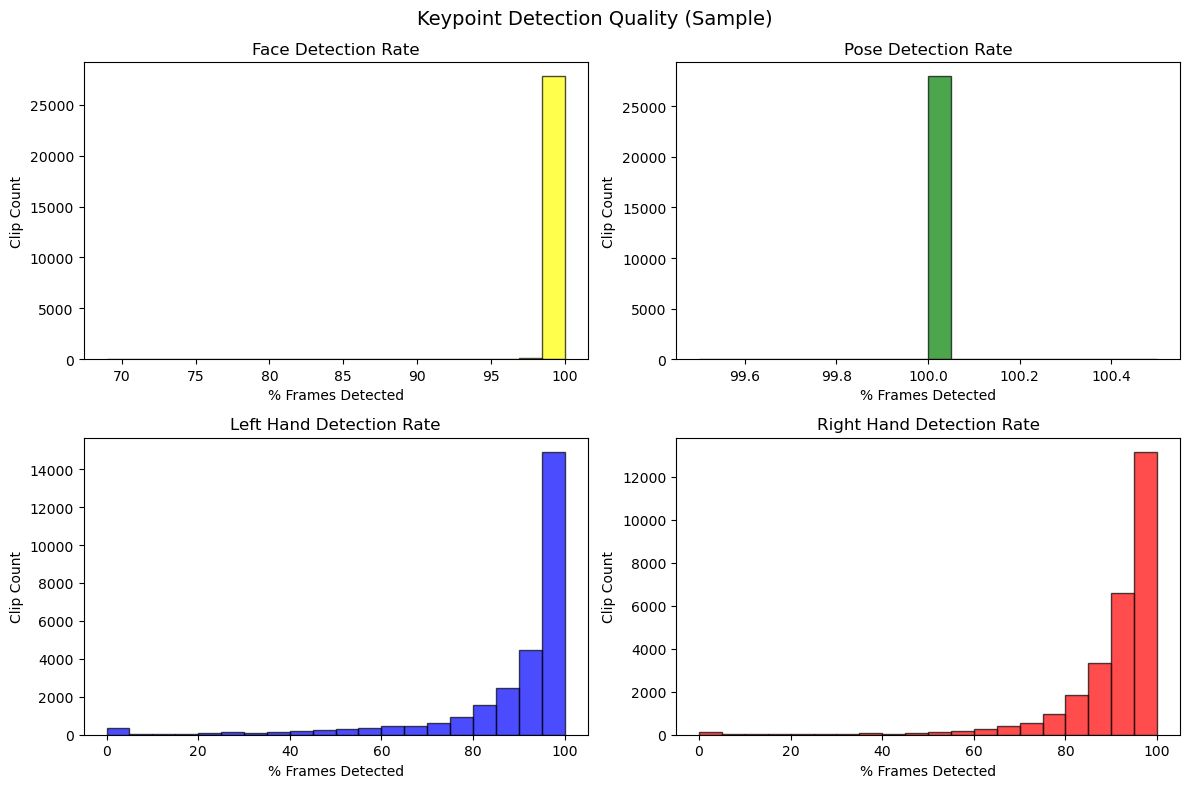


--- Potentially Problematic Clips ---

Found 204 clips with detection issues (in sample):


,file,issues,face_pct,pose_pct,lhand_pct,rhand_pct
0,-0N0jbyBW6g_0-5-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
1,-0yRaqY7nTE_0-5-rgb_front,no_hands,100.0,100.0,0.000000,16.666667
2,-1rM0t5FMiE_5-5-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
3,-70D86eMmIc_0-5-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
4,-8tIt1vEinQ_14-8-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
5,-aZEs9_Vo6g_0-3-rgb_front,no_hands,100.0,100.0,0.763359,12.977099
6,-bLfarX5JXU_3-5-rgb_front,no_hands,100.0,100.0,7.291667,8.333333
7,-c5CKp2JWHE_12-5-rgb_front,no_hands,100.0,100.0,22.641509,5.660377
8,-djRbCXJLYo_10-5-rgb_front,no_hands,100.0,100.0,12.389381,17.699115
9,-djRbCXJLYo_9-5-rgb_front,no_hands,100.0,100.0,6.422018,8.256881



Quality analysis complete!


In [ ]:
## Step 6: Keypoint Quality Analysis

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config ----
KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'train'
CSV_PATH = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
FAILED_CSV = Path('..') / 'data' / 'keypoint_extraction_failed.csv'
SAMPLE_SIZE = 1000  # number of files to deeply analyze

# ---- 1. Check failed extractions ----
print('=' * 60)
print('STEP 6: KEYPOINT QUALITY ANALYSIS')
print('=' * 60)

if FAILED_CSV.exists():
    failed_df = pd.read_csv(FAILED_CSV)
    print(f'\nFailed extractions: {len(failed_df)}')
    if len(failed_df) > 0:
        print('\nFailure breakdown:')
        print(failed_df['error'].value_counts())
        print('\nSample failed clips:')
        display(failed_df.head(10))
else:
    print('\nNo failed extractions file found - all clips likely succeeded!')

# ---- 2. Count extracted files ----
keypoint_files = list(KEYPOINT_DIR.glob('*.npz'))
df = pd.read_csv(CSV_PATH, sep='\t')

print(f'\n--- File Counts ---')
print(f'Total clips in CSV: {len(df)}')
print(f'Keypoint files extracted: {len(keypoint_files)}')
print(f'Missing: {len(df) - len(keypoint_files)}')

# ---- 3. Analyze keypoint statistics from sample ----
print(f'\n--- Analyzing {min(SAMPLE_SIZE, len(keypoint_files))} sample files ---')

sample_files = keypoint_files[:SAMPLE_SIZE]
stats = {
    'num_frames': [],
    'face_detected_pct': [],
    'pose_detected_pct': [],
    'left_hand_detected_pct': [],
    'right_hand_detected_pct': [],
    'file_size_mb': []
}

for kp_file in sample_files:
    data = np.load(kp_file)
    keypoints = data['keypoints']
    mask = data['mask']
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    
    T, N, _ = keypoints.shape
    stats['num_frames'].append(T)
    stats['file_size_mb'].append(kp_file.stat().st_size / (1024 * 1024))
    
    # Split mask by landmark type
    face_len = len(face_idx)
    pose_len = len(pose_idx)
    
    face_mask = mask[:, :face_len]
    pose_mask = mask[:, face_len:face_len + pose_len]
    lhand_mask = mask[:, face_len + pose_len:face_len + pose_len + 21]
    rhand_mask = mask[:, face_len + pose_len + 21:face_len + pose_len + 42]
    
    # Calculate detection percentage (% of frames where at least 1 landmark detected)
    stats['face_detected_pct'].append(100 * (face_mask.sum(axis=1) > 0).mean())
    stats['pose_detected_pct'].append(100 * (pose_mask.sum(axis=1) > 0).mean())
    stats['left_hand_detected_pct'].append(100 * (lhand_mask.sum(axis=1) > 0).mean())
    stats['right_hand_detected_pct'].append(100 * (rhand_mask.sum(axis=1) > 0).mean())

# Summary statistics
print('\nFrame count per clip:')
print(f'  Mean: {np.mean(stats["num_frames"]):.1f}')
print(f'  Median: {np.median(stats["num_frames"]):.1f}')
print(f'  Min: {np.min(stats["num_frames"])}')
print(f'  Max: {np.max(stats["num_frames"])}')

print('\nFile size per clip (MB):')
print(f'  Mean: {np.mean(stats["file_size_mb"]):.2f}')
print(f'  Median: {np.median(stats["file_size_mb"]):.2f}')
print(f'  Total (estimated for all clips): {np.mean(stats["file_size_mb"]) * len(keypoint_files) / 1024:.2f} GB')

print('\nDetection rates (% of frames with landmarks detected):')
print(f'  Face: {np.mean(stats["face_detected_pct"]):.1f}%')
print(f'  Pose: {np.mean(stats["pose_detected_pct"]):.1f}%')
print(f'  Left Hand: {np.mean(stats["left_hand_detected_pct"]):.1f}%')
print(f'  Right Hand: {np.mean(stats["right_hand_detected_pct"]):.1f}%')

# ---- 4. Visualize detection rates ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Keypoint Detection Quality (Sample)', fontsize=14)

axes[0, 0].hist(stats['face_detected_pct'], bins=20, edgecolor='black', color='yellow', alpha=0.7)
axes[0, 0].set_title('Face Detection Rate')
axes[0, 0].set_xlabel('% Frames Detected')
axes[0, 0].set_ylabel('Clip Count')

axes[0, 1].hist(stats['pose_detected_pct'], bins=20, edgecolor='black', color='green', alpha=0.7)
axes[0, 1].set_title('Pose Detection Rate')
axes[0, 1].set_xlabel('% Frames Detected')
axes[0, 1].set_ylabel('Clip Count')

axes[1, 0].hist(stats['left_hand_detected_pct'], bins=20, edgecolor='black', color='blue', alpha=0.7)
axes[1, 0].set_title('Left Hand Detection Rate')
axes[1, 0].set_xlabel('% Frames Detected')
axes[1, 0].set_ylabel('Clip Count')

axes[1, 1].hist(stats['right_hand_detected_pct'], bins=20, edgecolor='black', color='red', alpha=0.7)
axes[1, 1].set_title('Right Hand Detection Rate')
axes[1, 1].set_xlabel('% Frames Detected')
axes[1, 1].set_ylabel('Clip Count')

plt.tight_layout()
plt.show()

# ---- 5. Check for problematic clips ----
print('\n--- Potentially Problematic Clips ---')
problematic = []
for i, kp_file in enumerate(sample_files):
    issues = []
    if stats['face_detected_pct'][i] < 50:
        issues.append('low_face')
    if stats['pose_detected_pct'][i] < 50:
        issues.append('low_pose')
    if stats['left_hand_detected_pct'][i] < 30 and stats['right_hand_detected_pct'][i] < 30:
        issues.append('no_hands')
    
    if issues:
        problematic.append({
            'file': kp_file.stem,
            'issues': ','.join(issues),
            'face_pct': stats['face_detected_pct'][i],
            'pose_pct': stats['pose_detected_pct'][i],
            'lhand_pct': stats['left_hand_detected_pct'][i],
            'rhand_pct': stats['right_hand_detected_pct'][i]
        })

if problematic:
    prob_df = pd.DataFrame(problematic)
    print(f'\nFound {len(prob_df)} clips with detection issues (in sample):')
    display(prob_df.head(10))
else:
    print('\nNo significant detection issues found in sample!')

print('\n' + '=' * 60)
print('Quality analysis complete!')
print('=' * 60)

In [23]:
## Step 7: Preprocessing & Normalization

from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ---- Config ----
KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'train'
OUT_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / 'train'
CSV_PATH = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

OVERWRITE = False
FORWARD_FILL_MAX_GAP = 3  # frames - forward fill gaps ≤ this, mask gaps > this

print('=' * 60)
print('STEP 7: PREPROCESSING & NORMALIZATION')
print('=' * 60)

# ---- Helper Functions ----

def forward_fill_short_gaps(keypoints, mask, max_gap=3):
    """
    Forward-fill NaN gaps ≤ max_gap frames.
    Longer gaps remain as 0 with mask=0.
    
    Args:
        keypoints: (T, N, 3) array
        mask: (T, N) array
        max_gap: max frames to forward-fill
    
    Returns:
        filled_keypoints, updated_mask
    """
    T, N, _ = keypoints.shape
    filled = keypoints.copy()
    new_mask = mask.copy()
    
    for n in range(N):  # For each landmark
        gap_start = None
        last_valid_idx = None
        
        for t in range(T):
            if mask[t, n] == 1:  # Valid landmark
                # Check if we just exited a gap
                if gap_start is not None:
                    gap_length = t - gap_start
                    if gap_length <= max_gap and last_valid_idx is not None:
                        # Forward-fill this short gap
                        for gap_t in range(gap_start, t):
                            filled[gap_t, n] = filled[last_valid_idx, n]
                            new_mask[gap_t, n] = 1  # Mark as valid (filled)
                    # Else: gap > max_gap, leave as 0 with mask=0
                    gap_start = None
                
                last_valid_idx = t
            else:  # Invalid landmark
                if gap_start is None:
                    gap_start = t
        
        # Handle gap at end of sequence
        if gap_start is not None and last_valid_idx is not None:
            gap_length = T - gap_start
            if gap_length <= max_gap:
                for gap_t in range(gap_start, T):
                    filled[gap_t, n] = filled[last_valid_idx, n]
                    new_mask[gap_t, n] = 1
    
    return filled, new_mask


def center_and_normalize(keypoints, mask, face_idx, pose_idx):
    """
    Center keypoints by body center and normalize by shoulder width.
    Forward-fills normalization parameters when shoulders are missing to ensure consistency.
    
    Args:
        keypoints: (T, N, 3) array
        mask: (T, N) array
        face_idx: list of face landmark indices (to determine split)
        pose_idx: list of pose landmark indices (to find shoulders)
    
    Returns:
        normalized_keypoints
    """
    T, N, _ = keypoints.shape
    normalized = keypoints.copy()
    
    # Pose landmarks are after face landmarks
    face_len = len(face_idx)
    pose_start = face_len
    
    # Shoulder indices in pose_idx are 11 (left) and 12 (right)
    # Find their positions in the keypoints array
    pose_idx_array = np.array(pose_idx)
    left_shoulder_local = np.where(pose_idx_array == 11)[0]
    right_shoulder_local = np.where(pose_idx_array == 12)[0]
    
    if len(left_shoulder_local) == 0 or len(right_shoulder_local) == 0:
        print('Warning: Shoulders not found in pose_idx, skipping normalization')
        return normalized
    
    left_shoulder_idx = pose_start + left_shoulder_local[0]
    right_shoulder_idx = pose_start + right_shoulder_local[0]
    
    # Forward-fill normalization parameters
    last_body_center = None
    last_shoulder_width = None
    
    for t in range(T):
        body_center = None
        shoulder_width = None
        
        # Try to get normalization params from current frame
        if mask[t, left_shoulder_idx] == 1 and mask[t, right_shoulder_idx] == 1:
            left_shoulder = keypoints[t, left_shoulder_idx, :2]  # x, y only
            right_shoulder = keypoints[t, right_shoulder_idx, :2]
            body_center = (left_shoulder + right_shoulder) / 2.0
            shoulder_width = np.linalg.norm(right_shoulder - left_shoulder)
            
            # Update last valid params if valid
            if shoulder_width > 1e-6:
                last_body_center = body_center
                last_shoulder_width = shoulder_width
            else:
                # Invalid shoulder width, don't use this frame
                body_center = None
                shoulder_width = None
        
        # If current frame has no shoulders, use last valid params
        if body_center is None and last_body_center is not None:
            body_center = last_body_center
            shoulder_width = last_shoulder_width
        
        # Apply normalization if we have valid params
        if body_center is not None and shoulder_width is not None:
            for n in range(N):
                if mask[t, n] == 1:
                    # Center x, y
                    normalized[t, n, 0] -= body_center[0]
                    normalized[t, n, 1] -= body_center[1]
                    # Normalize by shoulder width
                    normalized[t, n, :2] /= shoulder_width
                    # Keep z as-is (depth is relative anyway)
    
    return normalized


# ---- Main Preprocessing ----

df = pd.read_csv(CSV_PATH, sep='\t')
keypoint_files = list(KEYPOINT_DIR.glob('*.npz'))

# Filter to only process files in the final CSV
sentence_names_in_csv = set(df['SENTENCE_NAME'].astype(str))
keypoint_files = [f for f in keypoint_files if f.stem in sentence_names_in_csv]

print(f'\nPreprocessing {len(keypoint_files)} keypoint files...')
print(f'Forward-fill gaps: ≤ {FORWARD_FILL_MAX_GAP} frames')
print(f'Mask gaps: > {FORWARD_FILL_MAX_GAP} frames')

processed_count = 0
skipped_count = 0

for kp_file in tqdm(keypoint_files, desc='Preprocessing'):
    out_path = OUT_DIR / kp_file.name
    
    if out_path.exists() and not OVERWRITE:
        skipped_count += 1
        continue
    
    # Load raw keypoints
    data = np.load(kp_file)
    keypoints = data['keypoints'].copy()  # (T, N, 3)
    mask = data['mask'].copy()  # (T, N)
    
    # Extract metadata
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    fps = data['fps'] if 'fps' in data.files else np.array([20.0])
    image_size = data['image_size'] if 'image_size' in data.files else np.array([0, 0])
    
    # Step 1: Forward-fill short gaps, mask long gaps
    keypoints, mask = forward_fill_short_gaps(keypoints, mask, max_gap=FORWARD_FILL_MAX_GAP)
    
    # Step 2: Center and normalize by body size
    keypoints = center_and_normalize(keypoints, mask, face_idx.tolist(), pose_idx.tolist())
    
    # Step 3: Replace any remaining NaN with 0 (shouldn't be any, but safety check)
    keypoints = np.nan_to_num(keypoints, nan=0.0)
    
    # Save preprocessed keypoints
    np.savez_compressed(
        out_path,
        keypoints=keypoints,
        mask=mask,
        fps=fps,
        image_size=image_size,
        face_idx=face_idx,
        pose_idx=pose_idx,
    )
    
    processed_count += 1

print(f'\n--- Preprocessing Complete ---')
print(f'Processed: {processed_count}')
print(f'Skipped (already exists): {skipped_count}')
print(f'Output directory: {OUT_DIR.resolve()}')
print()
print('Preprocessing applied:')
print('  1. Forward-fill: Gaps ≤ 3 frames filled with previous valid value')
print('  2. Masking: Gaps > 3 frames kept as 0 with mask=0')
print('  3. Centering: Subtracted body center (midpoint of shoulders)')
print('  4. Normalization: Scaled by shoulder width')
print('  5. Normalization params forward-filled for frames with missing shoulders')
print()
print('=' * 60)

STEP 7: PREPROCESSING & NORMALIZATION

Preprocessing 25921 keypoint files...
Forward-fill gaps: ≤ 3 frames
Mask gaps: > 3 frames


Preprocessing: 100%|██████████| 25921/25921 [20:28<00:00, 21.09it/s]  


--- Preprocessing Complete ---
Processed: 25921
Skipped (already exists): 0
Output directory: C:\My Projects\sign-language-bridge\data\keypoints_preprocessed\train

Preprocessing applied:
  1. Forward-fill: Gaps ≤ 3 frames filled with previous valid value
  2. Masking: Gaps > 3 frames kept as 0 with mask=0
  3. Centering: Subtracted body center (midpoint of shoulders)
  4. Normalization: Scaled by shoulder width
  5. Normalization params forward-filled for frames with missing shoulders



SANITY CHECK: Preprocessed Keypoints

Analyzed 10 files
Total valid keypoints: 223,595

Coordinate statistics (after normalization):
  X: mean=-0.103583, std=0.2897, min=-1.2376, max=1.5271
  Y: mean=-0.321058, std=0.9402, min=-2.1903, max=3.7164
  Z: mean=-0.062454, std=0.1848, min=-1.2051, max=0.1863

✅ Expected: X and Y centered near 0 (body center removed)
✅ Expected: X and Y scaled by shoulder width (typically -2 to +2 range)
✅ Expected: Z values remain in original MediaPipe scale


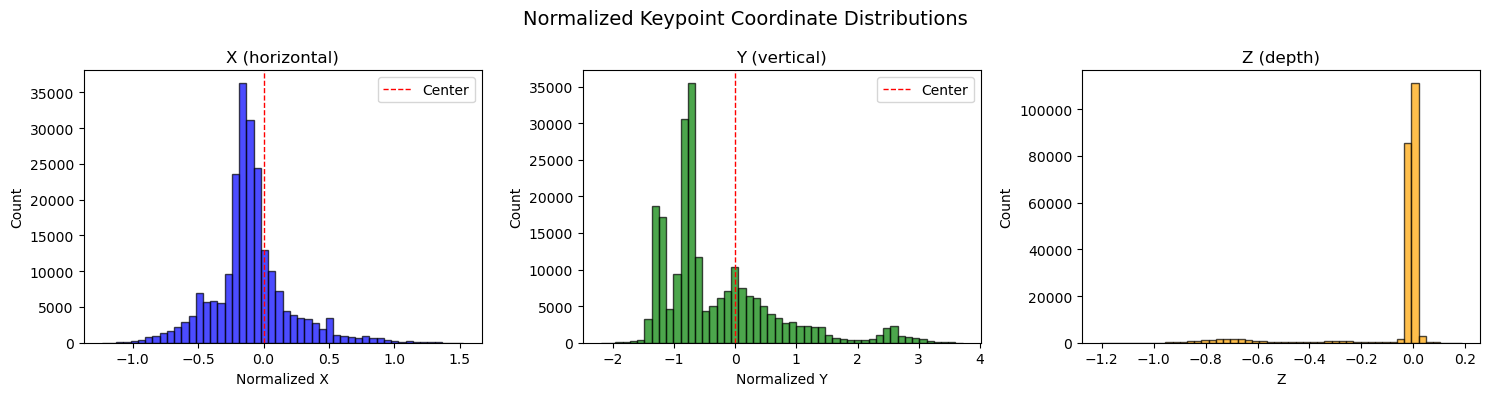

In [2]:
## Quick Sanity Check: Verify Preprocessed Keypoints

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PREPROCESSED_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / 'train'
SAMPLE_SIZE = 10

print('=' * 60)
print('SANITY CHECK: Preprocessed Keypoints')
print('=' * 60)

# Load sample files
preprocessed_files = list(PREPROCESSED_DIR.glob('*.npz'))[:SAMPLE_SIZE]

all_coords = []
for pf in preprocessed_files:
    data = np.load(pf)
    keypoints = data['keypoints']
    mask = data['mask']
    
    # Extract only valid (non-masked) coordinates
    valid_coords = keypoints[mask == 1]
    all_coords.append(valid_coords)

all_coords = np.concatenate(all_coords, axis=0)

print(f'\nAnalyzed {SAMPLE_SIZE} files')
print(f'Total valid keypoints: {len(all_coords):,}')
print()
print('Coordinate statistics (after normalization):')
print(f'  X: mean={all_coords[:, 0].mean():.6f}, std={all_coords[:, 0].std():.4f}, min={all_coords[:, 0].min():.4f}, max={all_coords[:, 0].max():.4f}')
print(f'  Y: mean={all_coords[:, 1].mean():.6f}, std={all_coords[:, 1].std():.4f}, min={all_coords[:, 1].min():.4f}, max={all_coords[:, 1].max():.4f}')
print(f'  Z: mean={all_coords[:, 2].mean():.6f}, std={all_coords[:, 2].std():.4f}, min={all_coords[:, 2].min():.4f}, max={all_coords[:, 2].max():.4f}')
print()
print('✅ Expected: X and Y centered near 0 (body center removed)')
print('✅ Expected: X and Y scaled by shoulder width (typically -2 to +2 range)')
print('✅ Expected: Z values remain in original MediaPipe scale')

# Visualize distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Normalized Keypoint Coordinate Distributions', fontsize=14)

axes[0].hist(all_coords[:, 0], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_title('X (horizontal)')
axes[0].set_xlabel('Normalized X')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='Center')
axes[0].legend()

axes[1].hist(all_coords[:, 1], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Y (vertical)')
axes[1].set_xlabel('Normalized Y')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='Center')
axes[1].legend()

axes[2].hist(all_coords[:, 2], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title('Z (depth)')
axes[2].set_xlabel('Z')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('=' * 60)

In [4]:
## Process Val Split: Extract & Preprocess Keypoints

from pathlib import Path
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Config ----
SPLIT = 'val'
CLIPS_DIR = Path(r'D:\How2Sign\val\val_rgb_front_clips')
CSV_PATH = Path('..') / 'data' / 'how2sign_val.csv'
RAW_OUT_DIR = Path('..') / 'data' / 'keypoints' / SPLIT
PREPROCESSED_OUT_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / SPLIT
RAW_OUT_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Extraction config (EXACT same as train)
NUM_WORKERS = 4
TARGET_FPS = 20
OVERWRITE = False
FORWARD_FILL_MAX_GAP = 3

# Landmark config (EXACT same as train)
mp_fm = mp.solutions.face_mesh
FACE_USE_LIPS = True
FACE_EYE_MODE = 'none'
FACE_USE_EYEBROWS = True
FACE_USE_NOSE = False
NOSE_MODE = 'none'
NOSE_MAX_POINTS = 4

def _idx(connection_set):
    return sorted({i for pair in connection_set for i in pair})

def _select_evenly(idx_list, k):
    if k is None or k >= len(idx_list): return idx_list
    if k <= 0: return []
    import numpy as _np
    sel = _np.linspace(0, len(idx_list) - 1, k)
    return [idx_list[int(round(i))] for i in sel]

REFINE_FACE_LANDMARKS = (FACE_EYE_MODE == 'iris')

face_parts = []
if FACE_USE_LIPS:
    face_parts += _idx(mp_fm.FACEMESH_LIPS)
if FACE_EYE_MODE == 'full':
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)
elif FACE_EYE_MODE == 'iris':
    face_parts += _idx(mp_fm.FACEMESH_IRISES)
if FACE_USE_EYEBROWS:
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW)
nose_idx = []
if FACE_USE_NOSE and NOSE_MODE != 'none':
    nose_idx = _idx(mp_fm.FACEMESH_NOSE)
    if NOSE_MODE == 'reduced':
        nose_idx = _select_evenly(nose_idx, NOSE_MAX_POINTS)
    face_parts += nose_idx

FACE_IDX = sorted(set(face_parts))
POSE_IDX = list(range(11, 25))

print('=' * 60)
print(f'PROCESSING {SPLIT.upper()} SPLIT')
print('=' * 60)
print(f'Face landmarks: {len(FACE_IDX)}')
print(f'Pose landmarks: {len(POSE_IDX)}')
print(f'Hand landmarks: 42 (21 each)')
print(f'Total per frame: {len(FACE_IDX) + len(POSE_IDX) + 42}')
print(f'Workers: {NUM_WORKERS}')

# ---- Helper Functions (same as train) ----

def extract_clip_keypoints(row, clips_dir, out_dir, target_fps, overwrite, face_idx, pose_idx, refine_face):
    sentence_name = row.SENTENCE_NAME
    out_path = out_dir / f'{sentence_name}.npz'
    
    if out_path.exists() and not overwrite:
        return (sentence_name, True, None)
    
    clip_path = clips_dir / f'{sentence_name}.mp4'
    if not clip_path.exists():
        return (sentence_name, False, 'clip_missing')
    
    try:
        cap = cv2.VideoCapture(str(clip_path))
        if not cap.isOpened():
            cap.release()
            return (sentence_name, False, 'cv2_open_failed')
        
        src_fps = cap.get(cv2.CAP_PROP_FPS)
        frame_interval = 1
        if target_fps and src_fps and src_fps > 0:
            frame_interval = max(int(round(src_fps / target_fps)), 1)
        
        frames_kp = []
        frames_mask = []
        frame_idx = 0
        H = W = None
        
        mp_holistic = mp.solutions.holistic
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=0,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
            refine_face_landmarks=refine_face,
        ) as holistic:
            
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                if frame_interval > 1 and (frame_idx % frame_interval) != 0:
                    frame_idx += 1
                    continue
                
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = holistic.process(rgb)
                
                H, W = frame.shape[:2]
                kp = []
                mask = []
                
                # Face
                if res.face_landmarks:
                    lms = res.face_landmarks.landmark
                    lms_len = len(lms)
                    for i in face_idx:
                        if i < lms_len:
                            lm = lms[i]
                            kp.extend([lm.x, lm.y, lm.z])
                            mask.append(1)
                        else:
                            kp.extend([float('nan')] * 3)
                            mask.append(0)
                else:
                    kp.extend([float('nan')] * (len(face_idx) * 3))
                    mask.extend([0] * len(face_idx))
                
                # Pose
                if res.pose_landmarks:
                    lms = res.pose_landmarks.landmark
                    for i in pose_idx:
                        lm = lms[i]
                        kp.extend([lm.x, lm.y, lm.z])
                        mask.append(1)
                else:
                    kp.extend([float('nan')] * (len(pose_idx) * 3))
                    mask.extend([0] * len(pose_idx))
                
                # Hands
                for hand_lms in [res.left_hand_landmarks, res.right_hand_landmarks]:
                    if hand_lms:
                        for lm in hand_lms.landmark:
                            kp.extend([lm.x, lm.y, lm.z])
                        mask.extend([1] * 21)
                    else:
                        kp.extend([float('nan')] * (21 * 3))
                        mask.extend([0] * 21)
                
                frames_kp.append(kp)
                frames_mask.append(mask)
                frame_idx += 1
        
        cap.release()
        
        if not frames_kp:
            return (sentence_name, False, 'no_frames')
        
        N = len(face_idx) + len(pose_idx) + 42
        arr = np.array(frames_kp, dtype=np.float32).reshape(len(frames_kp), N, 3)
        msk = np.array(frames_mask, dtype=np.uint8)
        np.savez(
            out_path,
            keypoints=arr,
            mask=msk,
            fps=np.array([float(src_fps)], dtype=np.float32) if (src_fps and src_fps > 0) else np.array([0.0], dtype=np.float32),
            image_size=np.array([H, W], dtype=np.int32) if (H and W) else np.array([0, 0], dtype=np.int32),
            face_idx=np.array(face_idx, dtype=np.int32),
            pose_idx=np.array(pose_idx, dtype=np.int32),
        )
        
        return (sentence_name, True, None)
    
    except Exception as e:
        return (sentence_name, False, str(e))


def forward_fill_short_gaps(keypoints, mask, max_gap=3):
    T, N, _ = keypoints.shape
    filled = keypoints.copy()
    new_mask = mask.copy()
    
    for n in range(N):
        gap_start = None
        last_valid_idx = None
        
        for t in range(T):
            if mask[t, n] == 1:
                if gap_start is not None:
                    gap_length = t - gap_start
                    if gap_length <= max_gap and last_valid_idx is not None:
                        for gap_t in range(gap_start, t):
                            filled[gap_t, n] = filled[last_valid_idx, n]
                            new_mask[gap_t, n] = 1
                    gap_start = None
                last_valid_idx = t
            else:
                if gap_start is None:
                    gap_start = t
        
        if gap_start is not None and last_valid_idx is not None:
            gap_length = T - gap_start
            if gap_length <= max_gap:
                for gap_t in range(gap_start, T):
                    filled[gap_t, n] = filled[last_valid_idx, n]
                    new_mask[gap_t, n] = 1
    
    return filled, new_mask


def center_and_normalize(keypoints, mask, face_idx, pose_idx):
    T, N, _ = keypoints.shape
    normalized = keypoints.copy()
    
    face_len = len(face_idx)
    pose_start = face_len
    
    pose_idx_array = np.array(pose_idx)
    left_shoulder_local = np.where(pose_idx_array == 11)[0]
    right_shoulder_local = np.where(pose_idx_array == 12)[0]
    
    if len(left_shoulder_local) == 0 or len(right_shoulder_local) == 0:
        return normalized
    
    left_shoulder_idx = pose_start + left_shoulder_local[0]
    right_shoulder_idx = pose_start + right_shoulder_local[0]
    
    last_body_center = None
    last_shoulder_width = None
    
    for t in range(T):
        body_center = None
        shoulder_width = None
        
        if mask[t, left_shoulder_idx] == 1 and mask[t, right_shoulder_idx] == 1:
            left_shoulder = keypoints[t, left_shoulder_idx, :2]
            right_shoulder = keypoints[t, right_shoulder_idx, :2]
            body_center = (left_shoulder + right_shoulder) / 2.0
            shoulder_width = np.linalg.norm(right_shoulder - left_shoulder)
            
            if shoulder_width > 1e-6:
                last_body_center = body_center
                last_shoulder_width = shoulder_width
            else:
                body_center = None
                shoulder_width = None
        
        if body_center is None and last_body_center is not None:
            body_center = last_body_center
            shoulder_width = last_shoulder_width
        
        if body_center is not None and shoulder_width is not None:
            for n in range(N):
                if mask[t, n] == 1:
                    normalized[t, n, 0] -= body_center[0]
                    normalized[t, n, 1] -= body_center[1]
                    normalized[t, n, :2] /= shoulder_width
    
    return normalized


# ---- Step 1: Extract Raw Keypoints ----
print('\nStep 1: Extracting raw keypoints...')

df = pd.read_csv(CSV_PATH, sep='\t')
print(f'Total clips in CSV: {len(df)}')

failed_list = []
success_count = 0

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {
        executor.submit(
            extract_clip_keypoints,
            row, CLIPS_DIR, RAW_OUT_DIR, TARGET_FPS, OVERWRITE,
            FACE_IDX, POSE_IDX, REFINE_FACE_LANDMARKS
        ): idx
        for idx, row in enumerate(df.itertuples(index=False))
    }
    
    with tqdm(total=len(futures), desc='Extracting') as pbar:
        for future in as_completed(futures):
            sentence_name, success, error = future.result()
            if success:
                success_count += 1
            else:
                failed_list.append({'SENTENCE_NAME': sentence_name, 'error': error})
            pbar.update(1)

print(f'Extraction: {success_count} success, {len(failed_list)} failed')

# ---- Step 2: Preprocess & Normalize ----
print('\nStep 2: Preprocessing & normalizing...')

keypoint_files = list(RAW_OUT_DIR.glob('*.npz'))
processed_count = 0
skipped_count = 0

for kp_file in tqdm(keypoint_files, desc='Preprocessing'):
    out_path = PREPROCESSED_OUT_DIR / kp_file.name
    
    if out_path.exists() and not OVERWRITE:
        skipped_count += 1
        continue
    
    data = np.load(kp_file)
    keypoints = data['keypoints'].copy()
    mask = data['mask'].copy()
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    fps = data['fps'] if 'fps' in data.files else np.array([20.0])
    image_size = data['image_size'] if 'image_size' in data.files else np.array([0, 0])
    
    keypoints, mask = forward_fill_short_gaps(keypoints, mask, max_gap=FORWARD_FILL_MAX_GAP)
    keypoints = center_and_normalize(keypoints, mask, face_idx.tolist(), pose_idx.tolist())
    keypoints = np.nan_to_num(keypoints, nan=0.0)
    
    np.savez_compressed(
        out_path,
        keypoints=keypoints,
        mask=mask,
        fps=fps,
        image_size=image_size,
        face_idx=face_idx,
        pose_idx=pose_idx,
    )
    
    processed_count += 1

print(f'Preprocessing: {processed_count} processed, {skipped_count} skipped')
print(f'\n✅ Val split complete!')
print(f'Raw keypoints: {RAW_OUT_DIR.resolve()}')
print(f'Preprocessed: {PREPROCESSED_OUT_DIR.resolve()}')
print('=' * 60)

PROCESSING VAL SPLIT
Face landmarks: 60
Pose landmarks: 14
Hand landmarks: 42 (21 each)
Total per frame: 116
Workers: 4

Step 1: Extracting raw keypoints...
Total clips in CSV: 1741


Extracting: 100%|██████████| 1741/1741 [00:00<00:00, 17868.37it/s]


Extraction: 1739 success, 2 failed

Step 2: Preprocessing & normalizing...


Preprocessing: 100%|██████████| 1739/1739 [00:00<00:00, 22570.96it/s]

Preprocessing: 0 processed, 1739 skipped

✅ Val split complete!
Raw keypoints: C:\My Projects\sign-language-bridge\data\keypoints\val
Preprocessed: C:\My Projects\sign-language-bridge\data\keypoints_preprocessed\val


In [5]:
## Process Test Split: Extract & Preprocess Keypoints

from pathlib import Path
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Config ----
SPLIT = 'test'
CLIPS_DIR = Path(r'D:\How2Sign\test\test_rgb_front_clips')
CSV_PATH = Path('..') / 'data' / 'how2sign_test.csv'
RAW_OUT_DIR = Path('..') / 'data' / 'keypoints' / SPLIT
PREPROCESSED_OUT_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / SPLIT
RAW_OUT_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Extraction config (EXACT same as train)
NUM_WORKERS = 4
TARGET_FPS = 20
OVERWRITE = False
FORWARD_FILL_MAX_GAP = 3

# Landmark config (EXACT same as train)
mp_fm = mp.solutions.face_mesh
FACE_USE_LIPS = True
FACE_EYE_MODE = 'none'
FACE_USE_EYEBROWS = True
FACE_USE_NOSE = False
NOSE_MODE = 'none'
NOSE_MAX_POINTS = 4

def _idx(connection_set):
    return sorted({i for pair in connection_set for i in pair})

def _select_evenly(idx_list, k):
    if k is None or k >= len(idx_list): return idx_list
    if k <= 0: return []
    import numpy as _np
    sel = _np.linspace(0, len(idx_list) - 1, k)
    return [idx_list[int(round(i))] for i in sel]

REFINE_FACE_LANDMARKS = (FACE_EYE_MODE == 'iris')

face_parts = []
if FACE_USE_LIPS:
    face_parts += _idx(mp_fm.FACEMESH_LIPS)
if FACE_EYE_MODE == 'full':
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)
elif FACE_EYE_MODE == 'iris':
    face_parts += _idx(mp_fm.FACEMESH_IRISES)
if FACE_USE_EYEBROWS:
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW)
nose_idx = []
if FACE_USE_NOSE and NOSE_MODE != 'none':
    nose_idx = _idx(mp_fm.FACEMESH_NOSE)
    if NOSE_MODE == 'reduced':
        nose_idx = _select_evenly(nose_idx, NOSE_MAX_POINTS)
    face_parts += nose_idx

FACE_IDX = sorted(set(face_parts))
POSE_IDX = list(range(11, 25))

print('=' * 60)
print(f'PROCESSING {SPLIT.upper()} SPLIT')
print('=' * 60)
print(f'Face landmarks: {len(FACE_IDX)}')
print(f'Pose landmarks: {len(POSE_IDX)}')
print(f'Hand landmarks: 42 (21 each)')
print(f'Total per frame: {len(FACE_IDX) + len(POSE_IDX) + 42}')
print(f'Workers: {NUM_WORKERS}')

# ---- Helper Functions (same as train) ----

def extract_clip_keypoints(row, clips_dir, out_dir, target_fps, overwrite, face_idx, pose_idx, refine_face):
    sentence_name = row.SENTENCE_NAME
    out_path = out_dir / f'{sentence_name}.npz'
    
    if out_path.exists() and not overwrite:
        return (sentence_name, True, None)
    
    clip_path = clips_dir / f'{sentence_name}.mp4'
    if not clip_path.exists():
        return (sentence_name, False, 'clip_missing')
    
    try:
        cap = cv2.VideoCapture(str(clip_path))
        if not cap.isOpened():
            cap.release()
            return (sentence_name, False, 'cv2_open_failed')
        
        src_fps = cap.get(cv2.CAP_PROP_FPS)
        frame_interval = 1
        if target_fps and src_fps and src_fps > 0:
            frame_interval = max(int(round(src_fps / target_fps)), 1)
        
        frames_kp = []
        frames_mask = []
        frame_idx = 0
        H = W = None
        
        mp_holistic = mp.solutions.holistic
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=0,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
            refine_face_landmarks=refine_face,
        ) as holistic:
            
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                if frame_interval > 1 and (frame_idx % frame_interval) != 0:
                    frame_idx += 1
                    continue
                
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = holistic.process(rgb)
                
                H, W = frame.shape[:2]
                kp = []
                mask = []
                
                # Face
                if res.face_landmarks:
                    lms = res.face_landmarks.landmark
                    lms_len = len(lms)
                    for i in face_idx:
                        if i < lms_len:
                            lm = lms[i]
                            kp.extend([lm.x, lm.y, lm.z])
                            mask.append(1)
                        else:
                            kp.extend([float('nan')] * 3)
                            mask.append(0)
                else:
                    kp.extend([float('nan')] * (len(face_idx) * 3))
                    mask.extend([0] * len(face_idx))
                
                # Pose
                if res.pose_landmarks:
                    lms = res.pose_landmarks.landmark
                    for i in pose_idx:
                        lm = lms[i]
                        kp.extend([lm.x, lm.y, lm.z])
                        mask.append(1)
                else:
                    kp.extend([float('nan')] * (len(pose_idx) * 3))
                    mask.extend([0] * len(pose_idx))
                
                # Hands
                for hand_lms in [res.left_hand_landmarks, res.right_hand_landmarks]:
                    if hand_lms:
                        for lm in hand_lms.landmark:
                            kp.extend([lm.x, lm.y, lm.z])
                        mask.extend([1] * 21)
                    else:
                        kp.extend([float('nan')] * (21 * 3))
                        mask.extend([0] * 21)
                
                frames_kp.append(kp)
                frames_mask.append(mask)
                frame_idx += 1
        
        cap.release()
        
        if not frames_kp:
            return (sentence_name, False, 'no_frames')
        
        N = len(face_idx) + len(pose_idx) + 42
        arr = np.array(frames_kp, dtype=np.float32).reshape(len(frames_kp), N, 3)
        msk = np.array(frames_mask, dtype=np.uint8)
        np.savez(
            out_path,
            keypoints=arr,
            mask=msk,
            fps=np.array([float(src_fps)], dtype=np.float32) if (src_fps and src_fps > 0) else np.array([0.0], dtype=np.float32),
            image_size=np.array([H, W], dtype=np.int32) if (H and W) else np.array([0, 0], dtype=np.int32),
            face_idx=np.array(face_idx, dtype=np.int32),
            pose_idx=np.array(pose_idx, dtype=np.int32),
        )
        
        return (sentence_name, True, None)
    
    except Exception as e:
        return (sentence_name, False, str(e))


def forward_fill_short_gaps(keypoints, mask, max_gap=3):
    T, N, _ = keypoints.shape
    filled = keypoints.copy()
    new_mask = mask.copy()
    
    for n in range(N):
        gap_start = None
        last_valid_idx = None
        
        for t in range(T):
            if mask[t, n] == 1:
                if gap_start is not None:
                    gap_length = t - gap_start
                    if gap_length <= max_gap and last_valid_idx is not None:
                        for gap_t in range(gap_start, t):
                            filled[gap_t, n] = filled[last_valid_idx, n]
                            new_mask[gap_t, n] = 1
                    gap_start = None
                last_valid_idx = t
            else:
                if gap_start is None:
                    gap_start = t
        
        if gap_start is not None and last_valid_idx is not None:
            gap_length = T - gap_start
            if gap_length <= max_gap:
                for gap_t in range(gap_start, T):
                    filled[gap_t, n] = filled[last_valid_idx, n]
                    new_mask[gap_t, n] = 1
    
    return filled, new_mask


def center_and_normalize(keypoints, mask, face_idx, pose_idx):
    T, N, _ = keypoints.shape
    normalized = keypoints.copy()
    
    face_len = len(face_idx)
    pose_start = face_len
    
    pose_idx_array = np.array(pose_idx)
    left_shoulder_local = np.where(pose_idx_array == 11)[0]
    right_shoulder_local = np.where(pose_idx_array == 12)[0]
    
    if len(left_shoulder_local) == 0 or len(right_shoulder_local) == 0:
        return normalized
    
    left_shoulder_idx = pose_start + left_shoulder_local[0]
    right_shoulder_idx = pose_start + right_shoulder_local[0]
    
    last_body_center = None
    last_shoulder_width = None
    
    for t in range(T):
        body_center = None
        shoulder_width = None
        
        if mask[t, left_shoulder_idx] == 1 and mask[t, right_shoulder_idx] == 1:
            left_shoulder = keypoints[t, left_shoulder_idx, :2]
            right_shoulder = keypoints[t, right_shoulder_idx, :2]
            body_center = (left_shoulder + right_shoulder) / 2.0
            shoulder_width = np.linalg.norm(right_shoulder - left_shoulder)
            
            if shoulder_width > 1e-6:
                last_body_center = body_center
                last_shoulder_width = shoulder_width
            else:
                body_center = None
                shoulder_width = None
        
        if body_center is None and last_body_center is not None:
            body_center = last_body_center
            shoulder_width = last_shoulder_width
        
        if body_center is not None and shoulder_width is not None:
            for n in range(N):
                if mask[t, n] == 1:
                    normalized[t, n, 0] -= body_center[0]
                    normalized[t, n, 1] -= body_center[1]
                    normalized[t, n, :2] /= shoulder_width
    
    return normalized


# ---- Step 1: Extract Raw Keypoints ----
print('\nStep 1: Extracting raw keypoints...')

df = pd.read_csv(CSV_PATH, sep='\t')
print(f'Total clips in CSV: {len(df)}')

failed_list = []
success_count = 0

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {
        executor.submit(
            extract_clip_keypoints,
            row, CLIPS_DIR, RAW_OUT_DIR, TARGET_FPS, OVERWRITE,
            FACE_IDX, POSE_IDX, REFINE_FACE_LANDMARKS
        ): idx
        for idx, row in enumerate(df.itertuples(index=False))
    }
    
    with tqdm(total=len(futures), desc='Extracting') as pbar:
        for future in as_completed(futures):
            sentence_name, success, error = future.result()
            if success:
                success_count += 1
            else:
                failed_list.append({'SENTENCE_NAME': sentence_name, 'error': error})
            pbar.update(1)

print(f'Extraction: {success_count} success, {len(failed_list)} failed')

# ---- Step 2: Preprocess & Normalize ----
print('\nStep 2: Preprocessing & normalizing...')

keypoint_files = list(RAW_OUT_DIR.glob('*.npz'))
processed_count = 0
skipped_count = 0

for kp_file in tqdm(keypoint_files, desc='Preprocessing'):
    out_path = PREPROCESSED_OUT_DIR / kp_file.name
    
    if out_path.exists() and not OVERWRITE:
        skipped_count += 1
        continue
    
    data = np.load(kp_file)
    keypoints = data['keypoints'].copy()
    mask = data['mask'].copy()
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    fps = data['fps'] if 'fps' in data.files else np.array([20.0])
    image_size = data['image_size'] if 'image_size' in data.files else np.array([0, 0])
    
    keypoints, mask = forward_fill_short_gaps(keypoints, mask, max_gap=FORWARD_FILL_MAX_GAP)
    keypoints = center_and_normalize(keypoints, mask, face_idx.tolist(), pose_idx.tolist())
    keypoints = np.nan_to_num(keypoints, nan=0.0)
    
    np.savez_compressed(
        out_path,
        keypoints=keypoints,
        mask=mask,
        fps=fps,
        image_size=image_size,
        face_idx=face_idx,
        pose_idx=pose_idx,
    )
    
    processed_count += 1

print(f'Preprocessing: {processed_count} processed, {skipped_count} skipped')
print(f'\n✅ Test split complete!')
print(f'Raw keypoints: {RAW_OUT_DIR.resolve()}')
print(f'Preprocessed: {PREPROCESSED_OUT_DIR.resolve()}')
print('=' * 60)

PROCESSING TEST SPLIT
Face landmarks: 60
Pose landmarks: 14
Hand landmarks: 42 (21 each)
Total per frame: 116
Workers: 4

Step 1: Extracting raw keypoints...
Total clips in CSV: 2357


Extracting:   0%|          | 0/2357 [00:00<?, ?it/s]c:\ProgramData\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extracting: 100%|██████████| 2357/2357 [1:19:34<00:00,  2.03s/it]


Extraction: 2343 success, 14 failed

Step 2: Preprocessing & normalizing...


Preprocessing: 100%|██████████| 2343/2343 [01:55<00:00, 20.32it/s]

Preprocessing: 2343 processed, 0 skipped

✅ Test split complete!
Raw keypoints: C:\My Projects\sign-language-bridge\data\keypoints\test
Preprocessed: C:\My Projects\sign-language-bridge\data\keypoints_preprocessed\test


In [6]:
## Quick Verification: Val & Test Preprocessing

from pathlib import Path
import numpy as np
import pandas as pd

print('=' * 60)
print('VERIFICATION: Val & Test Preprocessing')
print('=' * 60)

# Check val
val_csv = pd.read_csv(Path('..') / 'data' / 'how2sign_val.csv', sep='\t')
val_preprocessed = list((Path('..') / 'data' / 'keypoints_preprocessed' / 'val').glob('*.npz'))

print(f'\nVAL SPLIT:')
print(f'  CSV rows: {len(val_csv)}')
print(f'  Preprocessed files: {len(val_preprocessed)}')
print(f'  Match: {"✅" if len(val_preprocessed) >= len(val_csv) * 0.95 else "❌"}')

# Check test
test_csv = pd.read_csv(Path('..') / 'data' / 'how2sign_test.csv', sep='\t')
test_preprocessed = list((Path('..') / 'data' / 'keypoints_preprocessed' / 'test').glob('*.npz'))

print(f'\nTEST SPLIT:')
print(f'  CSV rows: {len(test_csv)}')
print(f'  Preprocessed files: {len(test_preprocessed)}')
print(f'  Match: {"✅" if len(test_preprocessed) >= len(test_csv) * 0.95 else "❌"}')

# Verify landmark counts (sample 3 files from each)
print(f'\nLANDMARK VERIFICATION:')
for split, files in [('val', val_preprocessed[:3]), ('test', test_preprocessed[:3])]:
    if files:
        data = np.load(files[0])
        T, N, _ = data['keypoints'].shape
        print(f'  {split}: {N} landmarks per frame {"✅" if N == 116 else "❌ MISMATCH!"}')

# Quick sanity check on normalization (sample val)
if val_preprocessed:
    sample_coords = []
    for f in val_preprocessed[:5]:
        data = np.load(f)
        valid_coords = data['keypoints'][data['mask'] == 1]
        sample_coords.append(valid_coords)

    sample_coords = np.concatenate(sample_coords, axis=0)
    print(f'\nVAL NORMALIZATION CHECK:')
    print(f'  X mean: {sample_coords[:, 0].mean():.3f} (expect ≈0)')
    print(f'  Y mean: {sample_coords[:, 1].mean():.3f} (expect ≈0)')
    print(f'  X/Y in range [-2, +4]: {"✅" if sample_coords[:, :2].min() > -3 and sample_coords[:, :2].max() < 5 else "❌"}')

print('\n' + '=' * 60)
print('✅ Verification complete! Ready for Notebook 2.' if len(val_preprocessed) > 0 and len(test_preprocessed) > 0 else '⚠️ Check the resultsabove')
print('=' * 60)

VERIFICATION: Val & Test Preprocessing

VAL SPLIT:
  CSV rows: 1741
  Preprocessed files: 1739
  Match: ✅

TEST SPLIT:
  CSV rows: 2357
  Preprocessed files: 2343
  Match: ✅

LANDMARK VERIFICATION:
  val: 116 landmarks per frame ✅
  test: 116 landmarks per frame ✅

VAL NORMALIZATION CHECK:
  X mean: -0.114 (expect ≈0)
  Y mean: -0.064 (expect ≈0)
  X/Y in range [-2, +4]: ✅

✅ Verification complete! Ready for Notebook 2.


In [9]:
## Impact Analysis: Remove Sequences > 9.5 seconds

import pandas as pd
from pathlib import Path

# Load current filtered data
df = pd.read_csv(Path('..') / 'data' / '(final)_how2sign_train_filtered.csv', sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Current stats
current_examples = len(df)
current_hours = df['duration_sec'].sum() / 3600

# Filter to ≤ 9.0 seconds
NEW_MAX = 9.0
df_new = df[df['duration_sec'] <= NEW_MAX].copy()
df_removed = df[df['duration_sec'] > NEW_MAX].copy()

new_examples = len(df_new)
new_hours = df_new['duration_sec'].sum() / 3600
removed_examples = len(df_removed)
removed_hours = df_removed['duration_sec'].sum() / 3600

print('=' * 70)
print('IMPACT ANALYSIS: Remove Sequences > 9.0 seconds')
print('=' * 70)

print('\nCURRENT (1.3s - 13.6s):')
print(f'  Examples: {current_examples:,}')
print(f'  Total hours: {current_hours:.2f}h')
print(f'  Mean duration: {df["duration_sec"].mean():.2f}s')
print(f'  Median duration: {df["duration_sec"].median():.2f}s')

print('\nNEW (1.3s - 9.0s):')
print(f'  Examples: {new_examples:,} ({new_examples/current_examples*100:.1f}% retained)')
print(f'  Total hours: {new_hours:.2f}h ({new_hours/current_hours*100:.1f}% retained)')
print(f'  Mean duration: {df_new["duration_sec"].mean():.2f}s')
print(f'  Median duration: {df_new["duration_sec"].median():.2f}s')

print('\nREMOVED (>9.0s):')
print(f'  Examples: {removed_examples:,} ({removed_examples/current_examples*100:.1f}% of total)')
print(f'  Total hours: {removed_hours:.2f}h ({removed_hours/current_hours*100:.1f}% of total)')

print('\nDISTRIBUTION relative to inference (3-5s):')
print(f'  In range (3-5s): {((df_new["duration_sec"] >= 3) & (df_new["duration_sec"] <= 5)).sum() / len(df_new) * 100:.1f}%')
print(f'  Shorter (<3s): {(df_new["duration_sec"] < 3).sum() / len(df_new) * 100:.1f}%')
print(f'  Longer (5-9.0s): {(df_new["duration_sec"] > 5).sum() / len(df_new) * 100:.1f}%')

print('\n' + '=' * 70)
print('RECOMMENDATION:')
if removed_examples / current_examples < 0.15:
    print('✅ Low impact - cutting at 9.0s removes <15% of data, good trade-off!')
elif removed_examples / current_examples < 0.25:
    print('⚠️ Moderate impact - removes 15-25% of data, consider carefully')
else:
    print('❌ High impact - removes >25% of data, may hurt model performance')
print('=' * 70)

IMPACT ANALYSIS: Remove Sequences > 9.0 seconds

CURRENT (1.3s - 13.6s):
  Examples: 25,921
  Total hours: 41.08h
  Mean duration: 5.70s
  Median duration: 5.11s

NEW (1.3s - 9.0s):
  Examples: 21,567 (83.2% retained)
  Total hours: 27.85h (67.8% retained)
  Mean duration: 4.65s
  Median duration: 4.42s

REMOVED (>9.0s):
  Examples: 4,354 (16.8% of total)
  Total hours: 13.23h (32.2% of total)

DISTRIBUTION relative to inference (3-5s):
  In range (3-5s): 32.1%
  Shorter (<3s): 26.6%
  Longer (5-9.0s): 41.3%

RECOMMENDATION:
⚠️ Moderate impact - removes 15-25% of data, consider carefully


In [21]:
from pathlib import Path
import pandas as pd

CSV_IN = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'
CSV_OUT = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'

# Same thresholds as val/test
MIN_DURATION = 1.3
MAX_DURATION = 8.0

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Filter
original_count = len(df)
df_filtered = df[(df['duration_sec'] > MIN_DURATION) & (df['duration_sec'] <= MAX_DURATION)].copy()
removed_count = original_count - len(df_filtered)

# Save
df_filtered.to_csv(CSV_OUT, sep='\t', index=False)

print('=' * 60)
print('TRAIN DATASET FILTERING')
print('=' * 60)
print(f'Original clips: {original_count}')
print(f'Filtered clips: {len(df_filtered)} ({len(df_filtered)/original_count*100:.1f}%)')
print(f'Removed: {removed_count} ({removed_count/original_count*100:.1f}%)')
print(f'  - ≤{MIN_DURATION}s: {(df["duration_sec"] <= MIN_DURATION).sum()}')
print(f'  - >{MAX_DURATION}s: {(df["duration_sec"] > MAX_DURATION).sum()}')
print(f'\nSaved: {CSV_OUT.resolve()}')
print('=' * 60)

TRAIN DATASET FILTERING
Original clips: 21567
Filtered clips: 19935 (92.4%)
Removed: 1632 (7.6%)
  - ≤1.3s: 0
  - >8.0s: 1632

Saved: C:\My Projects\sign-language-bridge\data\1(final)_how2sign_train_filtered.csv


In [22]:
## Filter Val Dataset (same thresholds as train)

from pathlib import Path
import pandas as pd

CSV_IN = Path('..') / 'data' / 'how2sign_realigned_val.csv'
CSV_OUT = Path('..') / 'data' / '(final)_how2sign_val_filtered.csv'

# Same thresholds as train
MIN_DURATION = 1.3
MAX_DURATION = 8.0

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Filter
original_count = len(df)
df_filtered = df[(df['duration_sec'] > MIN_DURATION) & (df['duration_sec'] <= MAX_DURATION)].copy()
removed_count = original_count - len(df_filtered)

# Save
df_filtered.to_csv(CSV_OUT, sep='\t', index=False)

print('=' * 60)
print('VAL DATASET FILTERING')
print('=' * 60)
print(f'Original clips: {original_count}')
print(f'Filtered clips: {len(df_filtered)} ({len(df_filtered)/original_count*100:.1f}%)')
print(f'Removed: {removed_count} ({removed_count/original_count*100:.1f}%)')
print(f'  - ≤{MIN_DURATION}s: {(df["duration_sec"] <= MIN_DURATION).sum()}')
print(f'  - >{MAX_DURATION}s: {(df["duration_sec"] > MAX_DURATION).sum()}')
print(f'\nSaved: {CSV_OUT.resolve()}')
print('=' * 60)

VAL DATASET FILTERING
Original clips: 1741
Filtered clips: 1051 (60.4%)
Removed: 690 (39.6%)
  - ≤1.3s: 115
  - >8.0s: 575

Saved: C:\My Projects\sign-language-bridge\data\1(final)_how2sign_val_filtered.csv


In [23]:
## Filter Test Dataset (same thresholds as train)

from pathlib import Path
import pandas as pd

CSV_IN = Path('..') / 'data' / 'how2sign_realigned_test.csv'
CSV_OUT = Path('..') / 'data' / '1(final)_how2sign_test_filtered.csv'

# Same thresholds as train
MIN_DURATION = 1.3
MAX_DURATION = 8.0

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Filter
original_count = len(df)
df_filtered = df[(df['duration_sec'] > MIN_DURATION) & (df['duration_sec'] <= MAX_DURATION)].copy()
removed_count = original_count - len(df_filtered)

# Save
df_filtered.to_csv(CSV_OUT, sep='\t', index=False)

print('=' * 60)
print('TEST DATASET FILTERING')
print('=' * 60)
print(f'Original clips: {original_count}')
print(f'Filtered clips: {len(df_filtered)} ({len(df_filtered)/original_count*100:.1f}%)')
print(f'Removed: {removed_count} ({removed_count/original_count*100:.1f}%)')
print(f'  - ≤{MIN_DURATION}s: {(df["duration_sec"] <= MIN_DURATION).sum()}')
print(f'  - >{MAX_DURATION}s: {(df["duration_sec"] > MAX_DURATION).sum()}')
print(f'\nSaved: {CSV_OUT.resolve()}')
print('=' * 60)

TEST DATASET FILTERING
Original clips: 2357
Filtered clips: 1464 (62.1%)
Removed: 893 (37.9%)
  - ≤1.3s: 198
  - >8.0s: 695

Saved: C:\My Projects\sign-language-bridge\data\1(final)_how2sign_test_filtered.csv


Train data duration distribution:
count    19935.000000
mean         4.334456
std          1.824194
min          1.300000
25%          2.790000
50%          4.180000
75%          5.780000
max          8.000000
Name: duration_sec, dtype: float64

% in inference range (3-5s): 34.7%
% shorter than inference (<3s): 28.8%
% longer than inference (>5s): 36.5%


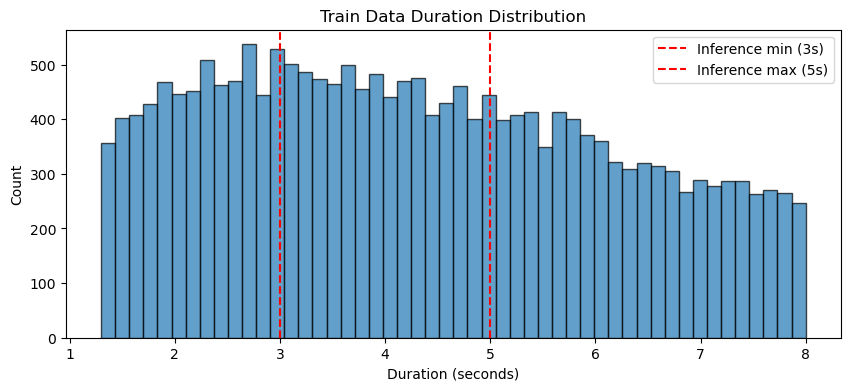

Val data duration distribution:
count    1051.000000
mean        4.370771
std         1.858983
min         1.310000
25%         2.730000
50%         4.270000
75%         5.925000
max         8.000000
Name: duration_sec, dtype: float64

% in inference range (3-5s): 31.9%
% shorter than inference (<3s): 30.4%
% longer than inference (>5s): 37.8%


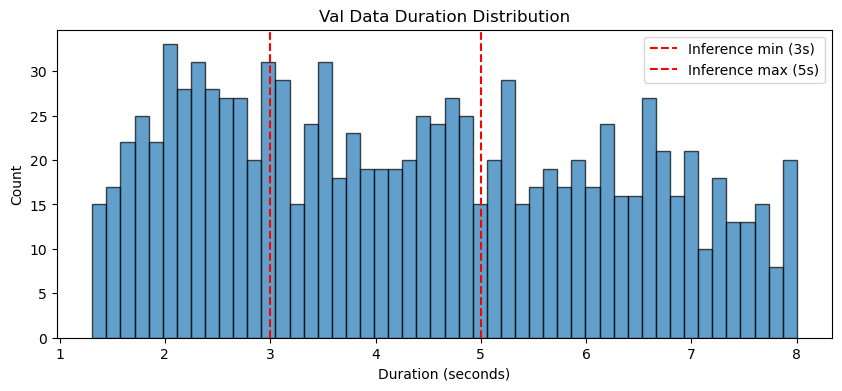

Test data duration distribution:
count    1464.000000
mean        4.295232
std         1.861895
min         1.310000
25%         2.700000
50%         4.155000
75%         5.800000
max         8.000000
Name: duration_sec, dtype: float64

% in inference range (3-5s): 32.9%
% shorter than inference (<3s): 30.5%
% longer than inference (>5s): 36.5%


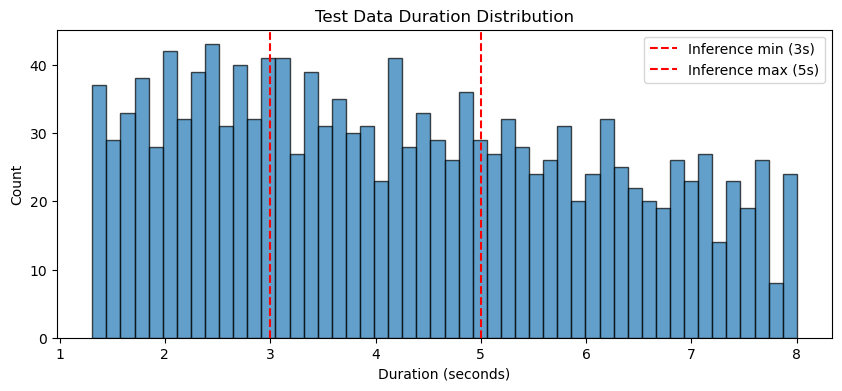

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
sets = ['train', 'val', 'test']

for split in sets:

    df = pd.read_csv(Path('..') / 'data' / f'(final)_how2sign_{split}_filtered.csv', sep='\t')
    df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

    print('=' * 60)
    print(f'{split.capitalize()} data duration distribution:')
    print(df['duration_sec'].describe(percentiles=[0.25, 0.5, 0.75]))
    print(f'\n% in inference range (3-5s): {((df["duration_sec"] >= 3) & (df["duration_sec"] <= 5)).sum() / len(df) * 100:.1f}%')
    print(f'% shorter than inference (<3s): {(df["duration_sec"] < 3).sum() / len(df) * 100:.1f}%')
    print(f'% longer than inference (>5s): {(df["duration_sec"] > 5).sum() / len(df) * 100:.1f}%')

    plt.figure(figsize=(10, 4))
    plt.hist(df['duration_sec'], bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(3, color='red', linestyle='--', label='Inference min (3s)')
    plt.axvline(5, color='red', linestyle='--', label='Inference max (5s)')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Count')
    plt.title(f'{split.capitalize()} Data Duration Distribution')
    plt.legend()
    plt.show()

Train data word count distribution:
count    19935.000000
mean        13.100828
std          6.358758
min          1.000000
25%          8.000000
50%         12.000000
75%         17.000000
max         54.000000
Name: word_count, dtype: float64

% short sentences (1-5 words):  8.7%
% medium sentences (6-10 words): 31.1%
% long sentences (>10 words):    60.1%

Most common word counts:
word_count
10    1342
9     1302
8     1257
11    1237
7     1225
12    1221
13    1167
14    1104
6     1077
15     961


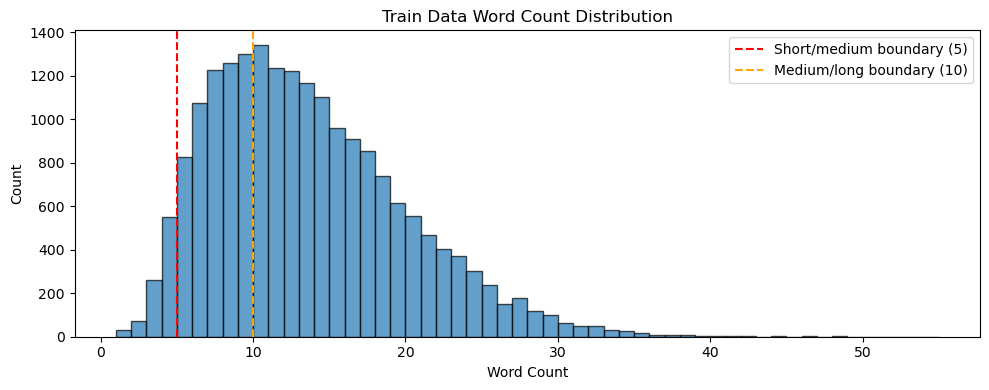

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sets = ['train']
for split in sets:
    df = pd.read_csv(Path('..') / 'data' / f'(final)_how2sign_{split}_filtered.csv', sep='\t')
    print('=' * 60)
    print(f'{split.capitalize()} data word count distribution:')
    print(df['word_count'].describe(percentiles=[0.25, 0.5, 0.75]))
    print(f'\n% short sentences (1-5 words):  {((df["word_count"] >= 1) & (df["word_count"] <= 5)).sum() / len(df) * 100:.1f}%')
    print(f'% medium sentences (6-10 words): {((df["word_count"] >= 6) & (df["word_count"] <= 10)).sum() / len(df) * 100:.1f}%')
    print(f'% long sentences (>10 words):    {(df["word_count"] > 10).sum() / len(df) * 100:.1f}%')
    print(f'\nMost common word counts:')
    print(df['word_count'].value_counts().head(10).to_string())

    plt.figure(figsize=(10, 4))
    plt.hist(df['word_count'], bins=range(1, df['word_count'].max() + 2), edgecolor='black', alpha=0.7)
    plt.axvline(5, color='red', linestyle='--', label='Short/medium boundary (5)')
    plt.axvline(10, color='orange', linestyle='--', label='Medium/long boundary (10)')
    plt.xlabel('Word Count')
    plt.ylabel('Count')
    plt.title(f'{split.capitalize()} Data Word Count Distribution')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [28]:
# Overlay Keypoints on val Sample Clips

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ---- Config ----
CLIPS_DIR    = Path(r"D:\How2Sign\val\val_rgb_front_clips")
CSV_PATH     = Path('..') / 'data' / 'how2sign_val_filtered.csv'
KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'val'
KEYPOINT_EXT = 'npz'
OUT_DIR      = Path('..') / 'data' / 'overlays'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZE  = 1
SAMPLE_NAMES = ["_5CV2fIG7qY_4-3-rgb_front"]
MAX_FRAMES   = None
TARGET_FPS   = None
OVERWRITE    = False

# Choose samples
if SAMPLE_NAMES is None:
    df = pd.read_csv(CSV_PATH, sep='\t')
    SAMPLE_NAMES = df['SENTENCE_NAME'].astype(str).head(int(SAMPLE_SIZE)).tolist()

print(f'Overlaying {len(SAMPLE_NAMES)} clips')
print(f'Keypoint dir: {KEYPOINT_DIR.resolve()}')
print(f'Output dir: {OUT_DIR.resolve()}')

POSE_CONNECTIONS = None
HAND_CONNECTIONS = None
try:
    import mediapipe as mp
    POSE_CONNECTIONS = mp.solutions.pose.POSE_CONNECTIONS
    HAND_CONNECTIONS = mp.solutions.hands.HAND_CONNECTIONS
except Exception:
    pass


def draw_points(frame, pts, mask, color, radius=2):
    for i, p in enumerate(pts):
        if mask is not None and mask[i] == 0:
            continue
        x, y = int(p[0] * frame.shape[1]), int(p[1] * frame.shape[0])
        if 0 <= x < frame.shape[1] and 0 <= y < frame.shape[0]:
            cv2.circle(frame, (x, y), radius, color, -1)


def draw_connections(frame, pts, mask, connections, color, thickness=2):
    for a, b in connections:
        if mask is not None and (mask[a] == 0 or mask[b] == 0):
            continue
        xa, ya = int(pts[a][0] * frame.shape[1]), int(pts[a][1] * frame.shape[0])
        xb, yb = int(pts[b][0] * frame.shape[1]), int(pts[b][1] * frame.shape[0])
        if 0 <= xa < frame.shape[1] and 0 <= ya < frame.shape[0] and 0 <= xb < frame.shape[1] and 0 <= yb < frame.shape[0]:
            cv2.line(frame, (xa, ya), (xb, yb), color, thickness)


for name in tqdm(SAMPLE_NAMES, desc='Overlay'):
    in_path  = CLIPS_DIR / f'{name}.mp4'
    out_path = OUT_DIR / f'{name}_overlay.mp4'
    kp_path  = KEYPOINT_DIR / f'{name}.{KEYPOINT_EXT}'

    if not in_path.exists():
        print(f'Skip missing clip: {name}')
        continue
    if not kp_path.exists():
        print(f'Skip missing keypoints: {name}')
        continue
    if out_path.exists() and not OVERWRITE:
        continue

    data = np.load(kp_path, allow_pickle=True)
    keypoints = data['keypoints']
    mask      = data['mask'] if 'mask' in data.files else None
    face_idx  = data['face_idx'] if 'face_idx' in data.files else None
    pose_idx  = data['pose_idx'] if 'pose_idx' in data.files else None

    T, N, _ = keypoints.shape
    
    # Dynamically determine split sizes from saved metadata
    face_len = int(len(face_idx)) if face_idx is not None else int(N - 14 - 42)
    pose_len = int(len(pose_idx)) if pose_idx is not None else 14
    hand_len = 21

    face_slice  = slice(0, face_len)
    pose_slice  = slice(face_len, face_len + pose_len)
    lhand_slice = slice(face_len + pose_len, face_len + pose_len + hand_len)
    rhand_slice = slice(face_len + pose_len + hand_len, face_len + pose_len + 2 * hand_len)

    cap = cv2.VideoCapture(str(in_path))
    if not cap.isOpened():
        print(f'Failed to open: {name}')
        cap.release()
        continue

    src_fps     = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None
    width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    frame_interval = 1
    out_fps = src_fps if src_fps and src_fps > 0 else 30
    if TARGET_FPS and src_fps and src_fps > 0:
        frame_interval = max(int(round(src_fps / TARGET_FPS)), 1)
        out_fps = float(src_fps) / frame_interval

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))
    if not writer.isOpened():
        out_path = OUT_DIR / f'{name}_overlay.avi'
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))

    if not writer.isOpened():
        print(f'Failed to open writer for: {name}')
        cap.release()
        continue

    frame_idx = 0
    written   = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_interval > 1 and (frame_idx % frame_interval) != 0:
            frame_idx += 1
            continue

        if frame_count and frame_count > 1:
            kp_idx = int(round(frame_idx * (T - 1) / max(frame_count - 1, 1)))
        else:
            kp_idx = min(frame_idx, T - 1)

        kp_frame   = keypoints[kp_idx]
        mask_frame = mask[kp_idx] if mask is not None else None

        # Face (yellow dots)
        draw_points(frame, kp_frame[face_slice], None if mask_frame is None else mask_frame[face_slice], (0, 255, 255), radius=1)

        # Pose (green dots + connections)
        pose_pts  = kp_frame[pose_slice]
        pose_mask = None if mask_frame is None else mask_frame[pose_slice]
        draw_points(frame, pose_pts, pose_mask, (0, 255, 0), radius=2)
        if POSE_CONNECTIONS is not None and pose_idx is not None:
            pose_map = {int(idx): i for i, idx in enumerate(pose_idx)}
            conns = [(pose_map[a], pose_map[b]) for a, b in POSE_CONNECTIONS if a in pose_map and b in pose_map]
            draw_connections(frame, pose_pts, pose_mask, conns, (0, 255, 0), thickness=1)

        # Left hand (blue) / Right hand (red)
        lpts  = kp_frame[lhand_slice]
        rpts  = kp_frame[rhand_slice]
        lmask = None if mask_frame is None else mask_frame[lhand_slice]
        rmask = None if mask_frame is None else mask_frame[rhand_slice]
        draw_points(frame, lpts, lmask, (255, 0, 0), radius=2)
        draw_points(frame, rpts, rmask, (0, 0, 255), radius=2)
        if HAND_CONNECTIONS is not None:
            draw_connections(frame, lpts, lmask, HAND_CONNECTIONS, (255, 0, 0), thickness=1)
            draw_connections(frame, rpts, rmask, HAND_CONNECTIONS, (0, 0, 255), thickness=1)

        writer.write(frame)
        written   += 1
        frame_idx += 1

        if MAX_FRAMES is not None and written >= int(MAX_FRAMES):
            break

    cap.release()
    writer.release()

    if written == 0:
        print(f'No frames written for: {name}')
    else:
        print(f'Wrote: {out_path.name} ({written} frames)')

print(f'Done. Overlays saved to: {OUT_DIR.resolve()}')

Overlaying 1 clips
Keypoint dir: C:\My Projects\sign-language-bridge\data\keypoints\val
Output dir: C:\My Projects\sign-language-bridge\data\overlays


Overlay: 100%|██████████| 1/1 [00:00<?, ?it/s]

Done. Overlays saved to: C:\My Projects\sign-language-bridge\data\overlays


# OpenASL

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path('..') / 'data' / 'openasl-v1.0.tsv', sep='\t')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst row:\n{df.iloc[0]}")

Shape: (98420, 8)

Columns: ['vid', 'yid', 'start', 'end', 'raw-text', 'tokenized-text', 'gloss', 'split']

First row:
vid               Mci9oyb5V2E-00:00:06.000-00:00:06.589
yid                                         Mci9oyb5V2E
start                                      00:00:06.000
end                                        00:00:06.589
raw-text                                         Hello!
tokenized-text                                    hello
gloss                                               NaN
split                                             train
Name: 0, dtype: object


C:\Users\mamou\AppData\Local\Temp\ipykernel_3316\1167176437.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(Path('..') / 'data' / 'openasl-v1.0.tsv', sep='\t')


Train — 96,477 samples

Duration (seconds):
count    96477.000000
mean         8.379285
std          6.376634
min          0.003000
25%          3.401000
50%          6.995000
75%         11.637000
max        107.000000
Name: duration_sec, dtype: float64
% <2s:   11.4%
% 2-5s:  25.6%
% >5s:   63.1%

Word count:
count    96477.000000
mean        14.360293
std          8.983741
min          0.000000
25%          8.000000
50%         13.000000
75%         19.000000
max        184.000000
Name: word_count, dtype: float64
% 1-5 words:  16.3%
% 6-10 words: 21.6%
% >10 words:  62.1%


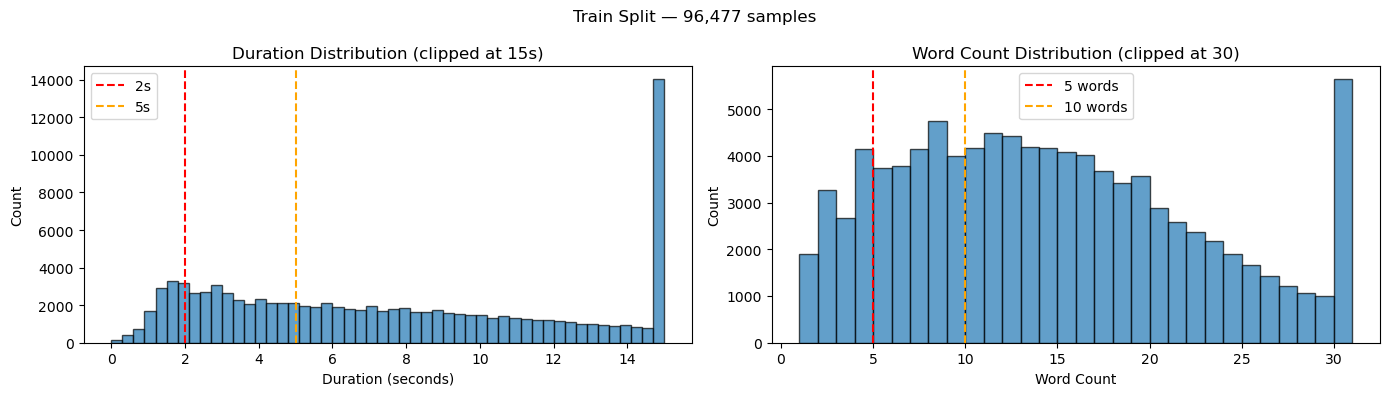

Valid — 967 samples

Duration (seconds):
count    967.000000
mean       6.935714
std        5.769997
min        0.200000
25%        2.633500
50%        5.366000
75%        9.683000
max       44.400000
Name: duration_sec, dtype: float64
% <2s:   16.9%
% 2-5s:  29.1%
% >5s:   54.1%

Word count:
count    967.000000
mean      13.383661
std        8.327575
min        1.000000
25%        7.000000
50%       12.000000
75%       19.000000
max       55.000000
Name: word_count, dtype: float64
% 1-5 words:  17.3%
% 6-10 words: 25.5%
% >10 words:  57.2%


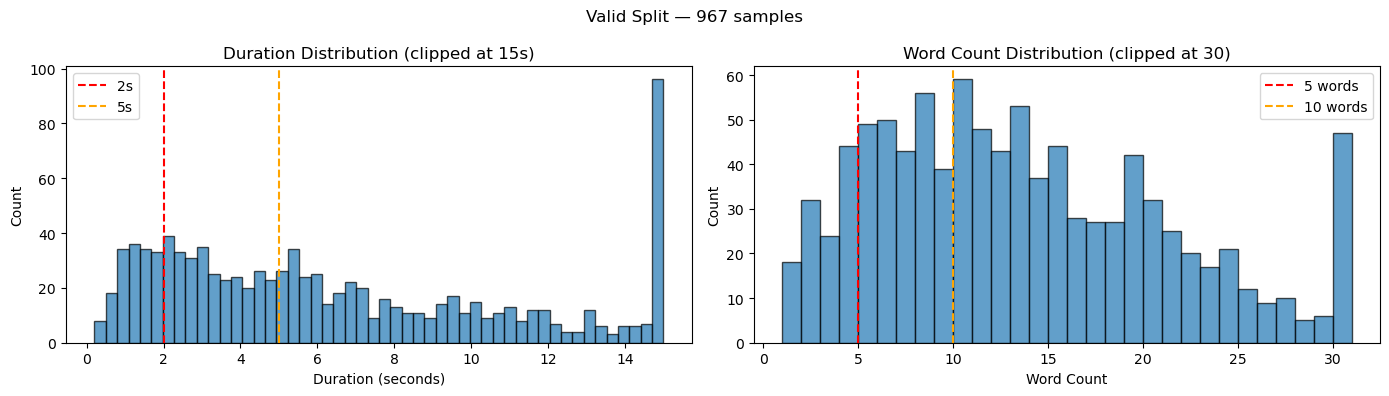

Test — 976 samples

Duration (seconds):
count    976.000000
mean       7.613036
std        6.306248
min        0.333000
25%        3.400000
50%        6.000000
75%       10.100000
max       73.933000
Name: duration_sec, dtype: float64
% <2s:   12.8%
% 2-5s:  28.3%
% >5s:   58.9%

Word count:
count    976.000000
mean      13.926230
std        8.855228
min        1.000000
25%        8.000000
50%       13.000000
75%       18.000000
max       94.000000
Name: word_count, dtype: float64
% 1-5 words:  14.9%
% 6-10 words: 24.2%
% >10 words:  61.0%


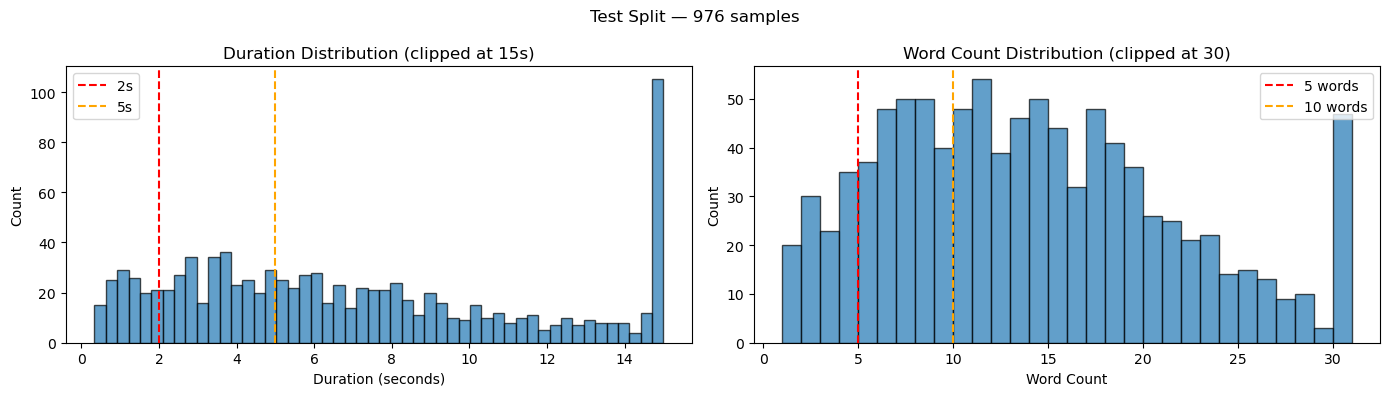

All — 98,420 samples

Duration (seconds):
count    98420.000000
mean         8.357503
std          6.372228
min          0.003000
25%          3.399000
50%          6.960000
75%         11.600000
max        107.000000
Name: duration_sec, dtype: float64
% <2s:   11.4%
% 2-5s:  25.6%
% >5s:   62.9%

Word count:
count    98420.000000
mean        14.346393
std          8.976792
min          0.000000
25%          8.000000
50%         13.000000
75%         19.000000
max        184.000000
Name: word_count, dtype: float64
% 1-5 words:  16.3%
% 6-10 words: 21.7%
% >10 words:  62.1%


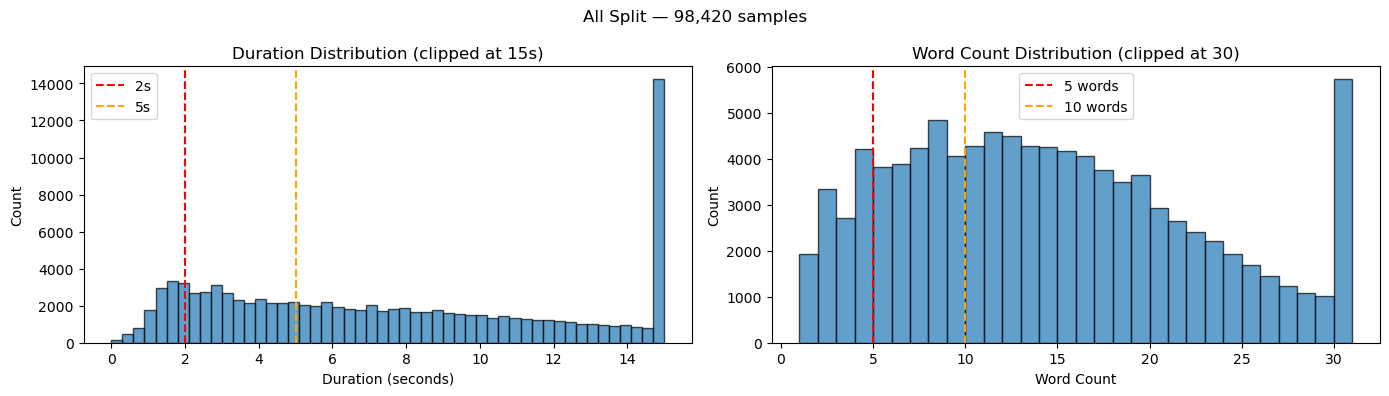

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path('..') / 'data' / 'openasl-v1.0.tsv', sep='\t', low_memory=False)

# ── Compute duration and word count ──
def time_to_sec(t):
    h, m, s = t.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

df['duration_sec'] = df['end'].apply(time_to_sec) - df['start'].apply(time_to_sec)
df['word_count'] = df['tokenized-text'].fillna('').apply(lambda x: len(x.split()))

for split in ['train', 'valid', 'test', 'all']:
    subset = df if split == 'all' else df[df['split'] == split]
    print('=' * 60)
    print(f'{split.capitalize()} — {len(subset):,} samples')

    print('\nDuration (seconds):')
    print(subset['duration_sec'].describe(percentiles=[0.25, 0.5, 0.75]))
    print(f"% <2s:   {(subset['duration_sec'] < 2).sum() / len(subset) * 100:.1f}%")
    print(f"% 2-5s:  {((subset['duration_sec'] >= 2) & (subset['duration_sec'] <= 5)).sum() / len(subset) * 100:.1f}%")
    print(f"% >5s:   {(subset['duration_sec'] > 5).sum() / len(subset) * 100:.1f}%")

    print('\nWord count:')
    print(subset['word_count'].describe(percentiles=[0.25, 0.5, 0.75]))
    print(f"% 1-5 words:  {((subset['word_count'] >= 1) & (subset['word_count'] <= 5)).sum() / len(subset) * 100:.1f}%")
    print(f"% 6-10 words: {((subset['word_count'] >= 6) & (subset['word_count'] <= 10)).sum() / len(subset) * 100:.1f}%")
    print(f"% >10 words:  {(subset['word_count'] > 10).sum() / len(subset) * 100:.1f}%")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{split.capitalize()} Split — {len(subset):,} samples')

    ax1.hist(subset['duration_sec'].clip(upper=15), bins=50, edgecolor='black', alpha=0.7)
    ax1.axvline(2, color='red', linestyle='--', label='2s')
    ax1.axvline(5, color='orange', linestyle='--', label='5s')
    ax1.set_xlabel('Duration (seconds)')
    ax1.set_ylabel('Count')
    ax1.set_title('Duration Distribution (clipped at 15s)')
    ax1.legend()

    ax2.hist(subset['word_count'].clip(upper=30), bins=range(1, 32), edgecolor='black', alpha=0.7)
    ax2.axvline(5, color='red', linestyle='--', label='5 words')
    ax2.axvline(10, color='orange', linestyle='--', label='10 words')
    ax2.set_xlabel('Word Count')
    ax2.set_ylabel('Count')
    ax2.set_title('Word Count Distribution (clipped at 30)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [6]:
MIN_DURATION = 1.3
MAX_DURATION = 8.0

filtered = df[(df['duration_sec'] >= MIN_DURATION) & (df['duration_sec'] <= MAX_DURATION)]

for split in ['train', 'valid', 'test']:
    original = (df['split'] == split).sum()
    kept = ((filtered['split'] == split)).sum()
    print(f"{split:5s}: {kept:,} / {original:,} ({kept/original*100:.1f}% kept)")

print(f"\nTotal: {len(filtered):,} / {len(df):,} ({len(filtered)/len(df)*100:.1f}% kept)")

train: 50,619 / 96,477 (52.5% kept)
valid: 566 / 967 (58.5% kept)
test : 548 / 976 (56.1% kept)

Total: 51,733 / 98,420 (52.6% kept)


In [7]:
import pandas as pd
from pathlib import Path

MIN_DURATION = 1.3
MAX_DURATION = 8.0

df = pd.read_csv(Path('..') / 'data' / 'openasl-v1.0.tsv', sep='\t', low_memory=False)

def time_to_sec(t):
    h, m, s = t.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

df['duration_sec'] = df['end'].apply(time_to_sec) - df['start'].apply(time_to_sec)
df['word_count'] = df['tokenized-text'].fillna('').apply(lambda x: len(x.split()))

# Filter by duration
df_filtered = df[
    (df['duration_sec'] >= MIN_DURATION) &
    (df['duration_sec'] <= MAX_DURATION)
].copy()

# Rename 'valid' → 'val' to match How2Sign convention
df_filtered['split'] = df_filtered['split'].replace('valid', 'val')

# Save per split
for split in ['train', 'val', 'test']:
    subset = df_filtered[df_filtered['split'] == split].copy()
    out_path = Path('..') / 'data' / f'openasl_{split}_filtered.tsv'
    subset.to_csv(out_path, sep='\t', index=False)
    print(f"{split}: {len(subset):,} samples → {out_path.name}")

print(f"\nTotal: {len(df_filtered):,} samples")
print(f"\nColumns: {list(df_filtered.columns)}")
print(f"\nSample row:\n{df_filtered.iloc[0]}")

train: 50,619 samples → openasl_train_filtered.tsv
val: 566 samples → openasl_val_filtered.tsv
test: 548 samples → openasl_test_filtered.tsv

Total: 51,733 samples

Columns: ['vid', 'yid', 'start', 'end', 'raw-text', 'tokenized-text', 'gloss', 'split', 'duration_sec', 'word_count']

Sample row:
vid               RjJSxzMkC90-00:00:25.123-00:00:27.524
yid                                         RjJSxzMkC90
start                                      00:00:25.123
end                                        00:00:27.524
raw-text                            Bush through relay.
tokenized-text                       bush through relay
gloss                                               NaN
split                                             train
duration_sec                                      2.401
word_count                                            3
Name: 3, dtype: object


In [1]:
import subprocess
import os
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ── Config ──
RAW_VIDEO_DIR = Path(r'D:\OpenASL\raw_videos')  # full YouTube videos go here
RAW_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

# Load all filtered splits and get unique YouTube IDs
dfs = []
for split in ['train', 'val', 'test']:
    dfs.append(pd.read_csv(Path('..') / 'data' / f'openasl_{split}_filtered.tsv', sep='\t'))
df_all = pd.concat(dfs, ignore_index=True)

yids = sorted(df_all['yid'].unique().tolist())
print(f"Unique YouTube videos to download: {len(yids)}")
print(f"Total clips across all splits:     {len(df_all)}")

# Check which are already downloaded
already = {p.stem for p in RAW_VIDEO_DIR.glob('*.mp4')}
yids_to_download = [y for y in yids if y not in already]
print(f"Already downloaded: {len(already)}")
print(f"Remaining:          {len(yids_to_download)}")

Unique YouTube videos to download: 2030
Total clips across all splits:     51733
Already downloaded: 0
Remaining:          2030


In [74]:
import subprocess
import pandas as pd
from pathlib import Path

RAW_VIDEO_DIR = Path(r'D:\OpenASL\raw_videos')
RAW_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

dfs = []
for split in ['train', 'val', 'test']:
    dfs.append(pd.read_csv(Path('..') / 'data' / f'openasl_{split}_filtered.tsv', sep='\t'))
df_all = pd.concat(dfs, ignore_index=True)

yids = sorted(df_all['yid'].unique().tolist())
already = {p.stem for p in RAW_VIDEO_DIR.glob('*.mp4')}
yids_to_download = [y for y in yids if y not in already]
# yids_to_download.remove('ZgvLTS2zJdo')
# yids_to_download.remove('bZsC1UP5uWw')
# yids_to_download.remove('x52KEY_sg0o')
# yids_to_download.remove('t-krQnPN_GY')
# yids_to_download.remove('1Q9Mo892UTU')

print(f"Total unique videos: {len(yids)}")
print(f"Already downloaded:  {len(already)}")
print(f"To download:         {len(yids_to_download)}")

url_list_path = RAW_VIDEO_DIR / 'urls_to_download.txt'
urls = [f'https://www.youtube.com/watch?v={yid}' for yid in yids_to_download]
url_list_path.write_text('\n'.join(urls))

N_CONCURRENT = 2  # keep low to avoid rate limiting

cmd = [
    'yt-dlp',
    '--batch-file', str(url_list_path),
    '-f', 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best',
    '--merge-output-format', 'mp4',
    '--no-check-certificate',
    '-o', str(RAW_VIDEO_DIR / '%(id)s.%(ext)s'),
    '-N', '4',
    '--ignore-errors',
    '--progress',
    '--retries', '5',
    # '--cookies-from-browser', 'edge',
    '--external-downloader', 'aria2c',
    '--external-downloader-args', 'aria2c:-x 8 -k 1M --min-split-size=1M',
]

print(f"\nStarting download with {N_CONCURRENT} concurrent workers...")
subprocess.run(cmd)

# Summary
downloaded = {p.stem for p in RAW_VIDEO_DIR.glob('*.mp4')}
missing = [y for y in yids if y not in downloaded]
print(f"\nDownloaded: {len(downloaded)}/{len(yids)}")
if missing:
    print(f"Missing: {len(missing)} — saved to missing.txt")
    (RAW_VIDEO_DIR / 'missing.txt').write_text('\n'.join(missing))

Total unique videos: 2030
Already downloaded:  1889
To download:         141

Starting download with 2 concurrent workers...

Downloaded: 1889/2030
Missing: 141 — saved to missing.txt


In [78]:
# ── OpenASL Video Validation (with missing video tracking) ──
from pathlib import Path
import cv2
import pandas as pd
from tqdm import tqdm

VIDEO_DIR  = Path("D:/OpenASL/raw_videos")
TSV_TRAIN  = Path("../data/openasl_train_filtered.tsv")
TSV_VAL    = Path("../data/openasl_val_filtered.tsv")
TSV_TEST   = Path("../data/openasl_test_filtered.tsv")

# ─────────────────────────────────────────
# Step 1: Load all expected YouTube IDs from TSV manifests
# ─────────────────────────────────────────

dfs = []
for path in [TSV_TRAIN, TSV_VAL, TSV_TEST]:
    dfs.append(pd.read_csv(path, sep="\t"))
df_all = pd.concat(dfs, ignore_index=True)

# All unique YouTube video files we need
expected_yids  = set(df_all["yid"].unique())
expected_total = len(expected_yids)

print(f"Total unique YouTube videos needed : {expected_total}")
print(f"Total clips across all splits      : {len(df_all):,}")

# ─────────────────────────────────────────
# Step 2: Inventory what's actually downloaded
# ─────────────────────────────────────────

downloaded_files = {p.stem: p for p in VIDEO_DIR.glob("*.mp4")}
# Also catch other formats just in case
for ext in ["*.avi", "*.mkv", "*.mov", "*.webm"]:
    for p in VIDEO_DIR.glob(ext):
        downloaded_files[p.stem] = p

downloaded_yids = set(downloaded_files.keys())

present = expected_yids & downloaded_yids
missing = expected_yids - downloaded_yids
extra   = downloaded_yids - expected_yids  # files on disk not in any manifest

print(f"\n📥 Download Progress")
print(f"  Expected  : {expected_total}")
print(f"  Downloaded: {len(downloaded_yids)}  ({100*len(downloaded_yids)/expected_total:.1f}%)")
print(f"  ✅ Present : {len(present)}")
print(f"  ❌ Missing : {len(missing)}")
print(f"  ❓ Extra   : {len(extra)}  (on disk but not in manifest)")

# ─────────────────────────────────────────
# Step 3: Per-split breakdown of missing videos
# ─────────────────────────────────────────

for split_name, path in [("train", TSV_TRAIN), ("val", TSV_VAL), ("test", TSV_TEST)]:
    df_split   = pd.read_csv(path, sep="\t")
    split_yids = set(df_split["yid"].unique())

    split_present = split_yids & downloaded_yids
    split_missing = split_yids - downloaded_yids

    clips_with_video    = df_split[df_split["yid"].isin(downloaded_yids)]
    clips_without_video = df_split[~df_split["yid"].isin(downloaded_yids)]

    print(f"\n── {split_name.upper()} ──")
    print(f"  Unique videos needed : {len(split_yids)}")
    print(f"  Videos present       : {len(split_present)} ({100*len(split_present)/len(split_yids):.1f}%)")
    print(f"  Videos missing       : {len(split_missing)}")
    print(f"  Clips processable    : {len(clips_with_video):,}  / {len(df_split):,}")
    print(f"  Clips blocked        : {len(clips_without_video):,}")

# ─────────────────────────────────────────
# Step 4: Check downloaded videos for corruption
# ─────────────────────────────────────────

results = []

for yid, video_path in tqdm(downloaded_files.items(), desc="Checking videos"):
    info = {
        "yid"         : yid,
        "filename"    : video_path.name,
        "size_kb"     : round(video_path.stat().st_size / 1024, 1),
        "in_manifest" : yid in expected_yids,
        "can_open"    : False,
        "frame_count" : 0,
        "fps"         : 0.0,
        "duration_sec": 0.0,
        "width"       : 0,
        "height"      : 0,
        "issue"       : None,
    }

    if info["size_kb"] == 0:
        info["issue"] = "zero_size"
        results.append(info)
        continue

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        info["issue"] = "cannot_open"
        results.append(info)
        continue

    info["can_open"]    = True
    info["frame_count"] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    info["fps"]         = cap.get(cv2.CAP_PROP_FPS)
    info["width"]       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    info["height"]      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    info["duration_sec"]= round(
        info["frame_count"] / info["fps"] if info["fps"] > 0 else 0, 2
    )

    ret_first, _ = cap.read()
    if not ret_first:
        info["issue"] = "cannot_read_first_frame"
        cap.release()
        results.append(info)
        continue

    if info["frame_count"] > 1:
        cap.set(cv2.CAP_PROP_POS_FRAMES, info["frame_count"] - 1)
        ret_last, _ = cap.read()
        if not ret_last:
            info["issue"] = "cannot_read_last_frame"

    cap.release()

    if info["frame_count"] == 0:
        info["issue"] = "zero_frames"
    elif info["fps"] <= 0:
        info["issue"] = "invalid_fps"
    elif info["duration_sec"] < 0.5:
        info["issue"] = "too_short"

    results.append(info)

df_checked = pd.DataFrame(results)

# ─────────────────────────────────────────
# Step 5: Full summary report
# ─────────────────────────────────────────

ok  = df_checked[df_checked["issue"].isna()]
bad = df_checked[df_checked["issue"].notna()]

print("=" * 55)
print("  OpenASL Validation Report")
print("=" * 55)
print(f"\n  Expected total   : {expected_total}")
print(f"  Downloaded       : {len(downloaded_files)}")
print(f"  Still missing    : {len(missing)}")
print(f"  ─────────────────────────────")
print(f"  ✅ OK (playable) : {len(ok)}")
print(f"  ❌ Corrupted     : {len(bad)}")

if len(bad) > 0:
    print(f"\n── Corruption breakdown ──")
    print(bad["issue"].value_counts().to_string())
    print(f"\n── Corrupted files ──")
    print(bad[["filename", "size_kb", "duration_sec", "issue"]].to_string(index=False))

print(f"\n── Stats for OK videos ──")
print(f"  FPS range      : {ok['fps'].min():.1f} – {ok['fps'].max():.1f}")
print(f"  Duration range : {ok['duration_sec'].min():.1f}s – {ok['duration_sec'].max():.1f}s")
print(f"  Avg duration   : {ok['duration_sec'].mean():.1f}s")
print(f"  Resolution     : {ok['width'].mode()[0]}×{ok['height'].mode()[0]} (most common)")
print(f"  Total size     : {df_checked['size_kb'].sum() / 1024 / 1024:.2f} GB")

# Estimate remaining download
clips_per_video = len(df_all) / len(expected_yids)
missing_clips_est = len(missing) * clips_per_video
print(f"\n── Download remaining ──")
print(f"  Videos still needed : {len(missing)}")
print(f"  Clips blocked (est) : {missing_clips_est:.0f}")

# ─────────────────────────────────────────
# Step 6: Save reports
# ─────────────────────────────────────────

# Full validation report
df_checked.to_csv(VIDEO_DIR / "validation_report.csv", index=False)

# Missing videos list (for re-downloading)
missing_df = pd.DataFrame({"yid": sorted(missing)})
missing_df["youtube_url"] = "https://www.youtube.com/watch?v=" + missing_df["yid"]
missing_clips_count = df_all[df_all["yid"].isin(missing)].groupby("yid").size().reset_index(name="clip_count")  # most clips first = highest priority
missing_df = missing_df.merge(missing_clips_count, on="yid", how="left")
missing_df = missing_df.sort_values("clip_count", ascending=False)
missing_df.to_csv(VIDEO_DIR / "missing_videos.csv", index=False)

# Corrupted videos list
if len(bad) > 0:
    bad.to_csv(VIDEO_DIR / "corrupted_videos.csv", index=False)

print(f"Reports saved to {VIDEO_DIR}/")
print(f"  validation_report.csv  — all {len(df_checked)} checked videos")
print(f"  missing_videos.csv     — {len(missing)} missing YouTube IDs (sorted by clip count)")
if len(bad) > 0:
    print(f"  corrupted_videos.csv   — {len(bad)} corrupted files")

Total unique YouTube videos needed : 2030
Total clips across all splits      : 51,733

📥 Download Progress
  Expected  : 2030
  Downloaded: 1889  (93.1%)
  ✅ Present : 1889
  ❌ Missing : 141
  ❓ Extra   : 0  (on disk but not in manifest)

── TRAIN ──
  Unique videos needed : 2030
  Videos present       : 1889 (93.1%)
  Videos missing       : 141
  Clips processable    : 48,217  / 50,619
  Clips blocked        : 2,402

── VAL ──
  Unique videos needed : 344
  Videos present       : 309 (89.8%)
  Videos missing       : 35
  Clips processable    : 518  / 566
  Clips blocked        : 48

── TEST ──
  Unique videos needed : 325
  Videos present       : 292 (89.8%)
  Videos missing       : 33
  Clips processable    : 503  / 548
  Clips blocked        : 45


Checking videos: 100%|██████████| 1889/1889 [02:57<00:00, 10.64it/s]


  OpenASL Validation Report

  Expected total   : 2030
  Downloaded       : 1889
  Still missing    : 141
  ─────────────────────────────
  ✅ OK (playable) : 1889
  ❌ Corrupted     : 0

── Stats for OK videos ──
  FPS range      : 23.0 – 60.0
  Duration range : 6.1s – 2100.8s
  Avg duration   : 488.0s
  Resolution     : 1920×1080 (most common)
  Total size     : 196.61 GB

── Download remaining ──
  Videos still needed : 141
  Clips blocked (est) : 3593
Reports saved to D:\OpenASL\raw_videos/
  validation_report.csv  — all 1889 checked videos
  missing_videos.csv     — 141 missing YouTube IDs (sorted by clip count)


In [79]:
from pathlib import Path
import pandas as pd

VIDEO_DIR = Path("D:/OpenASL/raw_videos")
DATA_DIR  = Path("../data")

# Build set of downloaded YouTube IDs
downloaded_yids = {p.stem for p in VIDEO_DIR.glob("*.mp4")}

for split in ["train", "val", "test"]:
    src  = DATA_DIR / f"openasl_{split}_filtered.tsv"
    dst  = DATA_DIR / f"openasl_{split}_missing_filtered.tsv"

    df      = pd.read_csv(src, sep="\t")
    df_keep = df[df["yid"].isin(downloaded_yids)].reset_index(drop=True)
    df_keep.to_csv(dst, sep="\t", index=False)

    removed = len(df) - len(df_keep)
    print(f"{split:5s}  {len(df):,} -> {len(df_keep):,}  (removed {removed} clips with missing video)")

train  50,619 -> 48,217  (removed 2402 clips with missing video)
val    566 -> 518  (removed 48 clips with missing video)
test   548 -> 503  (removed 45 clips with missing video)


Loaded 99375 bounding box entries

Sample keys:
  0QgDWB3M47g-00:03:28.139-00:03:33.900  →  [0.5941470670700073, 0.13053046090262277, 0.9116897753306799, 1.0952827520219108]
  kNy2E3P7m2s-00:00:29.216-00:00:34.216  →  [0.33975756821643555, -0.044116507455812276, 0.7159328261173674, 1.0458205484160294]
  O2uBRm6D_KI-00:01:21.540-00:01:26.379  →  [0.24633345873342397, -0.2143532196830371, 0.7488931917201327, 1.1405961285128356]
  sITlRZ-tnqw-00:00:23.899-00:00:28.019  →  [0.20629612731933594, -0.23044904539320205, 0.7286034851074219, 1.3116690981123182]
  X8POWculBf0-00:00:45.359-00:01:01.020  →  [0.48588640781871056, -0.12092551828127857, 0.8250251589323345, 0.869658254359433]
✅ Matched   : 82881 / 99375
❌ Unmatched : 16494 / 99375

Sample unmatched keys:
  sITlRZ-tnqw-00:00:23.899-00:00:28.019
  jfdwjt7RzFU-00:06:00.319-00:06:10.399
  mlWT-0WbcUs-00:06:53.947-00:06:55.281
  _GGnds1j594-00:00:10.323-00:00:14.586
  dAzt--IDaFY-00:00:58.000-00:01:00.640
📹 0QgDWB3M47g.mp4
   Frames: 21989 

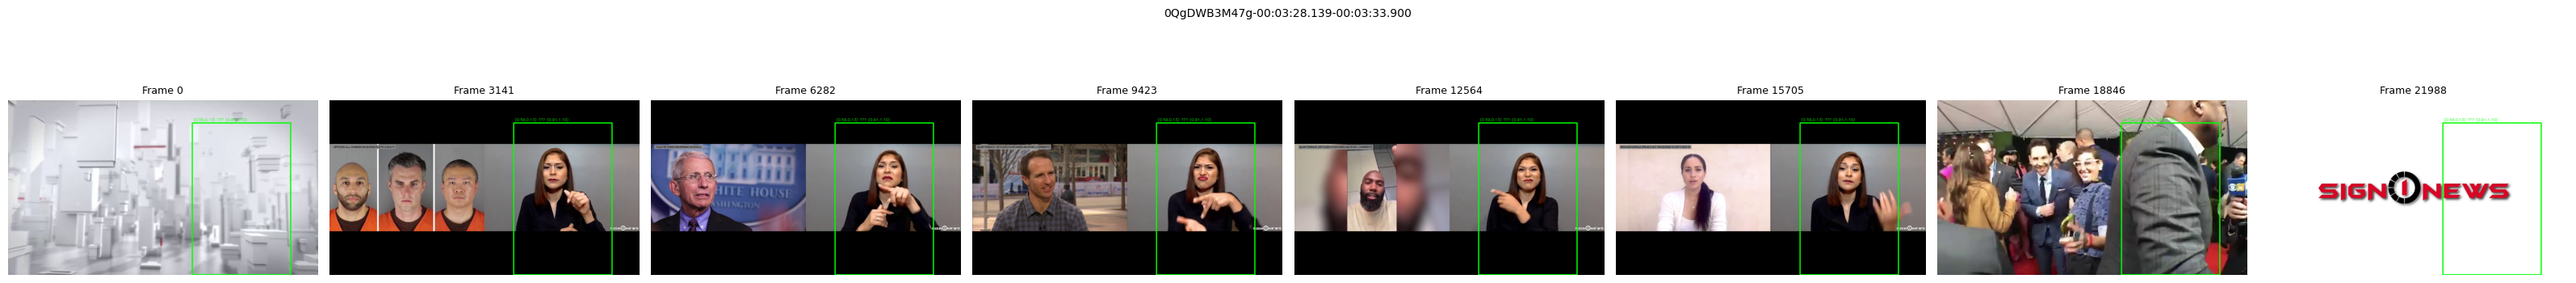

📹 _ljjwCgFf1Q.mp4
   Frames: 31502  |  FPS: 30.0  |  Resolution: 1920×1080
   BBox: [0.3476725498835246, -0.12366131111427589, 0.9285485315322876, 1.659019101460775]


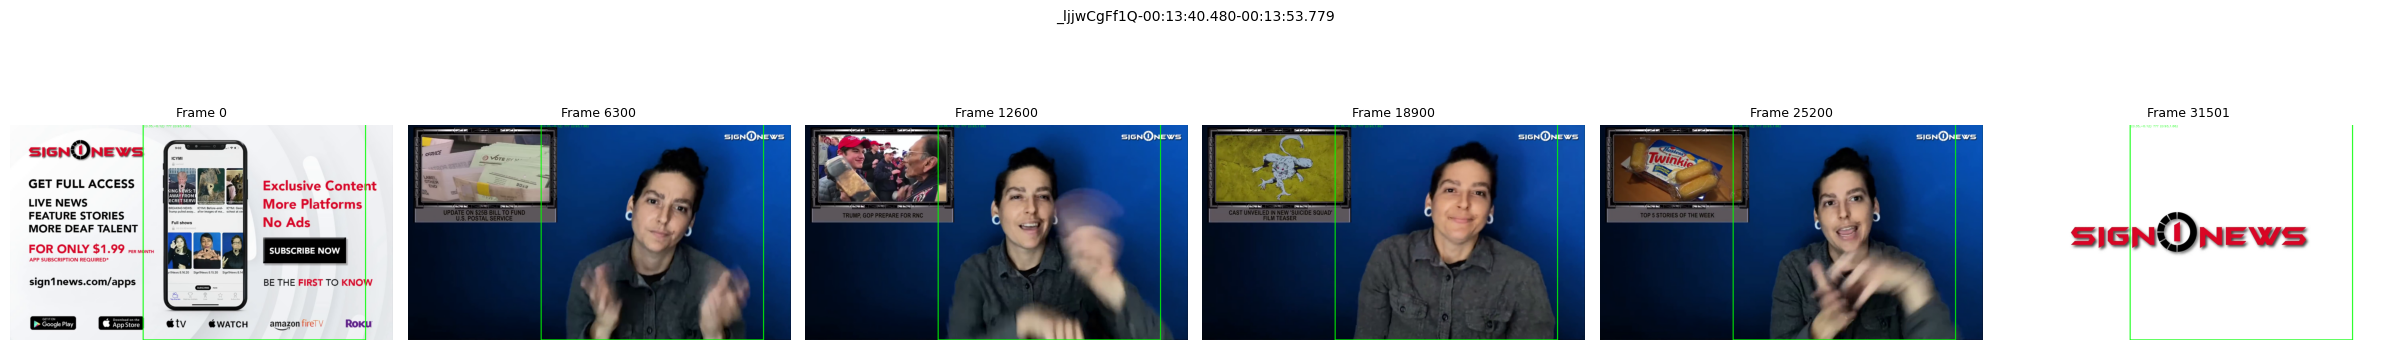

────────────────────────────────────────────────────────────
📹 Vysl4DMFBdg.mp4
   Frames: 17117  |  FPS: 30.0  |  Resolution: 1920×1080
   BBox: [0.4309501780403985, -0.16166958514555, 0.9229985475540161, 1.3000666606573412]


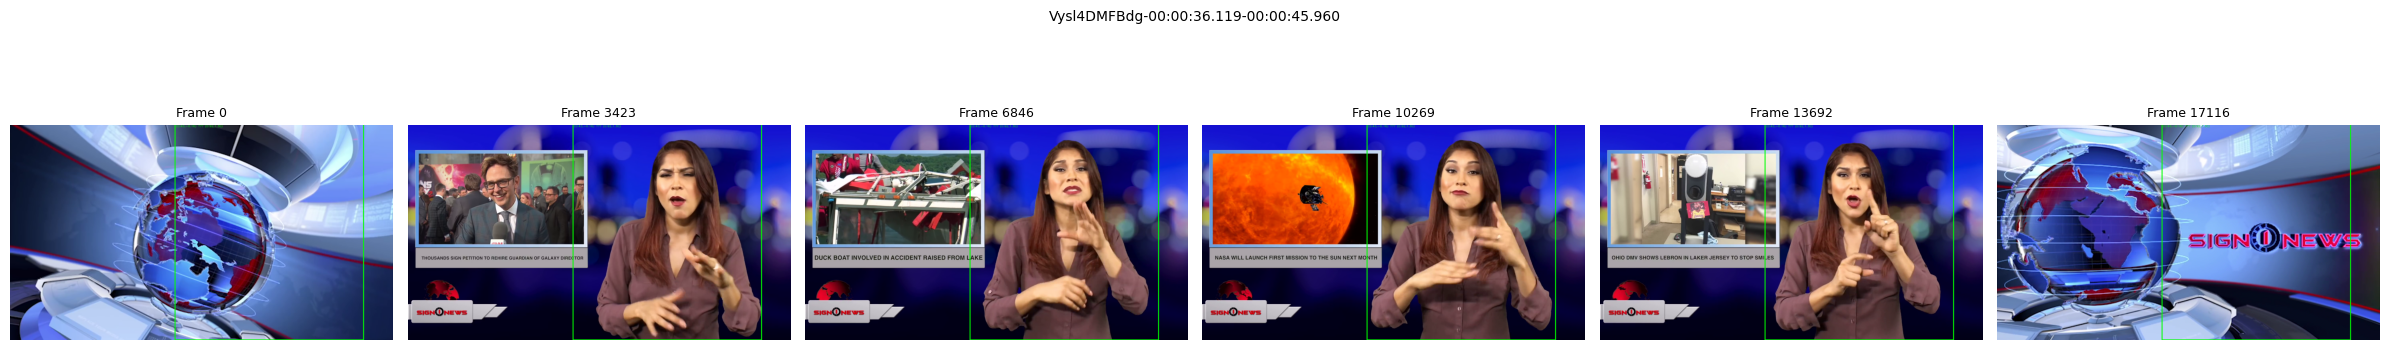

────────────────────────────────────────────────────────────
📹 ZUT99XZ46DA.mp4
   Frames: 19605  |  FPS: 24.0  |  Resolution: 1920×1080
   BBox: [0.4981330759385053, -0.1511233344317002, 0.9897069332646389, 1.3240478947791139]


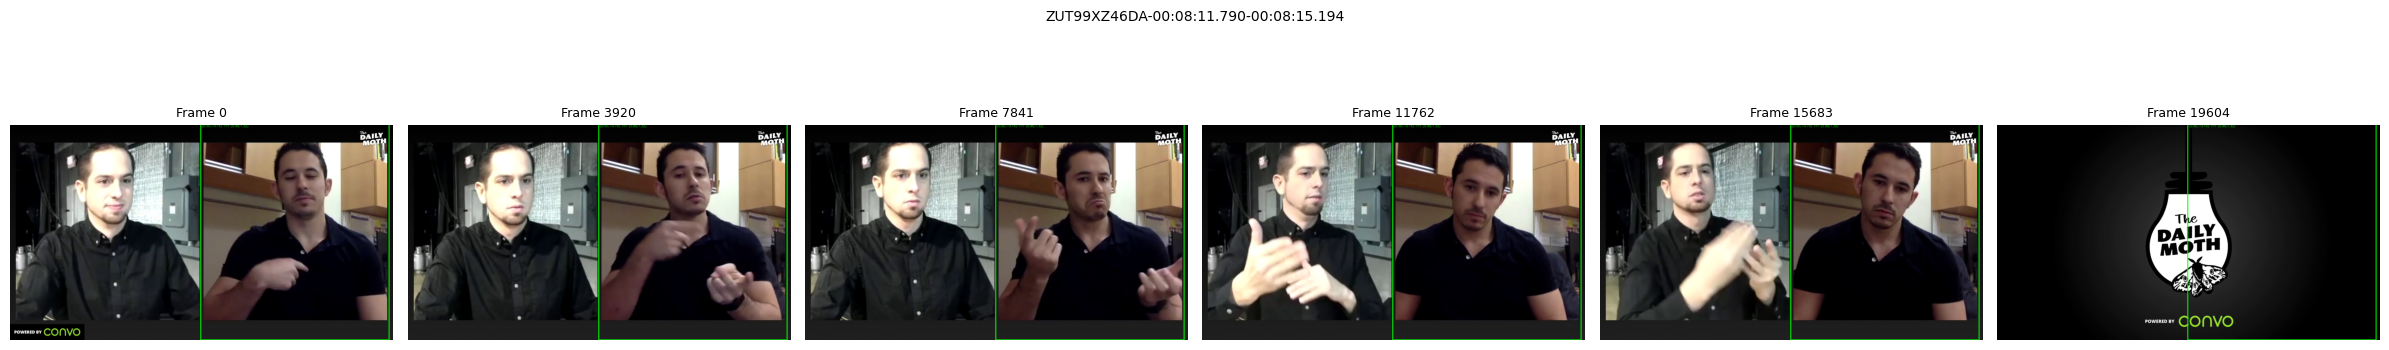

────────────────────────────────────────────────────────────
📹 VkLIJDtQYQw.mp4
   Frames: 2203  |  FPS: 30.0  |  Resolution: 854×470
   BBox: [0.3430965807733826, -0.13204624054279732, 0.7576176592002708, 1.0697211726168367]


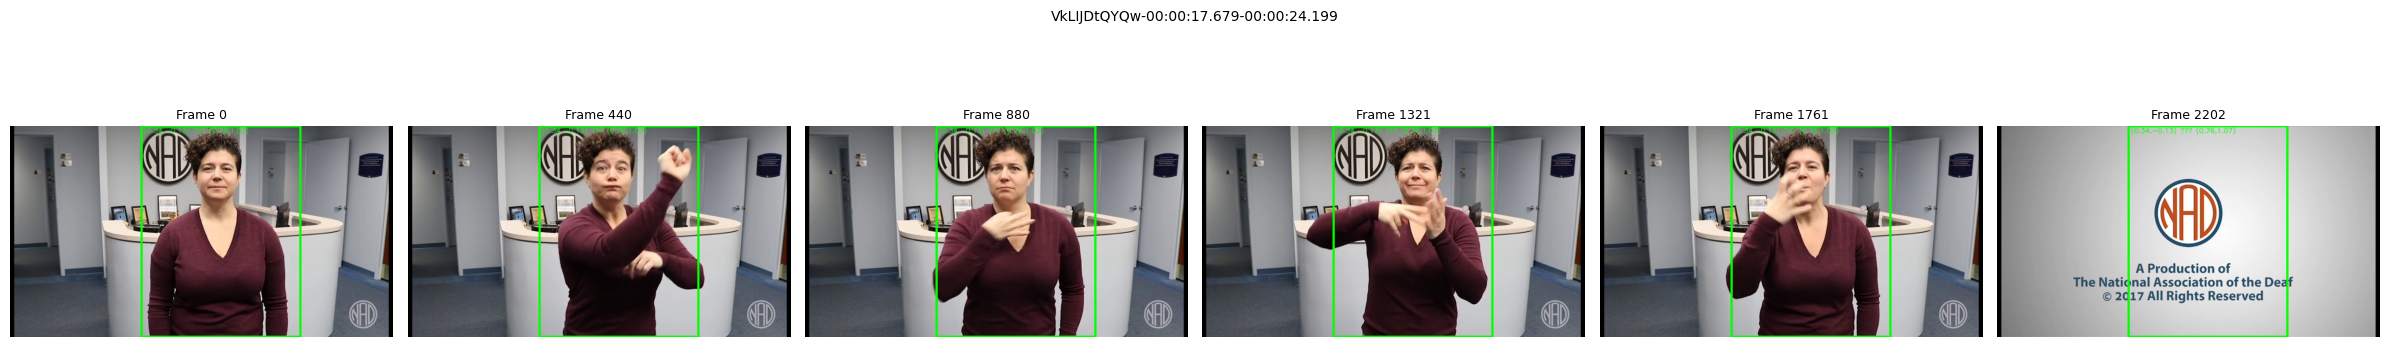

────────────────────────────────────────────────────────────
📹 ICBGc3FXFyQ.mp4
   Frames: 18247  |  FPS: 30.0  |  Resolution: 654×480
   BBox: [0.3032451441875795, -0.06195312227521624, 0.7832590613942212, 1.0517287275147817]


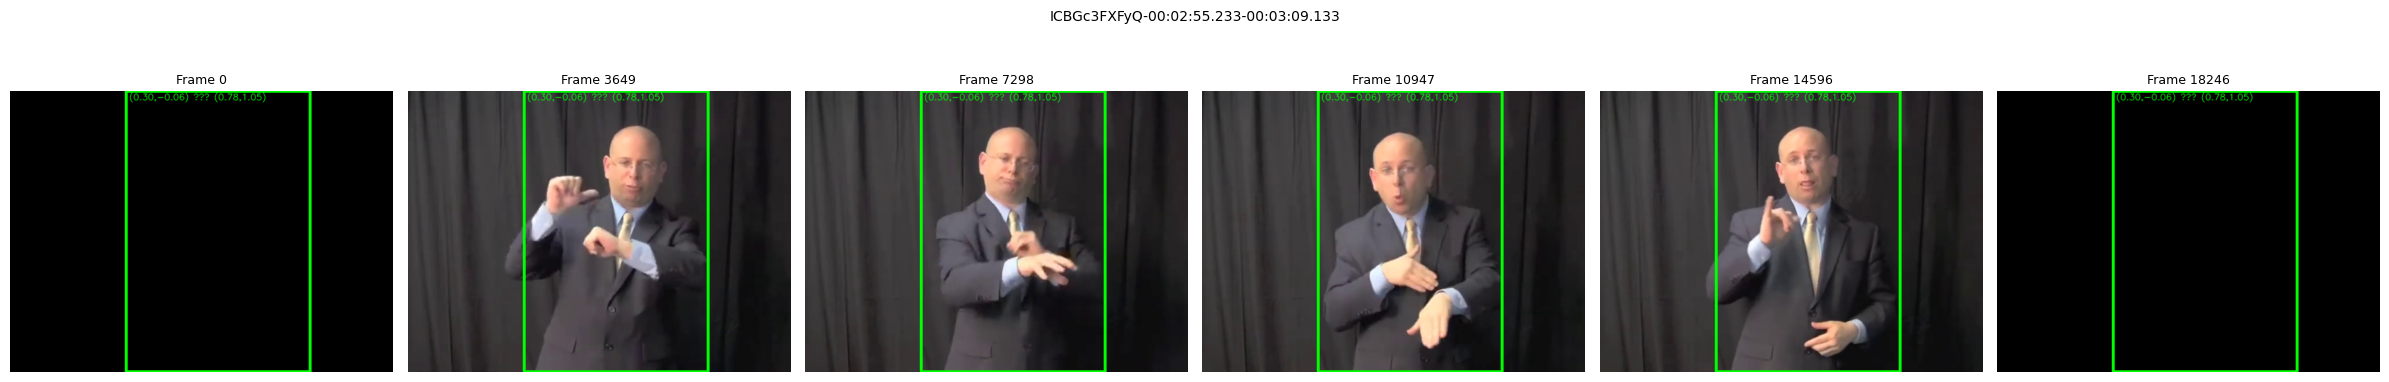

────────────────────────────────────────────────────────────
✅ Saved 21989 frames → D:\OpenASL\bbox_preview\0QgDWB3M47g-00-03-28.139-00-03-33.900_bbox.mp4
✅ Saved 4138 frames → D:\OpenASL\bbox_preview\kNy2E3P7m2s-00-00-29.216-00-00-34.216_bbox.mp4
✅ Saved 12286 frames → D:\OpenASL\bbox_preview\O2uBRm6D_KI-00-01-21.540-00-01-26.379_bbox.mp4


In [80]:
# ── OpenASL Bounding Box Visualization ──
import json
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
import ipywidgets as widgets

BBOX_FILE  = Path("../data/bbox-v1.0.json")
VIDEO_DIR  = Path("D:/OpenASL/raw_videos")
OUTPUT_DIR = Path("D:/OpenASL/bbox_preview")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(BBOX_FILE, "r") as f:
    bbox_data = json.load(f)

print(f"Loaded {len(bbox_data)} bounding box entries")
print(f"\nSample keys:")
for k in list(bbox_data.keys())[:5]:
    print(f"  {k}  →  {bbox_data[k]}")

# ─────────────────────────────────────────
# Step 1: Match JSON keys → video files
# ─────────────────────────────────────────

# List all videos and build a lookup dict: stem → Path
video_files = {p.stem: p for p in VIDEO_DIR.glob("*.mp4")}

matched   = {}  # json_key → video_path
unmatched = []  # json keys with no matching file

for key in bbox_data:
    # The video filename might be the full key or just the youtube_id part
    if key in video_files:
        matched[key] = video_files[key]
    else:
        # Try matching by youtube_id prefix only (first segment before '-HH:')
        youtube_id = key.split("-")[0]
        if youtube_id in video_files:
            matched[key] = video_files[youtube_id]
        else:
            unmatched.append(key)

print(f"✅ Matched   : {len(matched)} / {len(bbox_data)}")
print(f"❌ Unmatched : {len(unmatched)} / {len(bbox_data)}")
if unmatched[:5]:
    print(f"\nSample unmatched keys:")
    for k in unmatched[:5]:
        print(f"  {k}")

# ─────────────────────────────────────────
# Step 2: Core draw function
# ─────────────────────────────────────────

def draw_bbox_on_frame(frame: np.ndarray, bbox: list, color=(0, 255, 0), thickness=3) -> np.ndarray:
    """
    Draw a bounding box on a frame.
    bbox: [x1, y1, x2, y2] in normalized [0, 1] coords (can be slightly outside)
    """
    h, w = frame.shape[:2]
    x1 = int(bbox[0] * w)
    y1 = int(bbox[1] * h)
    x2 = int(bbox[2] * w)
    y2 = int(bbox[3] * h)

    # Clamp to frame boundaries for drawing (original coords may go negative / >1)
    x1c = max(0, min(x1, w - 1))
    y1c = max(0, min(y1, h - 1))
    x2c = max(0, min(x2, w - 1))
    y2c = max(0, min(y2, h - 1))

    out = frame.copy()
    cv2.rectangle(out, (x1c, y1c), (x2c, y2c), color, thickness)

    # Label with raw normalized coords
    label = f"({bbox[0]:.2f},{bbox[1]:.2f}) → ({bbox[2]:.2f},{bbox[3]:.2f})"
    cv2.putText(out, label, (x1c + 5, max(y1c - 8, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return out


def frames_from_video(video_path: Path, max_frames: int = 12, sample_evenly: bool = True):
    """Extract up to max_frames evenly sampled frames from a video."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    indices = np.linspace(0, total - 1, min(max_frames, total), dtype=int) if sample_evenly \
            else list(range(min(max_frames, total)))

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append((int(idx), frame))
    cap.release()
    return frames, fps, (w, h), total

# ─────────────────────────────────────────
# Step 3: Visualize a single clip (inline)
# ─────────────────────────────────────────

def preview_clip(json_key: str, max_frames: int = 8):
    """Show sampled frames with bounding box drawn, inline in the notebook."""
    if json_key not in bbox_data:
        print(f"Key not found in bbox JSON: {json_key}")
        return
    if json_key not in matched:
        print(f"No matching video file found for: {json_key}")
        return

    bbox = bbox_data[json_key]
    video_path = matched[json_key]
    frames, fps, (w, h), total = frames_from_video(video_path, max_frames=max_frames)

    print(f"📹 {video_path.name}")
    print(f"   Frames: {total}  |  FPS: {fps:.1f}  |  Resolution: {w}×{h}")
    print(f"   BBox: {bbox}")

    n = len(frames)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (frame_idx, frame) in zip(axes, frames):
        annotated = draw_bbox_on_frame(frame, bbox)
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        ax.imshow(annotated_rgb)
        ax.set_title(f"Frame {frame_idx}", fontsize=9)
        ax.axis("off")

    plt.suptitle(json_key, fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()


# ── Test with the first matched clip ──
first_key = next(iter(matched))
preview_clip(first_key, max_frames=8)

# ─────────────────────────────────────────
# Step 4: Preview multiple clips at once
# ─────────────────────────────────────────

def preview_multiple(n_clips: int = 5, seed: int = 42):
    """Preview n random matched clips, one row per clip."""
    import random
    random.seed(seed)
    keys = random.sample(list(matched.keys()), min(n_clips, len(matched)))

    for key in keys:
        preview_clip(key, max_frames=6)
        print("─" * 60)

preview_multiple(n_clips=5)

# ─────────────────────────────────────────
# Step 5: Save annotated video to file
# ─────────────────────────────────────────

def save_annotated_video(json_key: str, output_dir: Path = OUTPUT_DIR):
    """Write a full annotated video with bbox drawn on every frame."""
    if json_key not in bbox_data or json_key not in matched:
        print(f"Skipping {json_key}: not found")
        return

    bbox = bbox_data[json_key]
    video_path = matched[json_key]
    out_path = output_dir / f"{json_key.replace(':', '-')}_bbox.mp4"

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, fps, (w, h))

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        writer.write(draw_bbox_on_frame(frame, bbox))
        frame_count += 1

    cap.release()
    writer.release()
    print(f"✅ Saved {frame_count} frames → {out_path}")

# ── Save the first 3 matched clips ──
for key in list(matched.keys())[:3]:
    save_annotated_video(key)

Matched: 82881 / 99375


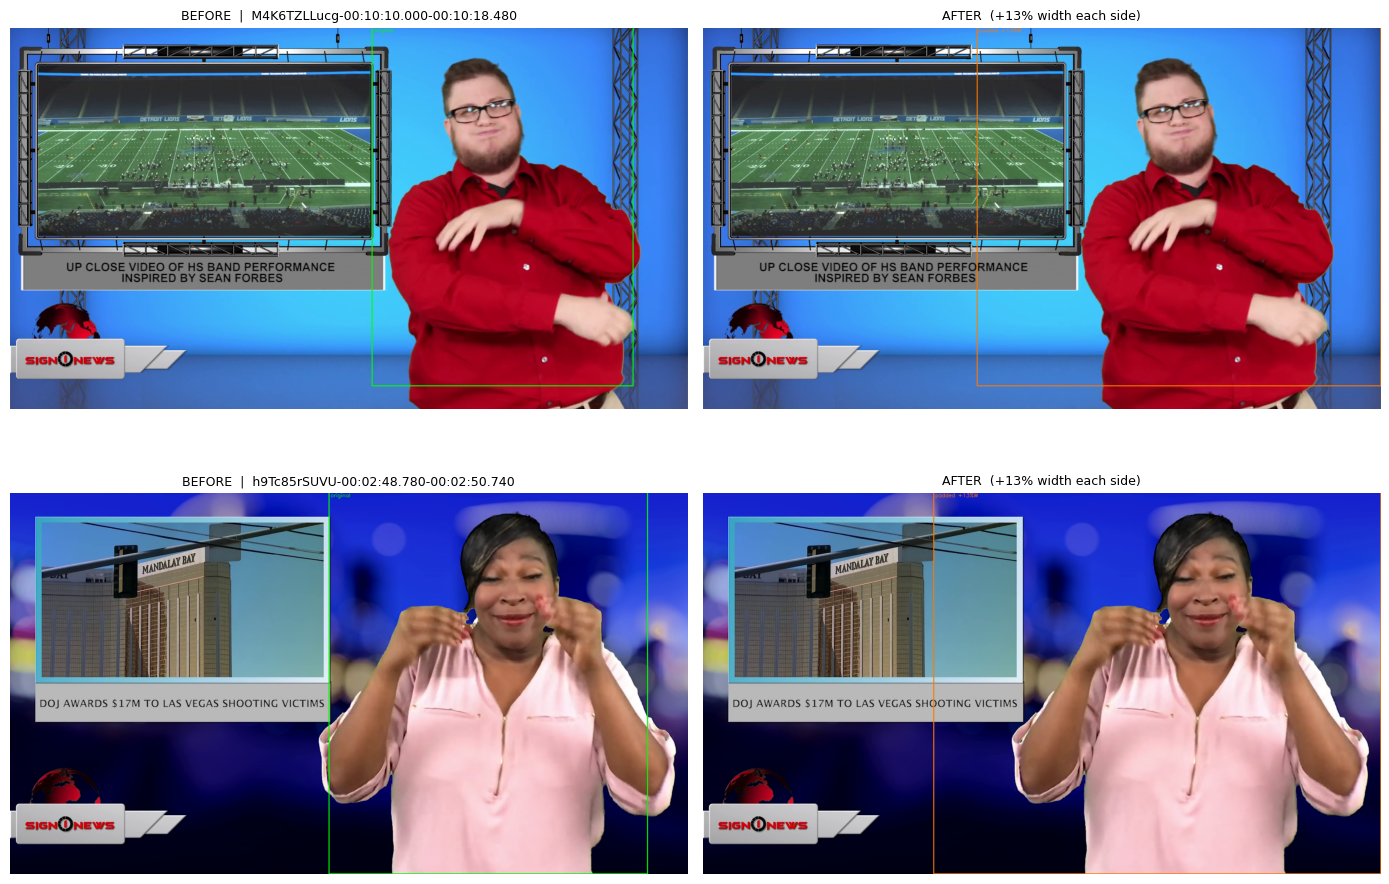

In [1]:
# ── OpenASL Bounding Box Visualization ──
import json
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import random

BBOX_FILE  = Path("../data/bbox-v1.0.json")
VIDEO_DIR  = Path("D:/OpenASL/raw_videos")

BBOX_WIDTH_PAD = 0.13  # tweak here to assess padding

with open(BBOX_FILE, "r") as f:
    bbox_data = json.load(f)

video_files = {p.stem: p for p in VIDEO_DIR.glob("*.mp4")}

matched = {}
for key in bbox_data:
    if key in video_files:
        matched[key] = video_files[key]
    else:
        youtube_id = key.split("-")[0]
        if youtube_id in video_files:
            matched[key] = video_files[youtube_id]

print(f"Matched: {len(matched)} / {len(bbox_data)}")


def get_padded_bbox(bbox, W, H):
    pad_px = BBOX_WIDTH_PAD * W
    return [
        max(0, bbox[0] * W - pad_px) / W,
        bbox[1],
        min(W, bbox[2] * W + pad_px) / W,
        bbox[3],
    ]


def draw_bbox(frame, bbox, color, label):
    h, w = frame.shape[:2]
    x1 = max(0, min(int(bbox[0] * w), w - 1))
    y1 = max(0, min(int(bbox[1] * h), h - 1))
    x2 = max(0, min(int(bbox[2] * w), w - 1))
    y2 = max(0, min(int(bbox[3] * h), h - 1))
    out = frame.copy()
    cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
    cv2.putText(out, label, (x1 + 4, max(y1 - 6, 14)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return out


def get_mid_frame(video_path):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()
    return (frame if ret else None), W, H


def preview_before_after(n_clips=2):
    keys = random.sample(list(matched.keys()), n_clips)

    fig, axes = plt.subplots(n_clips, 2, figsize=(14, 5 * n_clips))
    if n_clips == 1:
        axes = [axes]

    for row, key in enumerate(keys):
        bbox = bbox_data[key]
        frame, W, H = get_mid_frame(matched[key])
        if frame is None:
            print(f"Could not read frame for {key}")
            continue

        padded = get_padded_bbox(bbox, W, H)

        before = draw_bbox(frame, bbox,   (0, 255, 0),   "original")
        after  = draw_bbox(frame, padded, (0, 120, 255), f"padded +{int(BBOX_WIDTH_PAD*100)}%W")

        axes[row][0].imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
        axes[row][0].set_title(f"BEFORE  |  {key[:50]}", fontsize=9)
        axes[row][0].axis("off")

        axes[row][1].imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
        axes[row][1].set_title(f"AFTER  (+{int(BBOX_WIDTH_PAD*100)}% width each side)", fontsize=9)
        axes[row][1].axis("off")

    plt.tight_layout()
    plt.show()


preview_before_after(n_clips=2)

In [38]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

splits = {
    "train": PROJECT_ROOT / "data" / "openasl_train_missing_filtered.tsv",
    "val":   PROJECT_ROOT / "data" / "openasl_val_missing_filtered.tsv",
    "test":  PROJECT_ROOT / "data" / "openasl_test_missing_filtered.tsv",
}

def time_str_to_sec(t):
    parts = t.split(":")
    return sum(float(x) * 60**i for i, x in enumerate(reversed(parts)))

dfs = {}
for name, path in splits.items():
    df = pd.read_csv(path, sep="\t")
    df["duration_sec"] = (df["end"].apply(time_str_to_sec) - df["start"].apply(time_str_to_sec))
    dfs[name] = df

all_df = pd.concat(dfs.values(), ignore_index=True)
dfs["combined"] = all_df

for name, df in dfs.items():
    total_hrs   = df["duration_sec"].sum() / 3600
    total_words = df["word_count"].sum() if "word_count" in df.columns else df["raw-text"].dropna().apply(lambda x: len(x.split())).sum()
    print(f"{name:>10}: {len(df):>7,} clips | {total_hrs:6.1f} hrs | {total_words:>10,.0f} words | {df['duration_sec'].mean():.1f}s avg duration")

     train:  48,217 clips |   57.3 hrs |    458,117 words | 4.3s avg duration
       val:     518 clips |    0.6 hrs |      5,326 words | 4.2s avg duration
      test:     503 clips |    0.6 hrs |      5,288 words | 4.6s avg duration
  combined:  49,238 clips |   58.5 hrs |    468,731 words | 4.3s avg duration


In [ ]:
import cv2
import json
import numpy as np
import pandas as pd
from pathlib import Path
import mediapipe as mp

VIDEO_ID="t9lQq2SL7bo"
PROJECT_ROOT = Path("..").resolve()
VIDEO_PATH   = Path(rf"D:/OpenASL/raw_videos/{VIDEO_ID}.mp4")
OUTPUT_PATH  = Path(rf"C:/Users/mamou/Downloads/{VIDEO_ID}_bbox_mediapipe.mp4")
BBOX_FILE    = PROJECT_ROOT / "data" / "bbox-v1.0.json"

def time_str_to_sec(t):
    parts = t.split(":")
    return sum(float(x) * 60**i for i, x in enumerate(reversed(parts)))

# Load bbox & find the clip for this video
with open(BBOX_FILE) as f:
    bbox_data = json.load(f)

for split in ["train", "val", "test"]:
    df = pd.read_csv(PROJECT_ROOT / "data" / f"openasl_{split}_missing_filtered.tsv", sep="\t")
    row = df[df["yid"] == VIDEO_ID]
    if len(row) > 0:
        row = row.iloc[0]
        break

vid       = row["vid"]
start_sec = time_str_to_sec(row["start"])
end_sec   = time_str_to_sec(row["end"])
bbox      = bbox_data[vid]  # [x1, y1, x2, y2] normalized
print(f"Clip: {vid}  |  {start_sec:.2f}s -> {end_sec:.2f}s  |  bbox: {bbox}")

# Open video
cap     = cv2.VideoCapture(str(VIDEO_PATH))
src_fps = cap.get(cv2.CAP_PROP_FPS)
W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Bbox in pixels (with same padding as pipeline: BBOX_WIDTH_PAD=0.12)
BBOX_WIDTH_PAD = 0.0
BBOX_HEIGHT_PAD = 0.1
pad_px = int(BBOX_WIDTH_PAD * W)
pad_py = int(BBOX_HEIGHT_PAD * H)
bx1 = max(0, int(bbox[0] * W) - pad_px)
by1 = max(0, int(bbox[1] * H) - pad_py)
bx2 = min(W, int(bbox[2] * W) + pad_px)
by2 = min(H, int(bbox[3] * H) + pad_py)

start_frame = int(start_sec * src_fps)
end_frame   = int(end_sec   * src_fps)

# Writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(str(OUTPUT_PATH), fourcc, src_fps, (W, H))

# MediaPipe
holistic = mp.solutions.holistic.Holistic(
    static_image_mode=False,
    model_complexity=0,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)
mp_draw = mp.solutions.drawing_utils
draw_spec_lm   = mp_draw.DrawingSpec(color=(0, 255, 0),  thickness=1, circle_radius=1)
draw_spec_conn = mp_draw.DrawingSpec(color=(0, 180, 255), thickness=1)

print(f"Processing {total_frames} frames...")
for frame_idx in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break

    in_clip = start_frame <= frame_idx <= end_frame

    # Always draw bbox (red outside clip, green inside clip)
    color = (0, 255, 0) if in_clip else (0, 0, 255)
    cv2.rectangle(frame, (bx1, by1), (bx2, by2), color, 2)
    cv2.putText(frame, f"bbox ({'IN CLIP' if in_clip else 'out'})",
                (bx1, by1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    # Run MediaPipe only inside clip (on cropped region, same as pipeline)
    if in_clip:
        crop = frame[by1:by2, bx1:bx2].copy()
        rgb  = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        res  = holistic.process(rgb)

        # Draw landmarks on crop, paste back
        if res.face_landmarks:
            mp_draw.draw_landmarks(crop, res.face_landmarks,
                                   mp.solutions.face_mesh.FACEMESH_CONTOURS,
                                   draw_spec_lm, draw_spec_conn)
        if res.pose_landmarks:
            mp_draw.draw_landmarks(crop, res.pose_landmarks,
                                   mp.solutions.holistic.POSE_CONNECTIONS,
                                   draw_spec_lm, draw_spec_conn)
        if res.left_hand_landmarks:
            mp_draw.draw_landmarks(crop, res.left_hand_landmarks,
                                   mp.solutions.hands.HAND_CONNECTIONS,
                                   draw_spec_lm, draw_spec_conn)
        if res.right_hand_landmarks:
            mp_draw.draw_landmarks(crop, res.right_hand_landmarks,
                                   mp.solutions.hands.HAND_CONNECTIONS,
                                   draw_spec_lm, draw_spec_conn)

        frame[by1:by2, bx1:bx2] = crop

    # Frame counter
    cv2.putText(frame, f"frame {frame_idx}/{total_frames}  {frame_idx/src_fps:.1f}s",
                (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    out.write(frame)

cap.release()
out.release()
holistic.close()
print(f"Saved -> {OUTPUT_PATH}")

Clip: t9lQq2SL7bo-00:02:53.000-00:02:58.649  |  173.00s -> 178.65s  |  bbox: [0.3363497201068487, -0.11050395544837503, 0.7274170294989074, 1.0497757540029637]
Processing 5744 frames...


c:\ProgramData\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Saved -> C:\Users\mamou\Downloads\{VIDEO_ID}_bbox_mediapipe.mp4


In [53]:
import cv2
from pathlib import Path
import mediapipe as mp

VIDEO_ID_FULL = "t9lQq2SL7bo"
VIDEO_PATH  = Path(rf"D:/OpenASL/raw_videos/{VIDEO_ID_FULL}.mp4")
OUTPUT_PATH = Path(rf"C:/Users/mamou/Downloads/{VIDEO_ID_FULL}_mediapipe.mp4")

RIGHT_CROP_PX = 0  # pixels to crop from the right

cap          = cv2.VideoCapture(str(VIDEO_PATH))
src_fps      = cap.get(cv2.CAP_PROP_FPS)
W            = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
OUT_W        = W - RIGHT_CROP_PX

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(str(OUTPUT_PATH), fourcc, src_fps, (OUT_W, H))

holistic = mp.solutions.holistic.Holistic(
    static_image_mode=False,
    model_complexity=0,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)
mp_draw        = mp.solutions.drawing_utils
draw_spec_lm   = mp_draw.DrawingSpec(color=(0, 255, 0),   thickness=1, circle_radius=1)
draw_spec_conn = mp_draw.DrawingSpec(color=(0, 180, 255), thickness=1)

print(f"Processing {total_frames} frames... output width: {OUT_W}px")
for frame_idx in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    res = holistic.process(rgb)

    if res.face_landmarks:
        mp_draw.draw_landmarks(frame, res.face_landmarks,
                               mp.solutions.face_mesh.FACEMESH_CONTOURS,
                               draw_spec_lm, draw_spec_conn)
    if res.pose_landmarks:
        mp_draw.draw_landmarks(frame, res.pose_landmarks,
                               mp.solutions.holistic.POSE_CONNECTIONS,
                               draw_spec_lm, draw_spec_conn)
    if res.left_hand_landmarks:
        mp_draw.draw_landmarks(frame, res.left_hand_landmarks,
                               mp.solutions.hands.HAND_CONNECTIONS,
                               draw_spec_lm, draw_spec_conn)
    if res.right_hand_landmarks:
        mp_draw.draw_landmarks(frame, res.right_hand_landmarks,
                               mp.solutions.hands.HAND_CONNECTIONS,
                               draw_spec_lm, draw_spec_conn)

    cv2.putText(frame, f"frame {frame_idx}/{total_frames}  {frame_idx/src_fps:.1f}s",
                (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    out.write(frame[:, :OUT_W])

cap.release()
out.release()
holistic.close()
print(f"Saved -> {OUTPUT_PATH}")

Processing 5744 frames... output width: 854px
Saved -> C:\Users\mamou\Downloads\t9lQq2SL7bo_mediapipe.mp4


# OpenASL Dataset Processing
Mirrors the exact How2Sign pipeline:
- 116 landmarks (60 face + 14 pose + 42 hands), target 20 FPS
- Center & normalize by shoulder width
- Bounding-box crop before MediaPipe (unique to OpenASL — improves detection)
- Per-landmark forward-fill gaps <= 3 frames, mask long gaps
- Filter clips: 1.3s - 8.0s duration
- Discard clips with low landmark coverage (likely bad bbox placement)
- Save NPZ (raw) then NPZ (preprocessed), plus final manifest TSV

In [4]:
from pathlib import Path
import cv2
import numpy as np

VIDEO_DIR = Path(r'D:\OpenASL\raw_videos')
video_files = list(VIDEO_DIR.glob('*.mp4'))

fps_list = []
for vf in video_files:
    cap = cv2.VideoCapture(str(vf))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps > 0:
        fps_list.append(fps)

fps_arr = np.array(fps_list)
print(f'Videos scanned : {len(fps_list)} / {len(video_files)}')
print(f'Min FPS        : {fps_arr.min():.2f}')
print(f'Max FPS        : {fps_arr.max():.2f}')
print(f'Mean FPS       : {fps_arr.mean():.2f}')
print(f'Unique FPS values:')
for v, c in zip(*np.unique(fps_arr.round(2), return_counts=True)):
    print(f'  {v:.2f} fps  ->  {c} videos')

Videos scanned : 1889 / 1889
Min FPS        : 23.00
Max FPS        : 60.01
Mean FPS       : 29.12
Unique FPS values:
  23.00 fps  ->  1 videos
  23.98 fps  ->  200 videos
  24.00 fps  ->  156 videos
  25.00 fps  ->  4 videos
  26.56 fps  ->  1 videos
  29.18 fps  ->  1 videos
  29.84 fps  ->  1 videos
  29.91 fps  ->  1 videos
  29.97 fps  ->  1176 videos
  29.98 fps  ->  2 videos
  29.99 fps  ->  1 videos
  30.00 fps  ->  326 videos
  30.09 fps  ->  1 videos
  59.94 fps  ->  17 videos
  60.01 fps  ->  1 videos


In [2]:
# %%
## Imports & Config

from pathlib import Path
import json
import csv
import math
import time
import random
import warnings
import concurrent.futures
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
from tqdm import tqdm

warnings.filterwarnings("ignore")

# -- Paths ---------------------------------------------------------------------
PROJECT_ROOT    = Path("..").resolve()
VIDEO_DIR       = Path("D:/OpenASL/raw_videos")
BBOX_FILE       = PROJECT_ROOT / "data" / "bbox-v1.0.json"
TSV_TRAIN       = PROJECT_ROOT / "data" / "openasl_train_missing_filtered.tsv"
TSV_VAL         = PROJECT_ROOT / "data" / "openasl_val_missing_filtered.tsv"
TSV_TEST        = PROJECT_ROOT / "data" / "openasl_test_missing_filtered.tsv"

KP_DIR          = PROJECT_ROOT / "data" / "openasl_keypoints"                # raw NPZ (uncompressed)
KP_PRE_DIR      = PROJECT_ROOT / "data" / "openasl_keypoints_preprocessed"  # normalized NPZ (uncompressed)

for split in ["train", "val", "test"]:
    (KP_DIR / split).mkdir(parents=True, exist_ok=True)
    (KP_PRE_DIR / split).mkdir(parents=True, exist_ok=True)

# -- Keypoint config (must match How2Sign exactly) -----------------------------
TARGET_FPS           = 20
MAX_FRAMES           = 160      # 8s @ 20 FPS -- same cap as training
MIN_DURATION_SEC     = 1.3
MAX_DURATION_SEC     = 8.0
FORWARD_FILL_MAX_GAP = 3        # frames -- applies both per-landmark and to normalization reference
NUM_WORKERS          = 5        # parallel extraction threads
                                 # NOTE: ThreadPoolExecutor is used instead of ProcessPoolExecutor
                                 # because this runs inside a Jupyter notebook on Windows where
                                 # ProcessPoolExecutor requires spawn-safe pickling of worker fns.
                                 # MediaPipe releases the GIL for its C++ core, so threads still
                                 # provide meaningful parallelism despite the Python GIL.

# -- Bounding box padding ------------------------------------------------------
# Hands frequently extend beyond the annotated bbox width.
# BBOX_WIDTH_PAD: pads each horizontal side by a fraction of frame width.
# BBOX_HEIGHT_PAD: pads top/bottom by a fraction of frame height (high-arm signs).
BBOX_WIDTH_PAD  = 0.45  # 45% of frame width, both sides
BBOX_HEIGHT_PAD = 0.3   # 30% of frame height, both sides

# -- Landmark coverage filtering -----------------------------------------------
MIN_LANDMARK_COVERAGE = 0.65  # overall (secondary): avg across all 116 landmarks
MIN_HAND_COVERAGE     = 0.65  # primary: avg across 42 hand landmarks

# Face landmarks: lips + eyebrows (60 total, SAME indices as How2Sign)
mp_face_mesh = mp.solutions.face_mesh
FACEMESH_LIPS_IDX = sorted({idx for pair in mp_face_mesh.FACEMESH_LIPS         for idx in pair})
FACEMESH_L_BROW   = sorted({idx for pair in mp_face_mesh.FACEMESH_LEFT_EYEBROW  for idx in pair})
FACEMESH_R_BROW   = sorted({idx for pair in mp_face_mesh.FACEMESH_RIGHT_EYEBROW for idx in pair})
FACE_IDX = sorted(set(FACEMESH_LIPS_IDX + FACEMESH_L_BROW + FACEMESH_R_BROW))  # 60 landmarks

# Pose landmarks: upper body only (indices 11-24, 14 total)
POSE_IDX = list(range(11, 25))  # shoulders, elbows, wrists, hips

# Hand landmarks: 21 each side
N_HAND  = 21
N_FACE  = len(FACE_IDX)       # 60
N_POSE  = len(POSE_IDX)       # 14
N_TOTAL = N_FACE + N_POSE + N_HAND * 2  # 116

print(f"Face: {N_FACE}, Pose: {N_POSE}, Hands: {N_HAND*2}, Total: {N_TOTAL}")
assert N_TOTAL == 116, "Landmark count mismatch with How2Sign!"

Face: 60, Pose: 14, Hands: 42, Total: 116


In [3]:
# %%
## Load TSV Manifests

def time_str_to_sec(t: str) -> float:
    """Convert HH:MM:SS.mmm to total seconds."""
    parts = t.split(":")
    return sum(float(x) * 60 ** i for i, x in enumerate(reversed(parts)))


def load_tsv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df["start_sec"] = df["start"].apply(time_str_to_sec)
    df["end_sec"]   = df["end"].apply(time_str_to_sec)
    return df


df_train = load_tsv(TSV_TRAIN)
df_val   = load_tsv(TSV_VAL)
df_test  = load_tsv(TSV_TEST)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
print(f"\nColumns: {list(df_train.columns)}")
print(f"\nSample row:\n{df_train.iloc[0]}")


Train: 48,217 | Val: 518 | Test: 503

Columns: ['vid', 'yid', 'start', 'end', 'raw-text', 'tokenized-text', 'gloss', 'split', 'duration_sec', 'word_count', 'start_sec', 'end_sec']

Sample row:
vid               RjJSxzMkC90-00:00:25.123-00:00:27.524
yid                                         RjJSxzMkC90
start                                      00:00:25.123
end                                        00:00:27.524
raw-text                            Bush through relay.
tokenized-text                       bush through relay
gloss                                               NaN
split                                             train
duration_sec                                      2.401
word_count                                            3
start_sec                                        25.123
end_sec                                          27.524
Name: 0, dtype: object


In [4]:
# %%
## Load Bounding Boxes

with open(BBOX_FILE, "r") as f:
    bbox_data = json.load(f)

print(f"Loaded {len(bbox_data):,} bounding box entries")

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    covered = df["vid"].isin(bbox_data).sum()
    print(f"  {name}: bbox coverage {covered}/{len(df)} ({100*covered/len(df):.1f}%)")

Loaded 99,375 bounding box entries
  train: bbox coverage 48217/48217 (100.0%)
  val: bbox coverage 518/518 (100.0%)
  test: bbox coverage 503/503 (100.0%)


In [5]:
# %%
## Match Video Files & Report Coverage

video_files = {p.stem: p for p in VIDEO_DIR.glob("*.mp4")}
print(f"Found {len(video_files):,} video files in {VIDEO_DIR}")

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    matched = df["yid"].isin(video_files).sum()
    print(f"  {name}: video match {matched}/{len(df)} ({100*matched/len(df):.1f}%)")

missing_yids = set(df_train["yid"]) - set(video_files)
print(f"\nMissing YouTube IDs (train): {len(missing_yids)}")

Found 1,889 video files in D:\OpenASL\raw_videos
  train: video match 48217/48217 (100.0%)
  val: video match 518/518 (100.0%)
  test: video match 503/503 (100.0%)

Missing YouTube IDs (train): 0


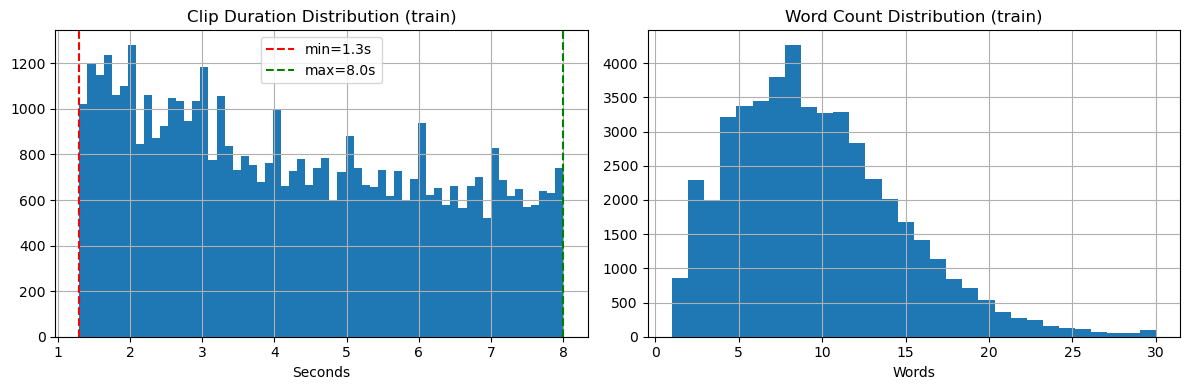

[train] Within [1.3s, 8.0s]: 48,217 / 48,217 (100.0%)


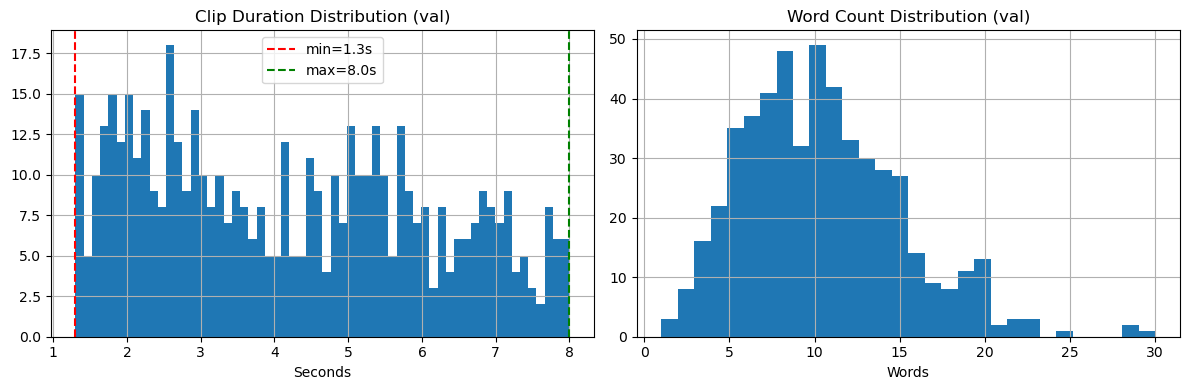

[val] Within [1.3s, 8.0s]: 518 / 518 (100.0%)


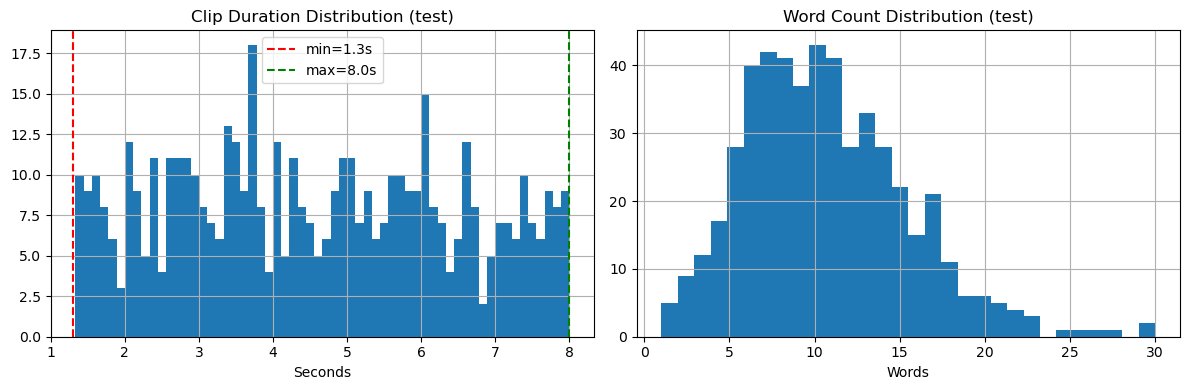

[test] Within [1.3s, 8.0s]: 503 / 503 (100.0%)


In [14]:
import os
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

for split, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    df["duration_sec"].clip(0, 15).hist(bins=60, ax=axes[0])
    axes[0].axvline(MIN_DURATION_SEC, color="r", linestyle="--", label=f"min={MIN_DURATION_SEC}s")
    axes[0].axvline(MAX_DURATION_SEC, color="g", linestyle="--", label=f"max={MAX_DURATION_SEC}s")
    axes[0].set_title(f"Clip Duration Distribution ({split})")
    axes[0].set_xlabel("Seconds")
    axes[0].legend()

    df["word_count"].clip(0, 30).hist(bins=30, ax=axes[1])
    axes[1].set_title(f"Word Count Distribution ({split})")
    axes[1].set_xlabel("Words")

    plt.tight_layout()
    plt.savefig(f"../images/openasl_{split}_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    within = df[
        (df["duration_sec"] >= MIN_DURATION_SEC) &
        (df["duration_sec"] <= MAX_DURATION_SEC)
    ]
    print(f"[{split}] Within [{MIN_DURATION_SEC}s, {MAX_DURATION_SEC}s]: {len(within):,} / {len(df):,} ({100*len(within)/len(df):.1f}%)")

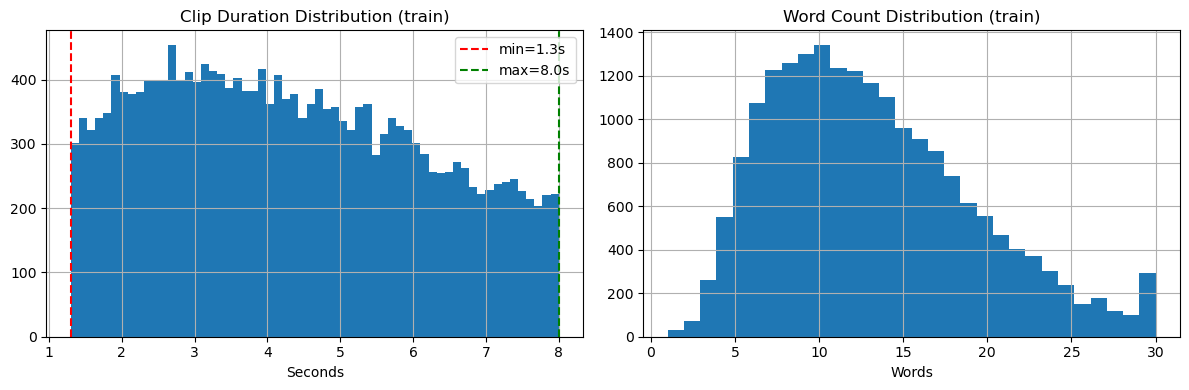

[train] Within [1.3s, 8.0s]: 19,935 / 19,935 (100.0%)


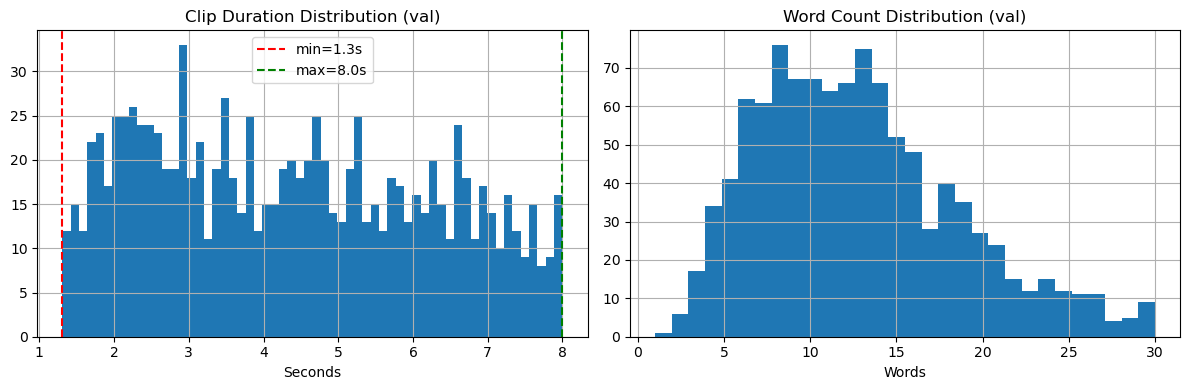

[val] Within [1.3s, 8.0s]: 1,051 / 1,051 (100.0%)


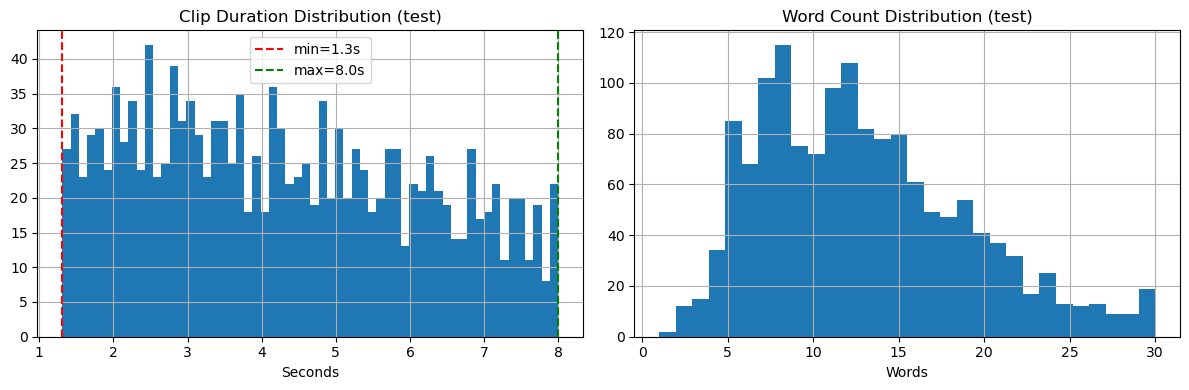

[test] Within [1.3s, 8.0s]: 1,464 / 1,464 (100.0%)


In [17]:
# For hwo2sign Dataset
## Duration Distribution - How2Sign

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

splits = {
    "train": r"..\data\(final)_how2sign_train_filtered.csv",
    "val":   r"..\data\(final)_how2sign_val_filtered.csv",
    "test":  r"..\data\(final)_how2sign_test_filtered.csv",
}

for split, path in splits.items():
    df_h2s = pd.read_csv(path, sep="\t")

     # Compute word_count if not present
    if "word_count" not in df_h2s.columns:
        df_h2s["word_count"] = df_h2s["SENTENCE"].dropna().apply(lambda x: len(str(x).split()))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    df_h2s["duration_sec"].clip(0, 15).hist(bins=60, ax=axes[0])
    axes[0].axvline(MIN_DURATION_SEC, color="r", linestyle="--", label=f"min={MIN_DURATION_SEC}s")
    axes[0].axvline(MAX_DURATION_SEC, color="g", linestyle="--", label=f"max={MAX_DURATION_SEC}s")
    axes[0].set_title(f"Clip Duration Distribution ({split})")
    axes[0].set_xlabel("Seconds")
    axes[0].legend()

    df_h2s["word_count"].clip(0, 30).hist(bins=30, ax=axes[1])
    axes[1].set_title(f"Word Count Distribution ({split})")
    axes[1].set_xlabel("Words")

    plt.tight_layout()
    plt.savefig(f"../images/how2sign_{split}_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    within = df_h2s[
        (df_h2s["duration_sec"] >= MIN_DURATION_SEC) &
        (df_h2s["duration_sec"] <= MAX_DURATION_SEC)
    ]
    print(f"[{split}] Within [{MIN_DURATION_SEC}s, {MAX_DURATION_SEC}s]: {len(within):,} / {len(df_h2s):,} ({100*len(within)/len(df_h2s):.1f}%)")

In [6]:
# %%
## Core: Frame Extraction with Bounding Box Crop

def extract_clip_frames(video_path: Path, start_sec: float, end_sec: float,
                        bbox: list, target_fps: int = TARGET_FPS):
    """
    Extract frames for one clip from a full YouTube video.
    Applies bounding-box crop (with padding) before returning frames so MediaPipe
    focuses on the signer only. Unique to OpenASL since videos are full YouTube
    recordings, unlike the pre-cropped How2Sign clips.

    FIX: Temporal subsampling now uses np.linspace instead of modulo to avoid
    uneven frame spacing caused by rounding in modulo-based intervals.

    Args:
        video_path : path to full YouTube MP4
        start_sec  : clip start in seconds
        end_sec    : clip end in seconds
        bbox       : [x1, y1, x2, y2] normalized (may be slightly <0 or >1)
        target_fps : desired output frames per second

    Returns:
        frames  : list of BGR np.ndarray, each cropped to padded bbox
        src_fps : original video FPS
    """
    cap = cv2.VideoCapture(str(video_path))
    src_fps = cap.get(cv2.CAP_PROP_FPS)
    if src_fps <= 0:
        cap.release()
        return [], 0.0

    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

    start_frame = int(start_sec * src_fps)
    end_frame   = int(end_sec   * src_fps)
    total_src   = max(end_frame - start_frame + 1, 1)

    # FIX: use linspace for uniform temporal subsampling (avoids drift from modulo rounding)
    n_target = max(int(round((end_sec - start_sec) * target_fps)), 1)
    sample_offsets = set(np.linspace(0, total_src - 1, n_target, dtype=int).tolist())

    # Bbox in pixel coordinates with horizontal + vertical padding, clamped to frame
    h_pad_px = int(BBOX_HEIGHT_PAD * H)
    w_pad_px = int(BBOX_WIDTH_PAD  * W)
    bx1 = max(0, int(bbox[0] * W) - w_pad_px)
    by1 = max(0, int(bbox[1] * H) - h_pad_px)
    bx2 = min(W, int(bbox[2] * W) + w_pad_px)
    by2 = min(H, int(bbox[3] * H) + h_pad_px)

    # Degenerate bbox fallback: use full frame
    if bx2 <= bx1 or by2 <= by1:
        bx1, by1, bx2, by2 = 0, 0, W, H

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames = []
    for offset in range(total_src):
        ret, frame = cap.read()
        if not ret:
            break
        if offset in sample_offsets:
            frames.append(frame[by1:by2, bx1:bx2])

    cap.release()
    return frames, src_fps

In [7]:
# %%
## Core: MediaPipe Keypoint Extraction + Per-Landmark Forward-Fill

def extract_keypoints_from_frames(frames: list):
    """
    Run MediaPipe Holistic on a list of BGR frames.
    Extracts EXACTLY the same 116 landmarks as How2Sign:
        - 60 face  (lips + eyebrows)
        - 14 pose  (upper body, indices 11-24)
        - 21 left  hand
        - 21 right hand

    FIX: After raw extraction, applies per-landmark forward-fill up to
    FORWARD_FILL_MAX_GAP frames. This fills short detection dropouts on
    individual landmarks (e.g. a hand detected in t-1 but missed in t)
    before normalization. Gaps longer than the threshold remain masked (0).

    Returns:
        keypoints : (T, 116, 3) float32 -- x, y, z per landmark
        mask      : (T, 116)   uint8    -- 1=detected (or filled), 0=missing
    """
    T = len(frames)
    keypoints = np.zeros((T, N_TOTAL, 3), dtype=np.float32)
    mask      = np.zeros((T, N_TOTAL),    dtype=np.uint8)

    holistic = mp.solutions.holistic.Holistic(
        static_image_mode        = False,
        model_complexity         = 0,
        min_detection_confidence = 0.5,
        min_tracking_confidence  = 0.5,
        refine_face_landmarks    = False,  # no iris -- keeps landmark set identical to How2Sign
    )

    for t, frame in enumerate(frames):
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = holistic.process(rgb)
        offset = 0

        # -- Face (60 landmarks) -----------------------------------------------
        if result.face_landmarks:
            lms = result.face_landmarks.landmark
            for i, idx in enumerate(FACE_IDX):
                lm = lms[idx]
                keypoints[t, offset + i] = [lm.x, lm.y, lm.z]
                mask[t, offset + i] = 1
        offset += N_FACE

        # -- Pose (14 landmarks, indices 11-24) --------------------------------
        if result.pose_landmarks:
            lms = result.pose_landmarks.landmark
            for i, idx in enumerate(POSE_IDX):
                lm = lms[idx]
                keypoints[t, offset + i] = [lm.x, lm.y, lm.z]
                mask[t, offset + i] = 1
        offset += N_POSE

        # -- Left hand (21 landmarks) -----------------------------------------
        if result.left_hand_landmarks:
            for i, lm in enumerate(result.left_hand_landmarks.landmark):
                keypoints[t, offset + i] = [lm.x, lm.y, lm.z]
                mask[t, offset + i] = 1
        offset += N_HAND

        # -- Right hand (21 landmarks) ----------------------------------------
        if result.right_hand_landmarks:
            for i, lm in enumerate(result.right_hand_landmarks.landmark):
                keypoints[t, offset + i] = [lm.x, lm.y, lm.z]
                mask[t, offset + i] = 1

    holistic.close()

    # FIX: Per-landmark forward-fill up to FORWARD_FILL_MAX_GAP frames.
    # Iterates each landmark independently to propagate the last valid detection
    # across short gaps caused by transient occlusion or detection jitter.
    # Once a gap exceeds FORWARD_FILL_MAX_GAP, filling stops and the landmark
    # remains masked (0) to avoid propagating stale data too far.
    for lm_i in range(N_TOTAL):
        gap_start    = None
        last_valid_t = None
        for t in range(T):
            if mask[t, lm_i] == 1:
                if gap_start is not None:
                    if (t - gap_start) <= FORWARD_FILL_MAX_GAP and last_valid_t is not None:
                        for gap_t in range(gap_start, t):
                            keypoints[gap_t, lm_i] = keypoints[last_valid_t, lm_i]
                            mask[gap_t, lm_i]      = 1
                    gap_start = None
                last_valid_t = t
            else:
                if gap_start is None:
                    gap_start = t
        # trailing gap
        if gap_start is not None and last_valid_t is not None:
            if (T - gap_start) <= FORWARD_FILL_MAX_GAP:
                for gap_t in range(gap_start, T):
                    keypoints[gap_t, lm_i] = keypoints[last_valid_t, lm_i]
                    mask[gap_t, lm_i] = 1

    return keypoints, mask

In [8]:
# %%
## Core: Normalization (identical to How2Sign)

# Shoulder indices inside the (T, 116, 3) array:
# Pose block starts at offset N_FACE (60).
# POSE_IDX[0] = pose landmark 11 = left shoulder
# POSE_IDX[1] = pose landmark 12 = right shoulder
POSE_OFFSET        = N_FACE   # 60
LEFT_SHOULDER_IDX  = POSE_OFFSET + 0
RIGHT_SHOULDER_IDX = POSE_OFFSET + 1


def center_and_normalize(keypoints: np.ndarray, mask: np.ndarray):
    """
    Normalize keypoints to be translation- and scale-invariant.
    Identical to the How2Sign normalization:
        1. Per-frame body center = midpoint of both shoulders
        2. Subtract body center from all X, Y
        3. Shoulder width = Euclidean distance between shoulders
        4. Divide X, Y by shoulder width
        5. Z left unchanged (relative depth)
        6. Forward-fill missing shoulder reference up to FORWARD_FILL_MAX_GAP frames
        7. Replace residual NaN / inf with 0

    FIX: frames_since_valid is now checked against FORWARD_FILL_MAX_GAP.
    Previously the last valid reference was used indefinitely regardless
    of how many frames had passed, allowing stale normalization to persist
    across arbitrarily long shoulder occlusions.

    Args:
        keypoints : (T, N, 3) float32
        mask      : (T, N)    uint8

    Returns:
        keypoints_norm : (T, N, 3) float32
        mask           : (T, N)    uint8   (unchanged)
    """
    T  = keypoints.shape[0]
    kp = keypoints.copy().astype(np.float64)

    last_valid_center  = None
    last_valid_scale   = None
    frames_since_valid = 0

    has_ref = np.zeros(T, dtype=bool)   
    for t in range(T):
        ls_valid = mask[t, LEFT_SHOULDER_IDX]  == 1
        rs_valid = mask[t, RIGHT_SHOULDER_IDX] == 1

        if ls_valid and rs_valid:
            ls = kp[t, LEFT_SHOULDER_IDX,  :2]
            rs = kp[t, RIGHT_SHOULDER_IDX, :2]
            body_center    = (ls + rs) / 2.0
            shoulder_width = np.linalg.norm(rs - ls)

            if shoulder_width > 1e-6:
                last_valid_center  = body_center
                last_valid_scale   = shoulder_width
                frames_since_valid = 0
            else:
                frames_since_valid += 1
        else:
            frames_since_valid += 1

        # FIX: respect FORWARD_FILL_MAX_GAP -- do not use stale reference beyond this
        if last_valid_center is None or frames_since_valid > FORWARD_FILL_MAX_GAP:
            continue  # no valid reference within fill window -- skip frame

        center = last_valid_center
        scale  = last_valid_scale

        has_ref[t] = True
        kp[t, :, 0] = (kp[t, :, 0] - center[0]) / scale
        kp[t, :, 1] = (kp[t, :, 1] - center[1]) / scale
        # Z unchanged

    kp[~has_ref] = 0.0
    mask[~has_ref] = 0  # add this line
    kp = np.nan_to_num(kp, nan=0.0, posinf=0.0, neginf=0.0)
    return kp.astype(np.float32), mask

In [9]:
# %%
## Full Pipeline: Single Clip Worker

def process_clip(row: dict, split: str) -> dict:
    """
    Full pipeline for one clip row:
      1. Skip if outputs already exist (resume-safe)
      2. Resolve video file and bbox
      3. Extract frames with bbox crop (horizontal + vertical padding)
      4. Run MediaPipe + per-landmark forward-fill
      5. Check landmark coverage -- discard if below thresholds
      6. Save raw NPZ (uncompressed)
      7. Normalize (shoulder-based) with bounded forward-fill reference
      8. Save preprocessed NPZ (compressed)

    Returns a status dict for logging.
    """
    vid       = row["vid"]
    yid       = row["yid"]
    start_sec = float(row["start_sec"])
    end_sec   = float(row["end_sec"])

    safe_vid = vid.replace(":", "-")
    raw_out = KP_DIR     / split / f"{safe_vid}.npz"
    safe_vid = row['vid'].replace(":", "-")
    pre_out = KP_PRE_DIR / split / f"{safe_vid}.npz"
    if raw_out.exists() and pre_out.exists():
        return {"vid": vid, "status": "skipped"}

    video_path = VIDEO_DIR / f"{yid}.mp4"
    if not video_path.exists():
        return {"vid": vid, "status": "no_video"}

    bbox = bbox_data.get(vid)
    if bbox is None:
        return {"vid": vid, "status": "no_bbox"}

    try:
        frames, src_fps = extract_clip_frames(video_path, start_sec, end_sec, bbox)

        if len(frames) == 0:
            return {"vid": vid, "status": "no_frames"}

        # extract_keypoints_from_frames now includes per-landmark forward-fill
        keypoints, mask = extract_keypoints_from_frames(frames)

        # -- Coverage check: evaluated AFTER forward-fill so filled frames count as valid
        coverage      = float(mask.mean())
        hand_mask     = mask[:, N_FACE + N_POSE:]   # (T, 42) -- left + right hands
        hand_coverage = float(hand_mask.mean())

        if hand_coverage < MIN_HAND_COVERAGE or coverage < MIN_LANDMARK_COVERAGE:
            return {
                "vid"          : vid,
                "status"       : "low_coverage",
                "coverage"     : round(coverage, 3),
                "hand_coverage": round(hand_coverage, 3),
            }

        # Save raw NPZ (uncompressed -- intentional for fast debug I/O)
        np.savez(
            raw_out,
            keypoints = keypoints,
            mask      = mask,
            fps       = np.array([TARGET_FPS]),
            face_idx  = np.array(FACE_IDX),
            pose_idx  = np.array(POSE_IDX),
        )

        # Normalize and save preprocessed NPZ (compressed -- used for training)
        keypoints_norm, mask_norm = center_and_normalize(keypoints, mask)
        np.savez(
            pre_out,
            keypoints = keypoints_norm,
            mask      = mask_norm,
            fps       = np.array([TARGET_FPS]),
            face_idx  = np.array(FACE_IDX),
            pose_idx  = np.array(POSE_IDX),
        )

        return {"vid": vid, "status": "ok", "n_frames": keypoints.shape[0],
                        "coverage": round(coverage, 3), "hand_coverage": round(hand_coverage, 3)}
    
    except Exception as e:
            import traceback
            return {"vid": vid, "status": "error", "detail": traceback.format_exc()}

In [83]:
# %%
## Dry-run: Test on 5 Random Clips Before Full Run

print("-- Dry-run test on 5 random clips (train) --")
test_rows = df_train[df_train["yid"].isin(video_files)].sample(5)

for _, row in test_rows.iterrows():
    result = process_clip(row.to_dict(), "train")
    print(
            f"  [{result['status']:14s}] {result['vid'][:50]}  "
            f"frames={result.get('n_frames', '-')}  "
            f"coverage={result.get('coverage', '-')}  "
            f"hand_coverage={result.get('hand_coverage', '-')}"
        )
    if result["status"] == "error":
        print(f"    TRACEBACK:\n{result.get('detail', 'NO DETAIL')}")

# Visually verify one NPZ
sample_vid = test_rows.iloc[0]["vid"]
npz_path   = KP_PRE_DIR / "train" / f"{sample_vid}.npz"
if npz_path.exists():
    npz = np.load(npz_path)
    print(f"\nNPZ check: {npz_path.name}")
    print(f"  keypoints : {npz['keypoints'].shape}  -- expected (T, 116, 3)")
    print(f"  mask      : {npz['mask'].shape}")
    print(f"  landmarks : {npz['keypoints'].shape[1]}  (must be 116)")

-- Dry-run test on 5 random clips (train) --
  [ok            ] 0FXHt0ifSvM-00:05:45.411-00:05:52.384  frames=139  coverage=0.922  hand_coverage=0.784
  [ok            ] Ads-4j06eJY-00:09:17.279-00:09:24.960  frames=154  coverage=0.969  hand_coverage=0.916
  [ok            ] 6QuKxaUXUnY-00:00:22.899-00:00:25.839  frames=59  coverage=1.0  hand_coverage=1.0
  [ok            ] k5pGqJtTh94-00:05:14.208-00:05:21.458  frames=145  coverage=1.0  hand_coverage=1.0
  [ok            ] ovkTXT9CzKw-00:17:03.024-00:17:05.578  frames=51  coverage=1.0  hand_coverage=1.0


In [ ]:
# # %%
# ## Visualize OpenASL Keypoints Overlaid on Video (raw keypoints)

# import random
# import numpy as np
# import cv2
# from pathlib import Path
# import pandas as pd

# KP_DIR    = Path(r"..\data\openasl_keypoints\train")
# VIDEO_DIR = Path("D:/OpenASL/raw_videos")
# OUT_DIR   = Path(r"C:\Users\mamou\Downloads")
# OUT_DIR.mkdir(exist_ok=True)

# df = pd.read_csv(r"..\data\openasl_train_missing_filtered.tsv", sep="\t")
# df["safe_vid"] = df["vid"].str.replace(":", "-")

# # Pick 5 random samples
# npz_files = list(KP_DIR.glob("*.npz"))
# random.seed(42)
# random.shuffle(npz_files)

# samples = []
# for npz_path in npz_files:
#     row = df[df["safe_vid"] == npz_path.stem]
#     if row.empty:
#         continue
#     row = row.iloc[0]
#     video_path = VIDEO_DIR / f"{row['yid']}.mp4"
#     if not video_path.exists():
#         continue
#     samples.append((npz_path, row, video_path))
#     if len(samples) == 5:
#         break

# N_FACE, N_POSE, N_HAND = 60, 14, 21
# FACE_COLOR  = (0,   255, 255)
# POSE_COLOR  = (0,   255, 0  )
# HAND_COLOR  = (255, 100, 0  )

# def time_str_to_sec(t):
#     parts = t.split(":")
#     return sum(float(x) * 60**i for i, x in enumerate(reversed(parts)))

# for npz_path, row, video_path in samples:
#     npz  = np.load(npz_path)
#     kp   = npz["keypoints"]   # (T, 116, 3) -- raw MediaPipe coords [0,1]
#     mask = npz["mask"]        # (T, 116)
#     T    = kp.shape[0]

#     start_sec   = time_str_to_sec(row["start"])
#     end_sec     = time_str_to_sec(row["end"])

#     cap     = cv2.VideoCapture(str(video_path))
#     src_fps = cap.get(cv2.CAP_PROP_FPS)
#     H       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
#     W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

#     start_frame    = int(start_sec * src_fps)
#     end_frame      = int(end_sec   * src_fps)
#     total_src      = max(end_frame - start_frame + 1, 1)
#     sample_offsets = list(np.linspace(0, total_src - 1, T, dtype=int))

#     out_path = OUT_DIR / f"{npz_path.stem}_overlay.mp4"
#     writer   = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), 20, (W, H))

#     cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

#     frame_idx = 0
#     for offset in range(total_src):
#         ret, frame = cap.read()
#         if not ret:
#             break
#         if offset != sample_offsets[min(frame_idx, T - 1)]:
#             continue

#         t = frame_idx
#         if t >= T:
#             break

#         for i in range(116):
#             if mask[t, i] == 0:
#                 continue
#             px = int(kp[t, i, 0] * W)
#             py = int(kp[t, i, 1] * H)
#             if not (0 <= px < W and 0 <= py < H):
#                 continue
#             if i < N_FACE:
#                 color, r = FACE_COLOR, 1
#             elif i < N_FACE + N_POSE:
#                 color, r = POSE_COLOR, 3
#             else:
#                 color, r = HAND_COLOR, 2
#             cv2.circle(frame, (px, py), r, color, -1)

#         cv2.putText(frame, f"frame {t}/{T}  {row['vid'][:40]}",
#                     (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
#         writer.write(frame)
#         frame_idx += 1

#     cap.release()
#     writer.release()
#     print(f"Saved: {out_path.name}  ({T} frames)")

# print("Done.")

Saved: mOcbZnI2adM-00-21-53.045-00-21-57.982_overlay.mp4  (99 frames)
Saved: HBieDmNOvcg-00-13-06.000-00-13-13.759_overlay.mp4  (155 frames)
Saved: ZifTpiq77vI-00-09-43.000-00-09-47.600_overlay.mp4  (92 frames)
Saved: BU464Hto_J0-00-00-16.800-00-00-18.559_overlay.mp4  (35 frames)
Done.


In [ ]:
## Full Extraction -- Train Split

def run_extraction(df: pd.DataFrame, split: str, n_workers: int = NUM_WORKERS):
    """
    Run extraction for all clips in a split using a thread pool.
    ThreadPoolExecutor is used (not ProcessPoolExecutor) for notebook
    compatibility on Windows -- see note in config section.
    """
    df_avail = df[df["yid"].isin(video_files)].reset_index(drop=True)
    rows     = df_avail.to_dict(orient="records")
    print(f"\n-- Extracting [{split}]  {len(rows):,} clips with video --")

    stats    = defaultdict(int)
    errors   = []
    discarded = []

    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(process_clip, row, split): row for row in rows}
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc=split):
            row    = futures[future]
            result = future.result()
            status = "error" if result["status"].startswith("error") else result["status"]
            stats[status] += 1
            if status == "error":
                errors.append(result)
            
            if status not in ("ok", "skipped"):
                discarded.append({
                    "vid"          : result["vid"],
                    "yid"          : row.get("yid", ""),
                    "text"         : row.get("raw-text", ""),
                    "status"       : result["status"],
                    "coverage"     : result.get("coverage", ""),
                    "hand_coverage": result.get("hand_coverage", ""),
                    "detail"       : result.get("detail", ""),
                    "split"        : split,
                })

    total_processed = sum(stats.values())
    print(f"\n  Results for [{split}]  (total: {total_processed:,})")
    print(f"  ok            : {stats['ok']:,}")
    print(f"  skipped       : {stats['skipped']:,}")
    print(f"  low_coverage  : {stats['low_coverage']:,}  "
          f"({100*stats['low_coverage']/max(total_processed,1):.1f}%  -- bad bbox, discarded)")
    print(f"  no_video      : {stats['no_video']:,}")
    print(f"  no_bbox       : {stats['no_bbox']:,}")
    print(f"  no_frames     : {stats['no_frames']:,}")
    print(f"  error         : {stats['error']:,}")

    if discarded:
        discarded_path = PROJECT_ROOT / "data" / f"openasl_discarded_{split}.csv"
        pd.DataFrame(discarded).to_csv(discarded_path, index=False)
        print(f"\n  Discarded CSV saved -> {discarded_path.name}  ({len(discarded):,} rows)")
        print(f"  (inspect to tune MIN_HAND_COVERAGE={MIN_HAND_COVERAGE} / MIN_LANDMARK_COVERAGE={MIN_LANDMARK_COVERAGE})")

    if errors[:3]:
        print("\nSample errors:")
        for e in errors[:3]:
            print(f"  {e['vid'][:50]}: {e.get('detail', '')}")

    return stats


stats_train = run_extraction(df_train, "train")


-- Extracting [train]  48,217 clips with video --


train: 100%|██████████| 48217/48217 [16:02:19<00:00,  1.20s/it]   



  Results for [train]  (total: 48,217)
  ok            : 39,331
  skipped       : 0
  low_coverage  : 8,886  (18.4%  -- bad bbox, discarded)
  no_video      : 0
  no_bbox       : 0
  no_frames     : 0
  error         : 0

  Discarded CSV saved -> openasl_discarded_train.csv  (48,217 rows)
  (inspect to tune MIN_HAND_COVERAGE=0.65 / MIN_LANDMARK_COVERAGE=0.65)


In [11]:
## Full Extraction -- Val & Test Splits

stats_val  = run_extraction(df_val,  "val")
stats_test = run_extraction(df_test, "test")


-- Extracting [test]  503 clips with video --


test: 100%|██████████| 503/503 [12:42<00:00,  1.52s/it]


  Results for [test]  (total: 503)
  ok            : 428
  skipped       : 0
  low_coverage  : 75  (14.9%  -- bad bbox, discarded)
  no_video      : 0
  no_bbox       : 0
  no_frames     : 0
  error         : 0

  Discarded CSV saved -> openasl_discarded_test.csv  (503 rows)
  (inspect to tune MIN_HAND_COVERAGE=0.65 / MIN_LANDMARK_COVERAGE=0.65)


In [ ]:
# from pathlib import Path
# import pandas as pd

# PROJECT_ROOT = Path("..").resolve()

# def normalize_vid(vid: str) -> str:
#     # RjJSxzMkC90-00:00:25.123-00:00:27.524
#     # ->RjJSxzMkC90-00-00-25.123-00-00-27.524
#     parts = vid.split("-", 1)  # split off yid first
#     rest  = parts[1].replace(":", "-")
#     return f"{parts[0]}-{rest}"

# def build_discarded_csv(split: str):
#     tsv_path = PROJECT_ROOT / "data" / f"openasl_{split}_missing_filtered.tsv"
#     kp_dir   = PROJECT_ROOT / "data" / "openasl_keypoints" / split

#     df            = pd.read_csv(tsv_path, sep="\t")
#     existing_vids = {p.stem for p in kp_dir.glob("*.npz")}
#     df["vid_norm"] = df["vid"].astype(str).apply(normalize_vid)

#     discarded = df[~df["vid_norm"].isin(existing_vids)].drop(columns=["vid_norm"]).copy()
#     discarded["status"] = "missing_npz"
#     discarded["split"]  = split

#     out_path = PROJECT_ROOT / "data" / f"openasl_discarded_{split}.csv"
#     discarded.to_csv(out_path, index=False)

#     print(f"  {split}: TSV={len(df):,} | NPZ={len(existing_vids):,} | Discarded={len(discarded):,}")

# build_discarded_csv("train")
# build_discarded_csv("val")
# build_discarded_csv("test")

  train: TSV=48,217 | NPZ=39,331 | Discarded=8,886
  val: TSV=518 | NPZ=461 | Discarded=57
  test: TSV=503 | NPZ=428 | Discarded=75


In [20]:
def load_and_filter(split: str) -> pd.DataFrame:
    tsv_path       = PROJECT_ROOT / "data" / f"openasl_{split}_missing_filtered.tsv"
    discarded_path = PROJECT_ROOT / "data" / f"openasl_discarded_{split}.csv"

    df             = pd.read_csv(tsv_path, sep="\t")
    discarded_vids = set(pd.read_csv(discarded_path)["vid"].astype(str))

    return df[~df["vid"].astype(str).isin(discarded_vids)].reset_index(drop=True)

df_train = load_and_filter("train")
df_val   = load_and_filter("val")
df_test  = load_and_filter("test")

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Train: 39,331 | Val: 461 | Test: 428


In [23]:
# Check a sample path
sample_vid = df_train.iloc[0]['vid']
sample_path = KP_PRE_DIR / "train" / f"{sample_vid}.npz"
print(f"Looking for: {sample_path}")
print(f"Exists: {sample_path.exists()}")
print(f"KP_PRE_DIR exists: {KP_PRE_DIR.exists()}")

# List what's actually in there
import os
if KP_PRE_DIR.exists():
    splits = list(KP_PRE_DIR.iterdir())
    print(f"Contents of KP_PRE_DIR: {splits}")
    if splits:
        print(f"Sample files in first subdir: {list(splits[0].iterdir())[:5]}")

Looking for: C:\My Projects\sign-language-bridge\data\openasl_keypoints_preprocessed\train\RjJSxzMkC90-00:00:25.123-00:00:27.524.npz
Exists: False
KP_PRE_DIR exists: True
Contents of KP_PRE_DIR: [WindowsPath('C:/My Projects/sign-language-bridge/data/openasl_keypoints_preprocessed/test'), WindowsPath('C:/My Projects/sign-language-bridge/data/openasl_keypoints_preprocessed/train'), WindowsPath('C:/My Projects/sign-language-bridge/data/openasl_keypoints_preprocessed/val')]
Sample files in first subdir: [WindowsPath('C:/My Projects/sign-language-bridge/data/openasl_keypoints_preprocessed/test/00ADU7t7IWI-00-00-08.666-00-00-13.733.npz'), WindowsPath('C:/My Projects/sign-language-bridge/data/openasl_keypoints_preprocessed/test/1-bCws7TnBs-00-00-29.000-00-00-33.533.npz'), WindowsPath('C:/My Projects/sign-language-bridge/data/openasl_keypoints_preprocessed/test/1Fcli9bH_X8-00-03-31.000-00-03-37.266.npz'), WindowsPath('C:/My Projects/sign-language-bridge/data/openasl_keypoints_preprocessed/test

In [24]:
## Build Final Manifest TSVs

def build_manifest(df: pd.DataFrame, split: str, out_path: Path) -> pd.DataFrame:
    """
    Keep only rows whose preprocessed NPZ file exists and has correct shape (T, 116, 3).
    Produces a final TSV with a keypoint_path column, ready for the training script.
    """
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"manifest {split}"):
        sanitized_vid = row['vid'].replace(':', '-')
        pre_out = KP_PRE_DIR / split / f"{sanitized_vid}.npz"
        if not pre_out.exists():
            continue
        try:
            npz = np.load(pre_out)
            if npz["keypoints"].shape[1] != 116:
                continue
            records.append({
                "vid"          : row["vid"],
                "yid"          : row["yid"],
                "start"        : row["start"],
                "end"          : row["end"],
                "text"         : row["raw-text"],
                "duration_sec" : row["duration_sec"],
                "word_count"   : row["word_count"],
                "split"        : split,
                "keypoint_path": str(pre_out.resolve()),
                "n_frames"     : int(npz["keypoints"].shape[0]),
            })
        except Exception as e:
            print(f"Error processing {row['vid']}: {e}")
            continue

    manifest = pd.DataFrame(records)
    manifest.to_csv(out_path, sep="\t", index=False)
    print(f"  {split}: {len(manifest):,} clips  ->  {out_path.name}")
    return manifest


FINAL_TRAIN = PROJECT_ROOT / "data" / "openasl_final_train.tsv"
FINAL_VAL   = PROJECT_ROOT / "data" / "openasl_final_val.tsv"
FINAL_TEST  = PROJECT_ROOT / "data" / "openasl_final_test.tsv"

print("Building manifests...")
mf_train = build_manifest(df_train, "train", FINAL_TRAIN)
mf_val   = build_manifest(df_val,   "val",   FINAL_VAL)
mf_test  = build_manifest(df_test,  "test",  FINAL_TEST)

Building manifests...


manifest train: 100%|██████████| 39331/39331 [01:10<00:00, 556.65it/s]


  train: 39,331 clips  ->  openasl_final_train.tsv


manifest val: 100%|██████████| 461/461 [00:00<00:00, 535.20it/s]


  val: 461 clips  ->  openasl_final_val.tsv


manifest test: 100%|██████████| 428/428 [00:00<00:00, 545.86it/s]

  test: 428 clips  ->  openasl_final_test.tsv


In [25]:
## Final Dataset Summary

print("=" * 55)
print("  OpenASL -- Final Processed Dataset")
print("=" * 55)
for name, mf in [("train", mf_train), ("val", mf_val), ("test", mf_test)]:
    dur = mf["duration_sec"]
    frm = mf["n_frames"]
    print(f"\n  {name.upper()}: {len(mf):,} clips")
    print(f"    Duration  : {dur.min():.1f}s - {dur.max():.1f}s  (mean {dur.mean():.1f}s)")
    print(f"    Frames    : {frm.min()} - {frm.max()}  (mean {frm.mean():.0f})")
    print(f"    Total hrs : {dur.sum()/3600:.1f}h")
    print(f"    Words/clip: {mf['word_count'].mean():.1f} avg")


  OpenASL -- Final Processed Dataset

  TRAIN: 39,331 clips
    Duration  : 1.3s - 8.0s  (mean 4.4s)
    Frames    : 26 - 160  (mean 89)
    Total hrs : 48.5h
    Words/clip: 9.9 avg

  VAL: 461 clips
    Duration  : 1.3s - 8.0s  (mean 4.3s)
    Frames    : 27 - 160  (mean 86)
    Total hrs : 0.6h
    Words/clip: 10.5 avg

  TEST: 428 clips
    Duration  : 1.3s - 8.0s  (mean 4.7s)
    Frames    : 27 - 160  (mean 94)
    Total hrs : 0.6h
    Words/clip: 10.8 avg


Clip  : 0DDmNNhOMiM-00:00:13.019-00:00:15.492
Text  : We have a list of ideas on our website.
Shape : (49, 116, 3)  -- expected (T, 116, 3)
Mask coverage: 100.0% valid landmarks
X range (valid): [-1.02, 1.34]
Y range (valid): [-1.95, 3.02]


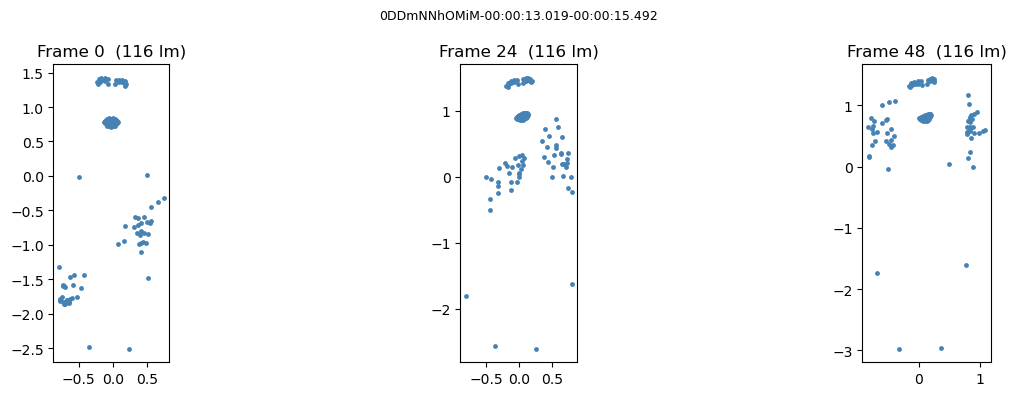

In [61]:
## Sanity Check -- Visualize One Preprocessed Clip

import matplotlib.pyplot as plt

sample = mf_train.sample(1).iloc[0]
npz    = np.load(sample["keypoint_path"])
kp     = npz["keypoints"]   # (T, 116, 3)
msk    = npz["mask"]         # (T, 116)

print(f"Clip  : {sample['vid']}")
print(f"Text  : {sample['text']}")
print(f"Shape : {kp.shape}  -- expected (T, 116, 3)")
print(f"Mask coverage: {msk.mean()*100:.1f}% valid landmarks")
valid_kp = kp[msk == 1]
print(f"X range (valid): [{valid_kp[:, 0].min():.2f}, {valid_kp[:, 0].max():.2f}]")
print(f"Y range (valid): [{valid_kp[:, 1].min():.2f}, {valid_kp[:, 1].max():.2f}]")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for col, t_frac in enumerate([0, 0.5, 1.0]):
    t     = min(int(t_frac * (kp.shape[0] - 1)), kp.shape[0] - 1)
    valid = msk[t] == 1
    axes[col].scatter(kp[t, valid, 0], -kp[t, valid, 1], s=6, c="steelblue")
    axes[col].set_title(f"Frame {t}  ({valid.sum()} lm)")
    axes[col].set_aspect("equal")

plt.suptitle(sample['vid'][:60], fontsize=9)
plt.tight_layout()
plt.show()

Clip  : sb51jo_2h8o-00:08:14.040-00:08:20.639
Text  : You can get more information about products affected on the USDA's website.
Shape : (132, 116, 3)
Mask coverage: 99.0% valid landmarks
X range (valid): [-1.02, 1.05]
Y range (valid): [-1.35, 2.40]


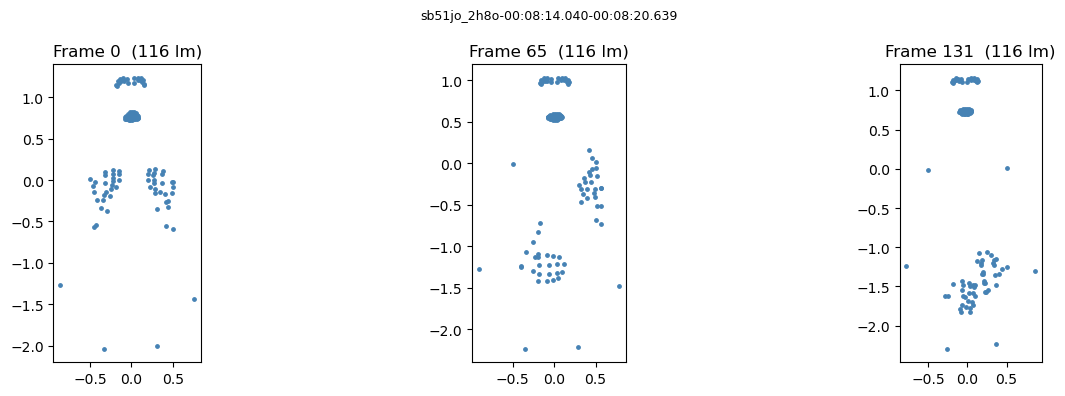

Saved: C:\Users\mamou\Downloads\sb51jo_2h8o-00-08-14.040-00-08-20.639_landmarks.mp4


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random

# Pick a random clip from manifest
sample = mf_train.sample(1).iloc[0]
npz    = np.load(sample["keypoint_path"])
kp     = npz["keypoints"]   # (T, 116, 3)
msk    = npz["mask"]         # (T, 116)

print(f"Clip  : {sample['vid']}")
print(f"Text  : {sample['text']}")
print(f"Shape : {kp.shape}")

# --- Static sanity check (your original code) ---
print(f"Mask coverage: {msk.mean()*100:.1f}% valid landmarks")
valid_kp = kp[msk == 1]
print(f"X range (valid): [{valid_kp[:, 0].min():.2f}, {valid_kp[:, 0].max():.2f}]")
print(f"Y range (valid): [{valid_kp[:, 1].min():.2f}, {valid_kp[:, 1].max():.2f}]")

fig_static, axes = plt.subplots(1, 3, figsize=(14, 4))
for col, t_frac in enumerate([0, 0.5, 1.0]):
    t     = min(int(t_frac * (kp.shape[0] - 1)), kp.shape[0] - 1)
    valid = msk[t] == 1
    axes[col].scatter(kp[t, valid, 0], -kp[t, valid, 1], s=6, c="steelblue")
    axes[col].set_title(f"Frame {t}  ({valid.sum()} lm)")
    axes[col].set_aspect("equal")
plt.suptitle(sample['vid'][:60], fontsize=9)
plt.tight_layout()
plt.show()

# --- Animated video ---
x_all = kp[msk == 1][:, 0]
y_all = kp[msk == 1][:, 1]
x_min, x_max = x_all.min() - 0.05, x_all.max() + 0.05
y_min, y_max = y_all.min() - 0.05, y_all.max() + 0.05

fig_anim, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(x_min, x_max)
ax.set_ylim(-y_max, -y_min)
ax.set_aspect("equal")
ax.set_facecolor("black")
fig_anim.patch.set_facecolor("black")
ax.tick_params(colors="white")
title = ax.set_title("", color="white", fontsize=8)
scat  = ax.scatter([], [], s=6, c="steelblue")

def update(t):
    valid = msk[t] == 1
    scat.set_offsets(np.c_[kp[t, valid, 0], -kp[t, valid, 1]])
    title.set_text(f"{sample['vid'][:50]}  |  frame {t}/{kp.shape[0]-1}\n{sample['text'][:80]}")
    return scat, title

ani = animation.FuncAnimation(fig_anim, update, frames=kp.shape[0], interval=50, blit=True)

out_path = r"C:\Users\mamou\Downloads" + f"\\{sample['vid'][:40].replace(':','-')}_landmarks.mp4"
writer   = animation.FFMpegWriter(fps=20, bitrate=1800)
ani.save(out_path, writer=writer)
print(f"Saved: {out_path}")
plt.close(fig_anim)

In [66]:
## Compare How2Sign vs OpenASL Keypoint Distributions (sanity check)

h2s_dir   = PROJECT_ROOT / "data" / "how2sign_keypoints_preprocessed" / "train"
h2s_files = sorted(h2s_dir.glob("*.npz"))

if h2s_files:
    h2s  = np.load(h2s_files[0])
    oasl = np.load(sample["keypoint_path"])

    print("How2Sign sample:")
    print(f"  shape  : {h2s['keypoints'].shape}")
    h2s_valid = h2s["keypoints"][h2s["mask"] == 1]
    print(f"  X range: [{h2s_valid[:,0].min():.2f}, {h2s_valid[:,0].max():.2f}]")
    print(f"  Y range: [{h2s_valid[:,1].min():.2f}, {h2s_valid[:,1].max():.2f}]")

    print("\nOpenASL sample:")
    print(f"  shape  : {oasl['keypoints'].shape}")
    print(f"  X range: [{valid_kp[:,0].min():.2f}, {valid_kp[:,0].max():.2f}]")
    print(f"  Y range: [{valid_kp[:,1].min():.2f}, {valid_kp[:,1].max():.2f}]")

    print("\nRanges should be roughly similar (both normalized by shoulder width).")
else:
    print("How2Sign preprocessed keypoints not found -- skipping comparison.")

How2Sign sample:
  shape  : (365, 116, 3)
  X range: [-1.13, 1.16]
  Y range: [-1.53, 3.29]

OpenASL sample:
  shape  : (132, 116, 3)
  X range: [-1.02, 1.05]
  Y range: [-1.35, 2.40]

Ranges should be roughly similar (both normalized by shoulder width).


In [86]:
## Compare How2Sign vs OpenASL Keypoint Distributions (sanity check)

h2s_dir   = PROJECT_ROOT / "data" / "how2sign_keypoints_preprocessed" / "train"
h2s_files = sorted(h2s_dir.glob("*.npz"))

if h2s_files:
    h2s_file    = random.choice(h2s_files)
    oasl_sample = mf_train.sample(1).iloc[0]

    h2s  = np.load(h2s_file)
    oasl = np.load(oasl_sample["keypoint_path"])

    h2s_valid  = h2s["keypoints"][h2s["mask"] == 1]
    oasl_valid = oasl["keypoints"][oasl["mask"] == 1]

    print("How2Sign sample:")
    print(f"  shape  : {h2s['keypoints'].shape}")
    print(f"  X range: [{h2s_valid[:,0].min():.2f}, {h2s_valid[:,0].max():.2f}]")
    print(f"  Y range: [{h2s_valid[:,1].min():.2f}, {h2s_valid[:,1].max():.2f}]")

    print("\nOpenASL sample:")
    print(f"  shape  : {oasl['keypoints'].shape}")
    print(f"  X range: [{oasl_valid[:,0].min():.2f}, {oasl_valid[:,0].max():.2f}]")
    print(f"  Y range: [{oasl_valid[:,1].min():.2f}, {oasl_valid[:,1].max():.2f}]")

    print("\nRanges should be roughly similar (both normalized by shoulder width).")
else:
    print("How2Sign preprocessed keypoints not found -- skipping comparison.")

How2Sign sample:
  shape  : (80, 116, 3)
  X range: [-1.03, 0.75]
  Y range: [-1.76, 2.70]

OpenASL sample:
  shape  : (60, 116, 3)
  X range: [-1.73, 0.94]
  Y range: [-1.34, 2.56]

Ranges should be roughly similar (both normalized by shoulder width).


OPENASL KEYPOINT QUALITY ANALYSIS (All Splits)
  train : 39,331 files
  val   : 461 files
  test  : 428 files

Analyzing 39331 samples from [train]...

Analyzing 461 samples from [val]...

Analyzing 428 samples from [test]...

--- [TRAIN]  (sampled 39331 / 39331 clips) ---
  Frames  : mean=88.9  median=87.0  min=26  max=160
  File MB : mean=0.13  total est=4.98 GB
  Detection rates (% frames with ≥1 landmark):
    Face      : 99.4%
    Pose      : 99.9%
    Left Hand : 90.2%
    Right Hand: 95.8%

--- [VAL]  (sampled 461 / 461 clips) ---
  Frames  : mean=86.4  median=85.0  min=27  max=160
  File MB : mean=0.13  total est=0.06 GB
  Detection rates (% frames with ≥1 landmark):
    Face      : 98.8%
    Pose      : 99.9%
    Left Hand : 90.4%
    Right Hand: 97.0%

--- [TEST]  (sampled 428 / 428 clips) ---
  Frames  : mean=93.8  median=93.0  min=27  max=160
  File MB : mean=0.14  total est=0.06 GB
  Detection rates (% frames with ≥1 landmark):
    Face      : 99.5%
    Pose      : 99.8%
 

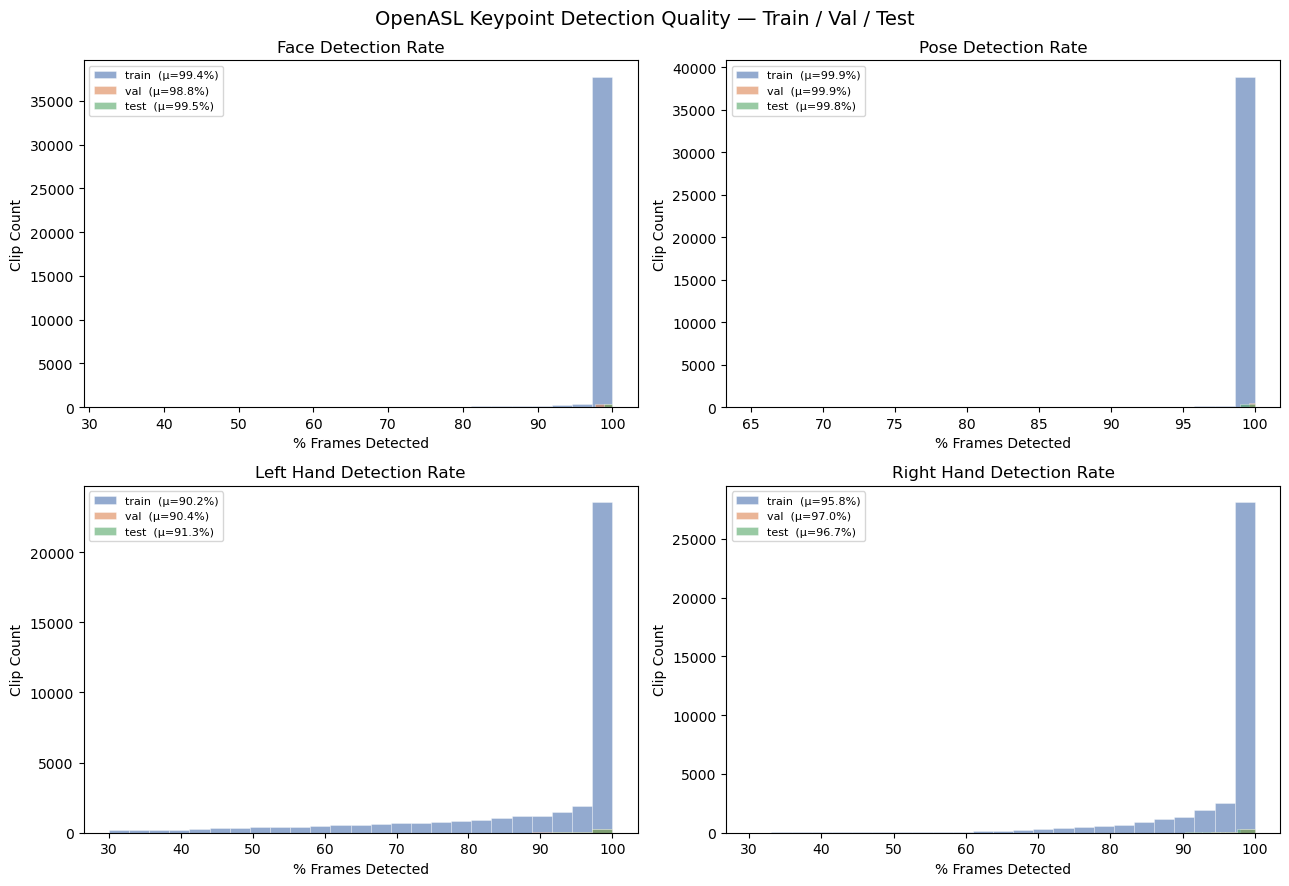


--- Potentially Problematic Clips (in sample) ---
  train : 45 / 39331 clips with issues
  val   : 2 / 461 clips with issues
  test  : 0 / 428 clips with issues

Quality analysis complete!


In [ ]:
## OpenASL Keypoint Quality Analysis (Train + Val + Test Combined)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config ----
KP_DIR     = Path('..') / 'data' / 'openasl_keypoints'
SPLITS     = ['train', 'val', 'test']
SAMPLE_SIZE = 1000000000  # per split

N_FACE, N_POSE, N_HAND = 60, 14, 21

# ---- Collect sample files across splits ----
print('=' * 60)
print('OPENASL KEYPOINT QUALITY ANALYSIS (All Splits)')
print('=' * 60)

all_files = {}
for split in SPLITS:
    files = list((KP_DIR / split).glob('*.npz'))
    all_files[split] = files
    print(f'  {split:6s}: {len(files):,} files')

# ---- Analyze samples ----
stats = {split: {
    'num_frames': [],
    'face_detected_pct': [],
    'pose_detected_pct': [],
    'left_hand_detected_pct': [],
    'right_hand_detected_pct': [],
    'file_size_mb': [],
} for split in SPLITS}

for split in SPLITS:
    sample = all_files[split][:SAMPLE_SIZE]
    print(f'\nAnalyzing {len(sample)} samples from [{split}]...')
    for kp_file in sample:
        data      = np.load(kp_file)
        keypoints = data['keypoints']   # (T, 116, 3)
        mask      = data['mask']        # (T, 116)

        T = keypoints.shape[0]
        face_mask  = mask[:, :N_FACE]
        pose_mask  = mask[:, N_FACE:N_FACE + N_POSE]
        lhand_mask = mask[:, N_FACE + N_POSE:N_FACE + N_POSE + N_HAND]
        rhand_mask = mask[:, N_FACE + N_POSE + N_HAND:N_FACE + N_POSE + N_HAND * 2]

        s = stats[split]
        s['num_frames'].append(T)
        s['file_size_mb'].append(kp_file.stat().st_size / (1024 ** 2))
        s['face_detected_pct'].append(100 * (face_mask.sum(axis=1) > 0).mean())
        s['pose_detected_pct'].append(100 * (pose_mask.sum(axis=1) > 0).mean())
        s['left_hand_detected_pct'].append(100 * (lhand_mask.sum(axis=1) > 0).mean())
        s['right_hand_detected_pct'].append(100 * (rhand_mask.sum(axis=1) > 0).mean())

# ---- Print summary ----
for split in SPLITS:
    s = stats[split]
    n = len(s['num_frames'])
    total_clips = len(all_files[split])
    est_gb = np.mean(s['file_size_mb']) * total_clips / 1024
    print(f'\n--- [{split.upper()}]  (sampled {n} / {total_clips} clips) ---')
    print(f'  Frames  : mean={np.mean(s["num_frames"]):.1f}  median={np.median(s["num_frames"]):.1f}  '
          f'min={np.min(s["num_frames"])}  max={np.max(s["num_frames"])}')
    print(f'  File MB : mean={np.mean(s["file_size_mb"]):.2f}  '
          f'total est={est_gb:.2f} GB')
    print(f'  Detection rates (% frames with ≥1 landmark):')
    print(f'    Face      : {np.mean(s["face_detected_pct"]):.1f}%')
    print(f'    Pose      : {np.mean(s["pose_detected_pct"]):.1f}%')
    print(f'    Left Hand : {np.mean(s["left_hand_detected_pct"]):.1f}%')
    print(f'    Right Hand: {np.mean(s["right_hand_detected_pct"]):.1f}%')

# ---- Combined plot (2x2, all splits overlaid per landmark type) ----
SPLIT_COLORS  = {'train': '#4C72B0', 'val': '#DD8452', 'test': '#55A868'}
SPLIT_ALPHAS  = {'train': 0.6,       'val': 0.6,       'test': 0.6}
landmark_keys = [
    ('face_detected_pct',       'Face Detection Rate'),
    ('pose_detected_pct',       'Pose Detection Rate'),
    ('left_hand_detected_pct',  'Left Hand Detection Rate'),
    ('right_hand_detected_pct', 'Right Hand Detection Rate'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('OpenASL Keypoint Detection Quality — Train / Val / Test', fontsize=14)

for ax, (key, title) in zip(axes.flat, landmark_keys):
    for split in SPLITS:
        vals = stats[split][key]
        ax.hist(
            vals,
            bins=25,
            alpha=SPLIT_ALPHAS[split],
            color=SPLIT_COLORS[split],
            edgecolor='white',
            linewidth=0.4,
            label=f'{split}  (μ={np.mean(vals):.1f}%)',
        )
    ax.set_title(title)
    ax.set_xlabel('% Frames Detected')
    ax.set_ylabel('Clip Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('openasl_keypoint_detection_quality_all_splits.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Problematic clip summary per split ----
print('\n--- Potentially Problematic Clips (in sample) ---')
for split in SPLITS:
    s = stats[split]
    n_prob = sum(
        1 for i in range(len(s['num_frames']))
        if s['face_detected_pct'][i] < 50
        or s['pose_detected_pct'][i] < 50
        or (s['left_hand_detected_pct'][i] < 30 and s['right_hand_detected_pct'][i] < 30)
    )
    print(f'  {split:6s}: {n_prob} / {len(s["num_frames"])} clips with issues')

print('\n' + '=' * 60)
print('Quality analysis complete!')
print('=' * 60)

SANITY CHECK: OpenASL Preprocessed Keypoints (All Splits)

Analyzed 30 files (10 per split)
Total valid keypoints: 324,957

Coordinate statistics (after normalization):
  X: mean=-0.039321, std=0.3257, min=-1.4660, max=1.8827
  Y: mean=-0.252183, std=0.8225, min=-2.1219, max=3.4440
  Z: mean=-0.115185, std=0.3644, min=-3.7936, max=0.1630

✅ Expected: X and Y centered near 0 (body center removed)
✅ Expected: X and Y scaled by shoulder width (typically -2 to +2 range)
✅ Expected: Z values remain in original MediaPipe scale


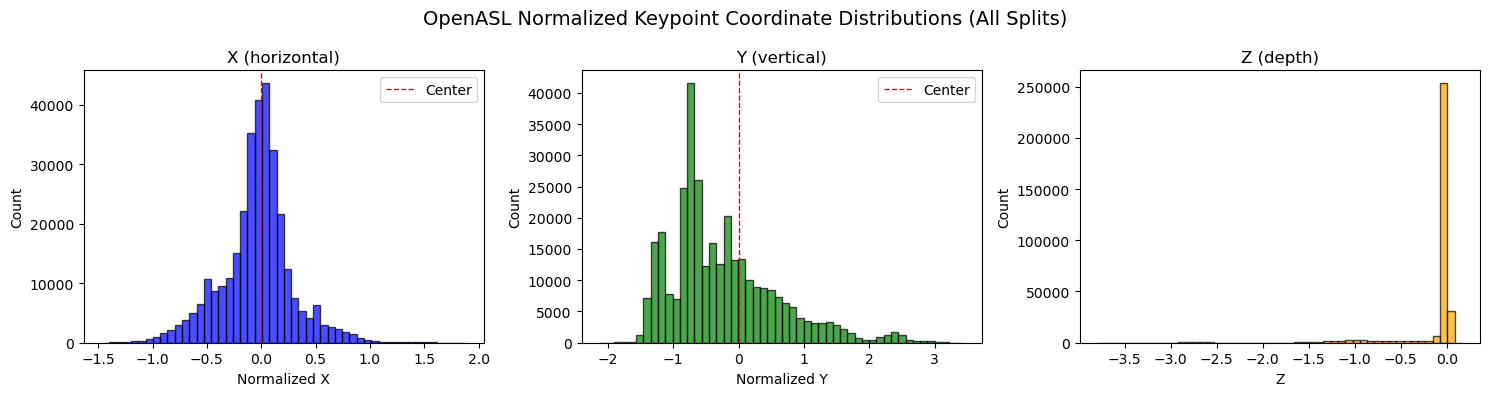

In [4]:
## OpenASL Sanity Check: Preprocessed Keypoints (All Splits Combined)

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

KP_PRE_DIR = Path('..') / 'data' / 'openasl_keypoints_preprocessed'
SPLITS     = ['train', 'val', 'test']
SAMPLE_SIZE = 10  # per split

print('=' * 60)
print('SANITY CHECK: OpenASL Preprocessed Keypoints (All Splits)')
print('=' * 60)

all_coords = []
total_files = 0

for split in SPLITS:
    files = list((KP_PRE_DIR / split).glob('*.npz'))[:SAMPLE_SIZE]
    total_files += len(files)
    for pf in files:
        data = np.load(pf)
        keypoints = data['keypoints']
        mask      = data['mask']
        all_coords.append(keypoints[mask == 1])

all_coords = np.concatenate(all_coords, axis=0)

print(f'\nAnalyzed {total_files} files ({SAMPLE_SIZE} per split)')
print(f'Total valid keypoints: {len(all_coords):,}')
print()
print('Coordinate statistics (after normalization):')
for i, axis in enumerate(['X', 'Y', 'Z']):
    v = all_coords[:, i]
    print(f'  {axis}: mean={v.mean():.6f}, std={v.std():.4f}, min={v.min():.4f}, max={v.max():.4f}')
print()
print('✅ Expected: X and Y centered near 0 (body center removed)')
print('✅ Expected: X and Y scaled by shoulder width (typically -2 to +2 range)')
print('✅ Expected: Z values remain in original MediaPipe scale')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('OpenASL Normalized Keypoint Coordinate Distributions (All Splits)', fontsize=14)

for i, (axis, color, label) in enumerate([
    ('X (horizontal)', 'blue',   'Normalized X'),
    ('Y (vertical)',   'green',  'Normalized Y'),
    ('Z (depth)',      'orange', 'Z'),
]):
    axes[i].hist(all_coords[:, i], bins=50, edgecolor='black', alpha=0.7, color=color)
    axes[i].set_title(axis)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')
    if i < 2:
        axes[i].axvline(0, color='red', linestyle='--', linewidth=1, label='Center')
        axes[i].legend()

plt.tight_layout()
plt.savefig('openasl_normalized_keypoint_coordinate_distributions_all_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print('=' * 60)

In [5]:
import pandas as pd
from pathlib import Path

# Define paths
DATA_DIR = Path("C:/My Projects/sign-language-bridge/data")

# How2Sign files (CSV)
H2S_TRAIN = DATA_DIR / "(final)_how2sign_train_filtered.csv"
H2S_VAL = DATA_DIR / "(final)_how2sign_val_filtered.csv"
H2S_TEST = DATA_DIR / "(final)_how2sign_test_filtered.csv"

# OpenASL files (TSV)
OPENASL_TRAIN = DATA_DIR / "openasl_final_train.tsv"
OPENASL_VAL = DATA_DIR / "openasl_final_val.tsv"
OPENASL_TEST = DATA_DIR / "openasl_final_test.tsv"

# Output files (TSV)
OUTPUT_TRAIN = DATA_DIR / "final_full_train_dataset.tsv"
OUTPUT_VAL = DATA_DIR / "final_full_val_dataset.tsv"
OUTPUT_TEST = DATA_DIR / "final_full_test_dataset.tsv"


def print_dataset_info(df, name):
    """Print comprehensive statistics about a dataset."""
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Number of examples: {len(df):,}")
    print(f"Columns: {list(df.columns)}")

    if 'duration_sec' in df.columns:
        print(f"\nDuration statistics:")
        print(f"  Total duration: {df['duration_sec'].sum():.2f} seconds ({df['duration_sec'].sum()/3600:.2f} hours)")
        print(f"  Mean duration: {df['duration_sec'].mean():.2f} seconds")
        print(f"  Median duration: {df['duration_sec'].median():.2f} seconds")
        print(f"  Min duration: {df['duration_sec'].min():.2f} seconds")
        print(f"  Max duration: {df['duration_sec'].max():.2f} seconds")

    if 'word_count' in df.columns and df['word_count'].notna().any():
        print(f"\nWord count statistics:")
        print(f"  Total words: {df['word_count'].sum():,}")
        print(f"  Mean words per example: {df['word_count'].mean():.2f}")
        print(f"  Median words: {df['word_count'].median():.0f}")
        print(f"  Min words: {df['word_count'].min():.0f}")
        print(f"  Max words: {df['word_count'].max():.0f}")

    if 'text' in df.columns:
        print(f"\nText statistics:")
        print(f"  Mean text length: {df['text'].str.len().mean():.2f} characters")
        print(f"  Median text length: {df['text'].str.len().median():.0f} characters")


def process_how2sign(csv_path, split_name):
    """Process How2Sign CSV file and map to unified schema."""
    print(f"\nReading How2Sign {split_name}...")
    df = pd.read_csv(csv_path, sep='\t')  # How2Sign uses tab separator

    print(f"Original columns: {list(df.columns)}")

    # Map columns to unified schema
    unified_df = pd.DataFrame({
        'vid': df['SENTENCE_NAME'],  # Use SENTENCE_NAME as unique identifier
        'text': df['SENTENCE'],
        'start': df['START_REALIGNED'],
        'end': df['END_REALIGNED'],
        'duration_sec': df['duration_sec'] if 'duration_sec' in df.columns else df['row_duration_sec'],
    })

    # Calculate word_count if not present
    if 'word_count' in df.columns:
        unified_df['word_count'] = df['word_count']
    else:
        unified_df['word_count'] = unified_df['text'].str.split().str.len()
        print(f"  Calculated word_count from text (was missing)")

    print_dataset_info(df, f"How2Sign {split_name} (ORIGINAL)")

    return unified_df


def process_openasl(tsv_path, split_name):
    """Process OpenASL TSV file and map to unified schema."""
    print(f"\nReading OpenASL {split_name}...")
    df = pd.read_csv(tsv_path, sep='\t')

    print(f"Original columns: {list(df.columns)}")

    # Map columns to unified schema (OpenASL already has matching column names)
    unified_df = pd.DataFrame({
        'vid': df['vid'],
        'text': df['text'],
        'start': df['start'],
        'end': df['end'],
        'duration_sec': df['duration_sec'],
        'word_count': df['word_count'],
    })

    print_dataset_info(df, f"OpenASL {split_name} (ORIGINAL)")

    return unified_df


def combine_and_save(h2s_df, openasl_df, output_path, split_name):
    """Combine How2Sign and OpenASL dataframes and save to TSV."""
    print(f"\n{'='*60}")
    print(f"COMBINING {split_name.upper()} SPLIT")
    print(f"{'='*60}")

    # Add source column for tracking (optional, can be useful)
    h2s_df_copy = h2s_df.copy()
    openasl_df_copy = openasl_df.copy()

    print(f"\nHow2Sign {split_name}: {len(h2s_df):,} examples")
    print(f"OpenASL {split_name}: {len(openasl_df):,} examples")

    # Combine
    combined_df = pd.concat([h2s_df_copy, openasl_df_copy], ignore_index=True)

    print(f"Combined total: {len(combined_df):,} examples")

    # Print combined statistics
    print_dataset_info(combined_df, f"COMBINED {split_name.upper()} (AFTER MERGING)")

    # Save to TSV
    combined_df.to_csv(output_path, sep='\t', index=False)
    print(f"\n✓ Saved to: {output_path}")

    return combined_df


def main():
    """Main function to process and combine all datasets."""
    print("="*60)
    print("DATASET COMBINATION SCRIPT")
    print("="*60)
    print("\nThis script combines How2Sign and OpenASL datasets")
    print("into unified train/val/test splits with a common schema.")

    # ========== PROCESS TRAIN SPLIT ==========
    print("\n\n" + "█"*60)
    print("TRAIN SPLIT")
    print("█"*60)

    h2s_train = process_how2sign(H2S_TRAIN, "train")
    openasl_train = process_openasl(OPENASL_TRAIN, "train")
    combined_train = combine_and_save(h2s_train, openasl_train, OUTPUT_TRAIN, "train")

    # ========== PROCESS VALIDATION SPLIT ==========
    print("\n\n" + "█"*60)
    print("VALIDATION SPLIT")
    print("█"*60)

    h2s_val = process_how2sign(H2S_VAL, "validation")
    openasl_val = process_openasl(OPENASL_VAL, "validation")
    combined_val = combine_and_save(h2s_val, openasl_val, OUTPUT_VAL, "validation")

    # ========== PROCESS TEST SPLIT ==========
    print("\n\n" + "█"*60)
    print("TEST SPLIT")
    print("█"*60)

    h2s_test = process_how2sign(H2S_TEST, "test")
    openasl_test = process_openasl(OPENASL_TEST, "test")
    combined_test = combine_and_save(h2s_test, openasl_test, OUTPUT_TEST, "test")

    # ========== FINAL SUMMARY ==========
    print("\n\n" + "█"*60)
    print("FINAL SUMMARY")
    print("█"*60)

    total_examples = len(combined_train) + len(combined_val) + len(combined_test)
    total_duration = (combined_train['duration_sec'].sum() +
                     combined_val['duration_sec'].sum() +
                     combined_test['duration_sec'].sum())

    print(f"\n{'Split':<15} {'How2Sign':<12} {'OpenASL':<12} {'Combined':<12}")
    print("-" * 60)
    print(f"{'Train':<15} {len(h2s_train):<12,} {len(openasl_train):<12,} {len(combined_train):<12,}")
    print(f"{'Validation':<15} {len(h2s_val):<12,} {len(openasl_val):<12,} {len(combined_val):<12,}")
    print(f"{'Test':<15} {len(h2s_test):<12,} {len(openasl_test):<12,} {len(combined_test):<12,}")
    print("-" * 60)
    print(f"{'TOTAL':<15} {len(h2s_train)+len(h2s_val)+len(h2s_test):<12,} "
          f"{len(openasl_train)+len(openasl_val)+len(openasl_test):<12,} {total_examples:<12,}")

    print(f"\nTotal dataset duration: {total_duration:.2f} seconds ({total_duration/3600:.2f} hours)")

    print("\n" + "="*60)
    print("✓ DATASET COMBINATION COMPLETE!")
    print("="*60)
    print("\nOutput files:")
    print(f"  - {OUTPUT_TRAIN}")
    print(f"  - {OUTPUT_VAL}")
    print(f"  - {OUTPUT_TEST}")
    print("\nFinal schema: vid, text, start, end, duration_sec, word_count")


if __name__ == "__main__":
    main()

DATASET COMBINATION SCRIPT

This script combines How2Sign and OpenASL datasets
into unified train/val/test splits with a common schema.


████████████████████████████████████████████████████████████
TRAIN SPLIT
████████████████████████████████████████████████████████████

Reading How2Sign train...
Original columns: ['VIDEO_ID', 'VIDEO_NAME', 'SENTENCE_ID', 'SENTENCE_NAME', 'START_REALIGNED', 'END_REALIGNED', 'SENTENCE', 'row_duration_sec', 'duration_sec', 'word_count']

How2Sign train (ORIGINAL)
Number of examples: 19,935
Columns: ['VIDEO_ID', 'VIDEO_NAME', 'SENTENCE_ID', 'SENTENCE_NAME', 'START_REALIGNED', 'END_REALIGNED', 'SENTENCE', 'row_duration_sec', 'duration_sec', 'word_count']

Duration statistics:
  Total duration: 86407.39 seconds (24.00 hours)
  Mean duration: 4.33 seconds
  Median duration: 4.18 seconds
  Min duration: 1.30 seconds
  Max duration: 8.00 seconds

Word count statistics:
  Total words: 261,165
  Mean words per example: 13.10
  Median words: 12
  Min words: 1
  

In [9]:
import pandas as pd
from pathlib import Path

# Define paths
DATA_DIR = Path("C:/My Projects/sign-language-bridge/data")
files = [
    DATA_DIR / "final_full_train_dataset.tsv",
    DATA_DIR / "final_full_val_dataset.tsv",
    DATA_DIR / "final_full_test_dataset.tsv"
]

for file_path in files:
    print(f"Processing {file_path.name}...")

    # Read TSV
    df = pd.read_csv(file_path, sep='\t')

    # Count occurrences before fixing
    before_count = df['text'].str.contains("â", na=False).sum()

    # Fix the encoding issue in text column
    df['text'] = df['text'].str.replace("â", "'", regex=False)

    # Count after fixing
    after_count = df['text'].str.contains("â", na=False).sum()

    # Save back to TSV
    df.to_csv(file_path, sep='\t', index=False)

    print(f"  Fixed {before_count}") # rows (remaining: {after_count})")
    print(f"  ✓ Saved\n")

print("All files fixed!")

Processing final_full_train_dataset.tsv...
  Fixed 45
  ✓ Saved

Processing final_full_val_dataset.tsv...
  Fixed 1
  ✓ Saved

Processing final_full_test_dataset.tsv...
  Fixed 9
  ✓ Saved

All files fixed!


In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("C:/My Projects/sign-language-bridge/data")

H2S_DIRS = {
    "train": Path(r"C:\My Projects\sign-language-bridge\data\how2sign_raw_clips\train_rgb_front_clips"),
    "val":   Path(r"C:\My Projects\sign-language-bridge\data\how2sign_raw_clips\val_rgb_front_clips"),
    "test":  Path(r"C:\My Projects\sign-language-bridge\data\how2sign_raw_clips\test_rgb_front_clips"),
}
OPENASL_VIDEO_DIR = Path(r"D:\OpenASL\raw_videos")


def resolve_file_path(vid: str, split: str):
    if ":" in vid:
        # OpenASL — YouTube ID is always the first 11 characters
        yid = vid[:11]
        return OPENASL_VIDEO_DIR / f"{yid}.mp4"
    else:
        # How2Sign — vid == SENTENCE_NAME == clip filename
        return H2S_DIRS[split] / f"{vid}.mp4"


print("=" * 65)
print("Adding 'file_path' column to final_full_{split}_dataset.tsv files")
print("=" * 65)

grand_total = grand_found = grand_missing = 0

for split in ["train", "val", "test"]:
    tsv_path = DATA_DIR / f"final_full_{split}_dataset.tsv"
    df = pd.read_csv(tsv_path, sep="\t")

    is_openasl = df["vid"].str.contains(":", na=False)
    h2s_count  = (~is_openasl).sum()
    asl_count  = is_openasl.sum()

    file_paths = []
    missing_vids = []

    for _, row in df.iterrows():
        p = resolve_file_path(str(row["vid"]), split)
        if p.exists():
            file_paths.append(str(p))
        else:
            file_paths.append(None)
            missing_vids.append(row["vid"])

    df["file_path"] = file_paths
    df.to_csv(tsv_path, sep="\t", index=False)

    found   = len(df) - len(missing_vids)
    missing = len(missing_vids)

    grand_total   += len(df)
    grand_found   += found
    grand_missing += missing

    print(f"\n[{split.upper()}]  {tsv_path.name}")
    print(f"  Total examples  : {len(df):,}")
    print(f"  How2Sign rows   : {h2s_count:,}")
    print(f"  OpenASL rows    : {asl_count:,}")
    print(f"  Files found     : {found:,}  ({100*found/len(df):.1f}%)")
    print(f"  Files missing   : {missing:,}  ({100*missing/len(df):.1f}%)")
    if missing_vids:
        print(f"  Sample missing  :")
        for v in missing_vids[:5]:
            print(f"    {v}")
        if missing > 5:
            print(f"    ... and {missing - 5} more")

print("\n" + "=" * 65)
print("GRAND TOTAL")
print(f"  Examples  : {grand_total:,}")
print(f"  Found     : {grand_found:,}  ({100*grand_found/grand_total:.1f}%)")
print(f"  Missing   : {grand_missing:,}  ({100*grand_missing/grand_total:.1f}%)")
print("=" * 65)

Adding 'file_path' column to final_full_{split}_dataset.tsv files

[TRAIN]  final_full_train_dataset.tsv
  Total examples  : 59,242
  How2Sign rows   : 19,935
  OpenASL rows    : 39,307
  Files found     : 59,242  (100.0%)
  Files missing   : 0  (0.0%)

[VAL]  final_full_val_dataset.tsv
  Total examples  : 1,512
  How2Sign rows   : 1,051
  OpenASL rows    : 461
  Files found     : 1,512  (100.0%)
  Files missing   : 0  (0.0%)

[TEST]  final_full_test_dataset.tsv
  Total examples  : 1,892
  How2Sign rows   : 1,464
  OpenASL rows    : 428
  Files found     : 1,883  (99.5%)
  Files missing   : 9  (0.5%)
  Sample missing  :
    G3GcPpidwxk_22-5-rgb_front
    fZq8wTAYtmw_10-5-rgb_front
    g0yUlOaqL6k_17-3-rgb_front
    g0yUlOaqL6k_18-3-rgb_front
    g0yUlOaqL6k_19-3-rgb_front
    ... and 4 more

GRAND TOTAL
  Examples  : 62,646
  Found     : 62,637  (100.0%)
  Missing   : 9  (0.0%)


In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("C:/My Projects/sign-language-bridge/data")

# Build the OpenASL vid set by cross-referencing the final OpenASL manifests
# (these are the ground truth for what made it through the full pipeline)
openasl_vids = set()
for split in ['train', 'val', 'test']:
    path = DATA_DIR / f"openasl_final_{split}.tsv"
    if not path.exists():
        print(f"WARNING: {path.name} not found -- OpenASL {split} vids may be misclassified")
        continue
    df = pd.read_csv(path, sep='\t')
    openasl_vids.update(df['vid'].astype(str))

print(f"Loaded {len(openasl_vids):,} OpenASL vids for source tagging")

for split in ['train', 'val', 'test']:
    path = DATA_DIR / f"final_full_{split}_dataset.tsv"
    if not path.exists():
        print(f"Skipping missing file: {path.name}")
        continue

    df = pd.read_csv(path, sep='\t')
    before_cols = list(df.columns)

    df['source'] = df['vid'].astype(str).apply(
        lambda v: 'openasl' if v in openasl_vids else 'how2sign'
    )

    df.to_csv(path, sep='\t', index=False)

    n_h2s  = (df['source'] == 'how2sign').sum()
    n_oasl = (df['source'] == 'openasl').sum()
    n_unknown = df['source'].isna().sum()

    print(f"\n{split}:")
    print(f"  how2sign : {n_h2s:,}")
    print(f"  openasl  : {n_oasl:,}")
    print(f"  total    : {len(df):,}")
    if n_unknown > 0:
        print(f"  WARNING: {n_unknown} rows could not be classified -- check manually")
    if n_h2s + n_oasl != len(df):
        print(f"  WARNING: counts don't add up -- inspect for duplicates or NaN vids")

print("\nDone. 'source' column added to all final_full_*_dataset.tsv files.")

Loaded 40,220 OpenASL vids for source tagging

train:
  how2sign : 19,935
  openasl  : 39,307
  total    : 59,242

val:
  how2sign : 1,051
  openasl  : 461
  total    : 1,512

test:
  how2sign : 1,464
  openasl  : 428
  total    : 1,892

Done. 'source' column added to all final_full_*_dataset.tsv files.
